In [2]:
# ============================================================
# 0. SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

In [4]:
# ============================================================
# 1. LOAD PARQUET AND CREATE WIDE TABLE
# ============================================================

# Replace filename
df = pd.read_excel("BEV Registrations.xlsx")

df.head()

df_2 = pd.read_excel("BEV Registrations Norway.xlsx")
df_2.head()


,Año,Mes,BEV registrations
0,2014,1,1078
1,2014,2,1333
2,2014,3,2696
3,2014,4,1218
4,2014,5,1290


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Año                144 non-null    int64
 1   Mes                144 non-null    int64
 2   BEV registrations  144 non-null    int64
dtypes: int64(3)
memory usage: 3.5 KB


In [6]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Año                144 non-null    int64
 1   Mes                144 non-null    int64
 2   BEV registrations  144 non-null    int64
dtypes: int64(3)
memory usage: 3.5 KB


In [7]:
# ============================================================
# 4. SUMMARY STATISTICS PER SERIES
# ============================================================

summary_stats = df.describe().T[
    ["mean", "std", "min", "max"]
]

summary_stats


,mean,std,min,max
Año,2019.500000,3.464102,2014.0,2025.0
Mes,6.500000,3.464102,1.0,12.0
BEV registrations,2766.444444,3106.812458,33.0,15304.0


In [8]:
df["date"] = pd.to_datetime(
    df["Año"].astype(str) + "-" + df["Mes"].astype(str).str.zfill(2)
)

# Sort just to be safe
df = df.sort_values("date").reset_index(drop=True)

df.head()

df_2["date"] = pd.to_datetime(
    df_2["Año"].astype(str) + "-" + df_2["Mes"].astype(str).str.zfill(2)
)

# Sort just to be safe
df_2 = df_2.sort_values("date").reset_index(drop=True)

df_2.head()


,Año,Mes,BEV registrations,date
0,2014,1,1078,2014-01-01
1,2014,2,1333,2014-02-01
2,2014,3,2696,2014-03-01
3,2014,4,1218,2014-04-01
4,2014,5,1290,2014-05-01


In [9]:
df.columns = [c.strip() for c in df.columns]

# Try to find year/month/value columns robustly
col_year = next((c for c in df.columns if c.lower() in ["año", "ano", "year"]), None)
col_month = next((c for c in df.columns if c.lower() in ["mes", "month"]), None)
col_val = next((c for c in df.columns if "bev" in c.lower()), None)

if not (col_year and col_month and col_val):
    raise ValueError(f"Could not auto-detect columns. Found: {df.columns.tolist()}")

df = df.rename(columns={col_year: "year", col_month: "month", col_val: "bev"})
df.head()

### Norway

df_2.columns = [c.strip() for c in df_2.columns]

# Try to find year/month/value columns robustly
col_year = next((c for c in df_2.columns if c.lower() in ["año", "ano", "year"]), None)
col_month = next((c for c in df_2.columns if c.lower() in ["mes", "month"]), None)
col_val = next((c for c in df_2.columns if "bev" in c.lower()), None)

if not (col_year and col_month and col_val):
    raise ValueError(f"Could not auto-detect columns. Found: {df_2.columns.tolist()}")

df_2 = df_2.rename(columns={col_year: "year", col_month: "month", col_val: "bev"})
df_2.head()

,year,month,bev,date
0,2014,1,1078,2014-01-01
1,2014,2,1333,2014-02-01
2,2014,3,2696,2014-03-01
3,2014,4,1218,2014-04-01
4,2014,5,1290,2014-05-01


In [10]:
df["date"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" + df["month"].astype(int).astype(str).str.zfill(2))
df = df.sort_values("date").reset_index(drop=True)

# Keep a clean time-series frame
ts = df.set_index("date")["bev"].asfreq("MS")  # monthly start frequency
ts.head(), ts.tail()

### Norway

df_2["date"] = pd.to_datetime(df_2["year"].astype(int).astype(str) + "-" + df_2["month"].astype(int).astype(str).str.zfill(2))
df_2 = df_2.sort_values("date").reset_index(drop=True)

ts_2 = df_2.set_index("date")["bev"].asfreq("MS")  # monthly start frequency
ts_2.head(), ts_2.tail()



(date
 2014-01-01    1078
 2014-02-01    1333
 2014-03-01    2696
 2014-04-01    1218
 2014-05-01    1290
 Freq: MS, Name: bev, dtype: int64,
 date
 2025-08-01    13482
 2025-09-01    14084
 2025-10-01    10852
 2025-11-01    19427
 2025-12-01    34346
 Freq: MS, Name: bev, dtype: int64)

### Time Series Plots

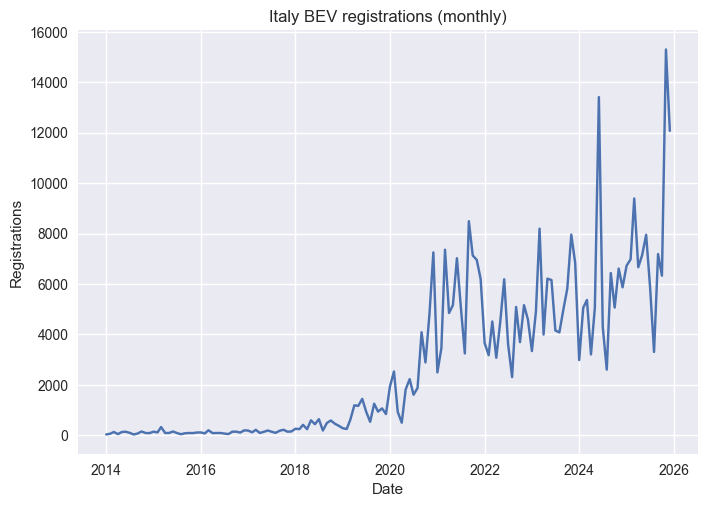

In [11]:
plt.figure()
plt.plot(ts.index, ts.values)
plt.title("Italy BEV registrations (monthly)")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.show()


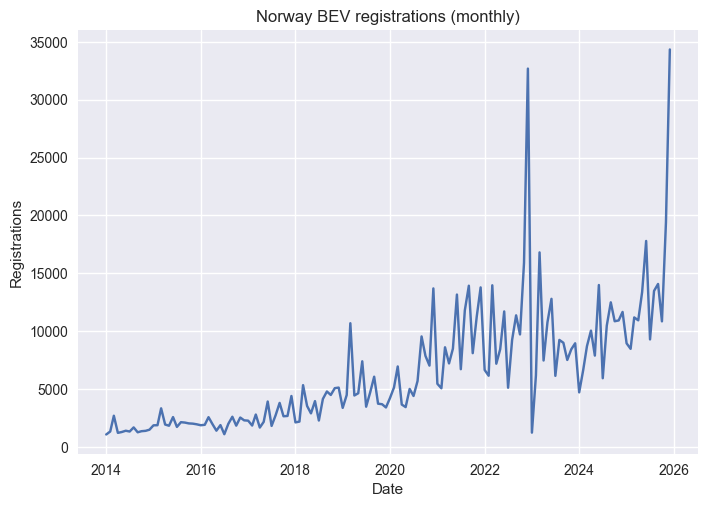

In [12]:
plt.figure()
plt.plot(ts_2.index, ts_2.values)
plt.title("Norway BEV registrations (monthly)")
plt.xlabel("Date")
plt.ylabel("Registrations")
plt.show()


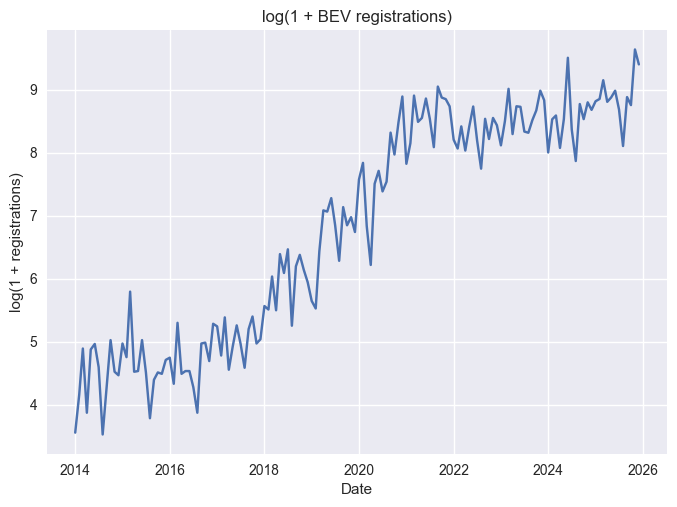

In [13]:
ts_log = np.log1p(ts)  # log(1 + x) handles zeros safely

plt.figure()
plt.plot(ts_log.index, ts_log.values)
plt.title("log(1 + BEV registrations)")
plt.xlabel("Date")
plt.ylabel("log(1 + registrations)")
plt.show()


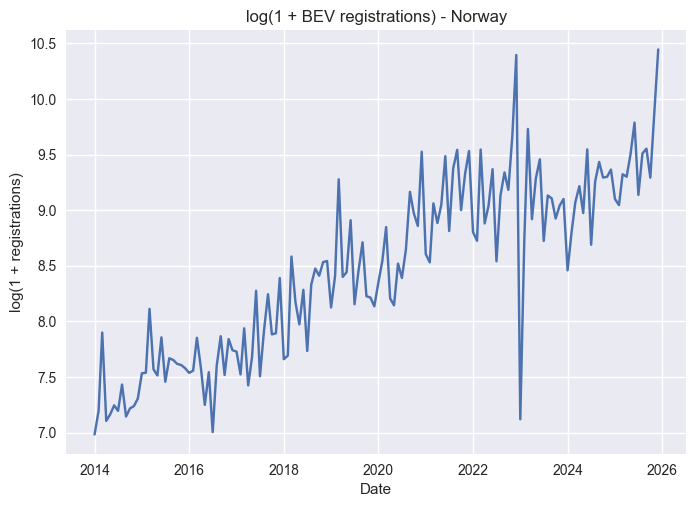

In [14]:
#Norway

ts_log_2 = np.log1p(ts_2)  # log(1 + x) handles zeros safely

plt.figure()
plt.plot(ts_log_2.index, ts_log_2.values)
plt.title("log(1 + BEV registrations) - Norway")
plt.xlabel("Date")
plt.ylabel("log(1 + registrations)")
plt.show()

<Figure size 800x550 with 0 Axes>

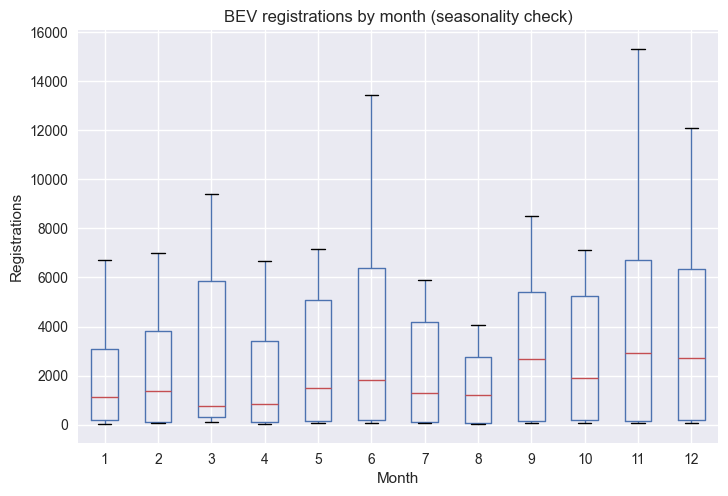

In [15]:
tmp = ts.to_frame("bev").copy()
tmp["month"] = tmp.index.month

plt.figure()
tmp.boxplot(column="bev", by="month")
plt.title("BEV registrations by month (seasonality check)")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Registrations")
plt.show()


<Figure size 800x550 with 0 Axes>

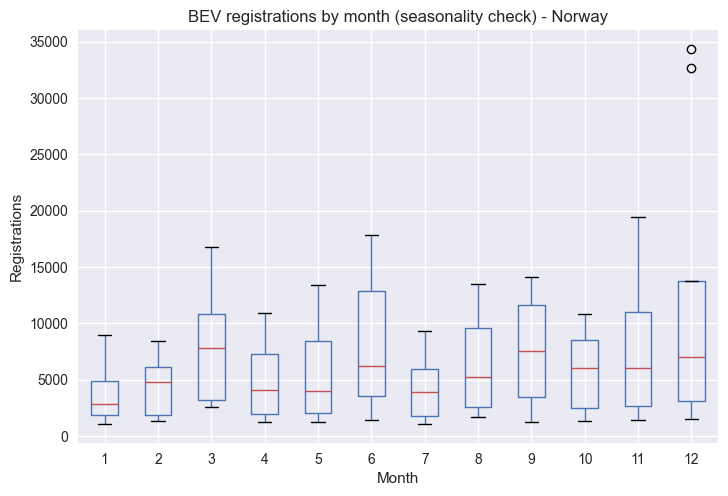

In [16]:
tmp_2 = ts_2.to_frame("bev").copy()
tmp_2["month"] = tmp_2.index.month

plt.figure()
tmp_2.boxplot(column="bev", by="month")
plt.title("BEV registrations by month (seasonality check) - Norway")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Registrations")
plt.show()


### Seasonal decomposition (trend/seasonal/resid)

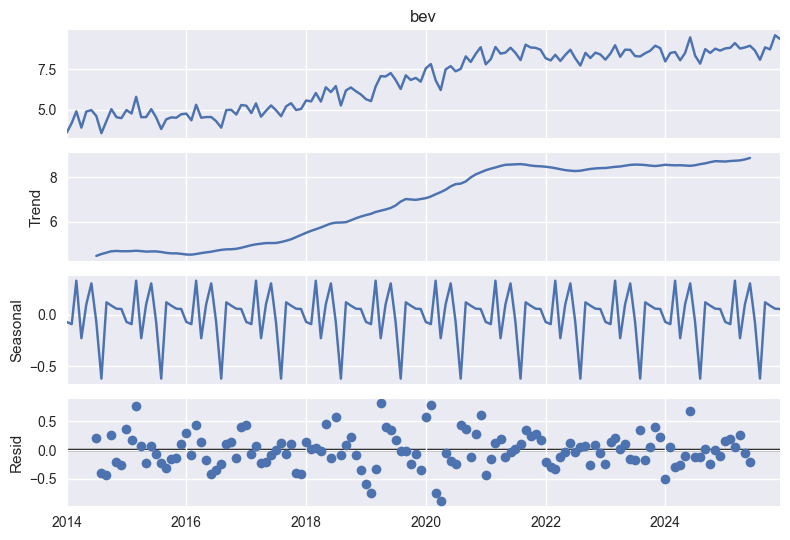

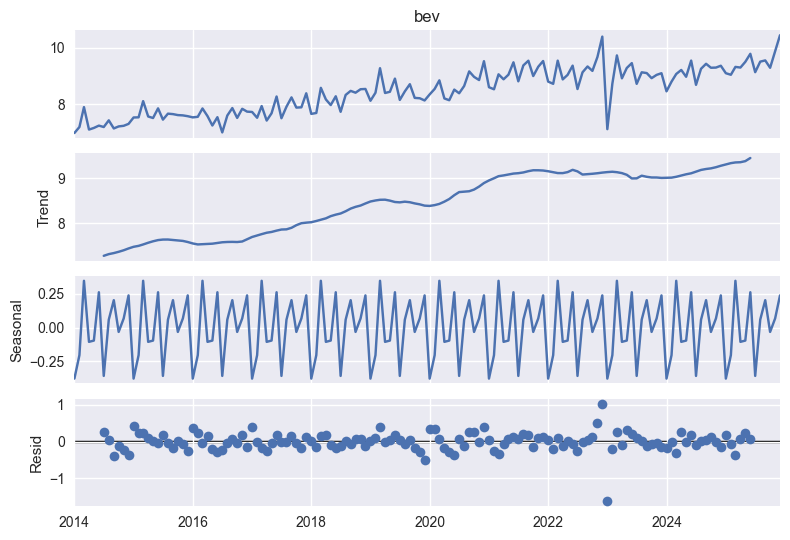

In [17]:
decomp = seasonal_decompose(ts_log, model="additive", period=12)

decomp.plot()
plt.show()

decomp_2 = seasonal_decompose(ts_log_2, model="additive", period=12)
decomp_2.plot()
plt.show()

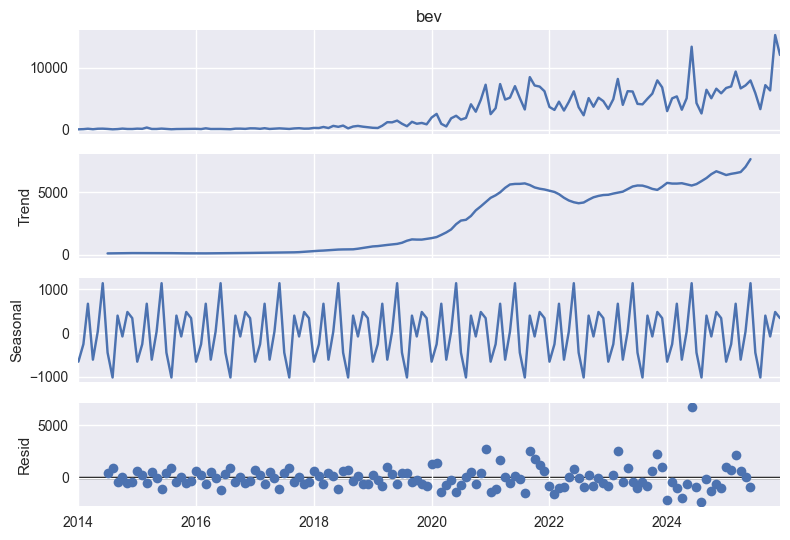

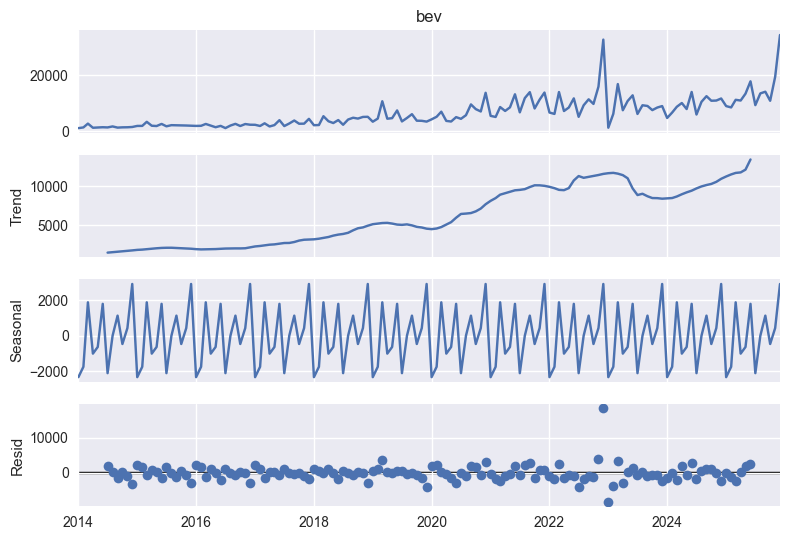

In [18]:
decomp_lvl = seasonal_decompose(ts, model="additive", period=12)
decomp_lvl.plot()
plt.show()

##Norway
decomp_lvl_2 = seasonal_decompose(ts_2, model="additive", period=12)
decomp_lvl_2.plot()
plt.show()

### Stationarity tests (ADF + KPSS)

In [19]:
def adf_test(x, name="series"):
    x = x.dropna()
    stat, p, lags, nobs, *_ = adfuller(x, autolag="AIC")
    print(f"ADF ({name}) -> stat={stat:.4f}, p={p:.4g}, lags={lags}, n={nobs}")

def kpss_test(x, name="series", regression="c"):
    x = x.dropna()
    stat, p, lags, crit = kpss(x, regression=regression, nlags="auto")
    print(f"KPSS ({name}) -> stat={stat:.4f}, p={p:.4g}, lags={lags}")

adf_test(ts, "BEV levels")
kpss_test(ts, "BEV levels", regression="c")

adf_test(ts_log, "log1p(BEV)")
kpss_test(ts_log, "log1p(BEV)", regression="c")

adf_test(ts_2, "BEV levels - Norway")
kpss_test(ts_2, "BEV levels - Norway", regression="c")

adf_test(ts_log_2, "log1p(BEV) - Norway")
kpss_test(ts_log_2, "log1p(BEV) - Norway", regression="c")


ADF (BEV levels) -> stat=0.1041, p=0.9663, lags=13, n=130
KPSS (BEV levels) -> stat=1.5662, p=0.01, lags=8
ADF (log1p(BEV)) -> stat=-0.5838, p=0.8746, lags=12, n=131
KPSS (log1p(BEV)) -> stat=1.6317, p=0.01, lags=8
ADF (BEV levels - Norway) -> stat=0.5584, p=0.9865, lags=5, n=138
KPSS (BEV levels - Norway) -> stat=1.5729, p=0.01, lags=8
ADF (log1p(BEV) - Norway) -> stat=-0.5894, p=0.8734, lags=12, n=131
KPSS (log1p(BEV) - Norway) -> stat=1.6456, p=0.01, lags=8


In [20]:
ts_log_diff1 = ts_log.diff(1)
ts_log_diff12 = ts_log.diff(12)
ts_log_diff1_12 = ts_log.diff(1).diff(12)

adf_test(ts_log_diff1, "log1p diff(1)")
adf_test(ts_log_diff12, "log1p diff(12)")
adf_test(ts_log_diff1_12, "log1p diff(1)+diff(12)")

#Norway

ts_log_diff1_Nor = ts_log_2.diff(1)
ts_log_diff12_Nor = ts_log_2.diff(12)
ts_log_diff1_12_Nor = ts_log_2.diff(1).diff(12)

adf_test(ts_log_diff1_Nor, "log1p diff(1) - Norway")
adf_test(ts_log_diff12_Nor, "log1p diff(12) - Norway")
adf_test(ts_log_diff1_12_Nor, "log1p diff(1)+diff(12) - Norway")

ADF (log1p diff(1)) -> stat=-3.5645, p=0.006476, lags=11, n=131
ADF (log1p diff(12)) -> stat=-2.1091, p=0.2409, lags=12, n=119
ADF (log1p diff(1)+diff(12)) -> stat=-4.1558, p=0.0007822, lags=11, n=119
ADF (log1p diff(1) - Norway) -> stat=-4.0628, p=0.001115, lags=11, n=131
ADF (log1p diff(12) - Norway) -> stat=-4.2674, p=0.0005057, lags=11, n=120
ADF (log1p diff(1)+diff(12) - Norway) -> stat=-4.1154, p=0.0009133, lags=13, n=117


### Autocorrelation diagnostics (ACF/PACF)

<Figure size 800x550 with 0 Axes>

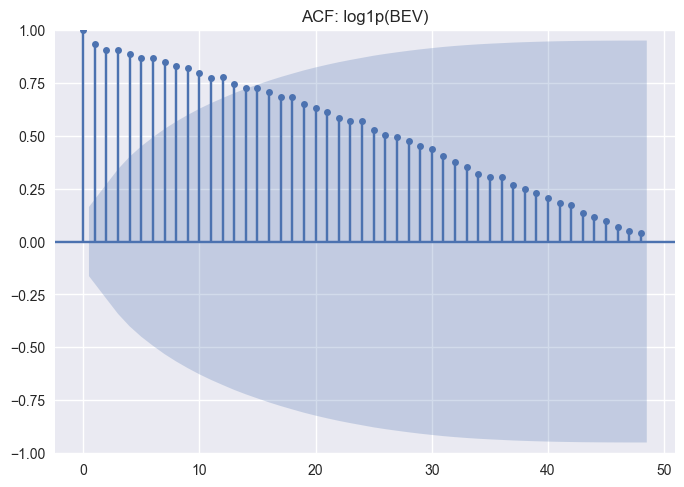

<Figure size 800x550 with 0 Axes>

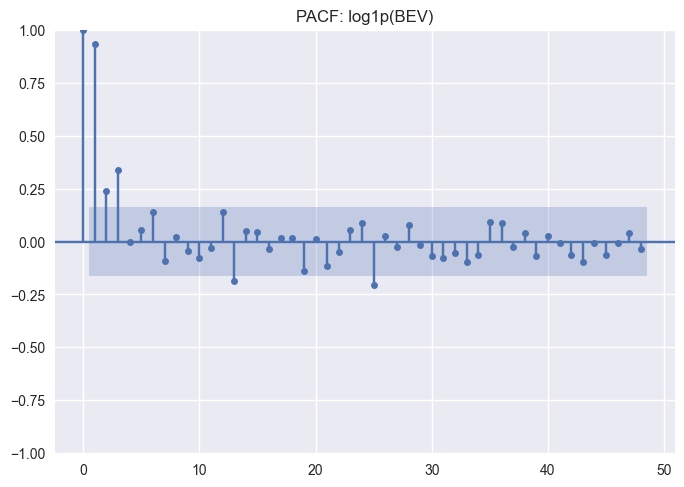

<Figure size 800x550 with 0 Axes>

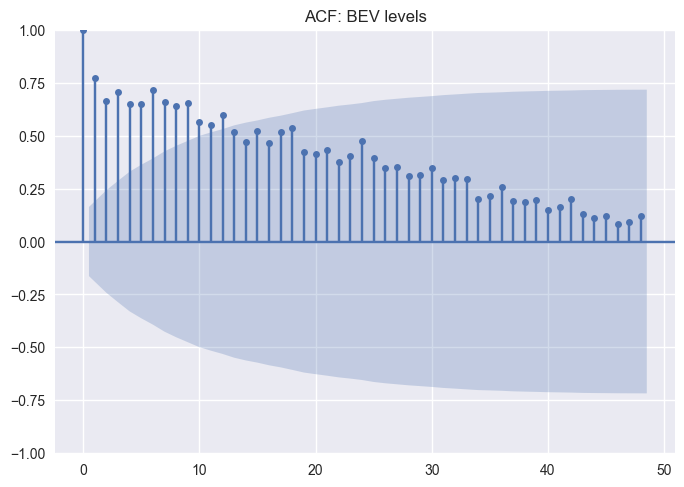

<Figure size 800x550 with 0 Axes>

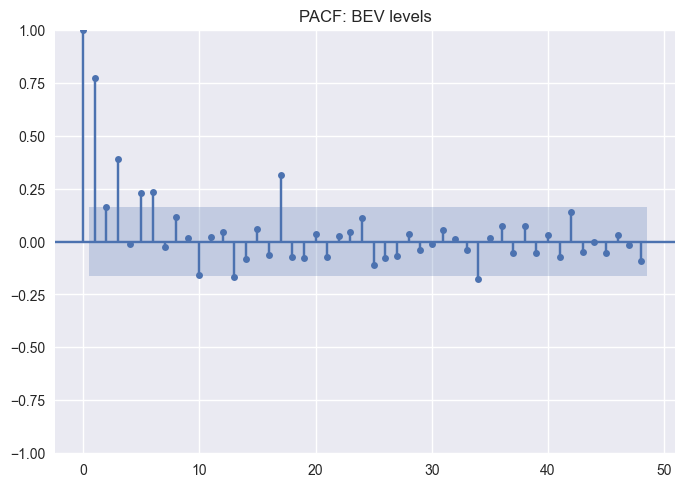

<Figure size 800x550 with 0 Axes>

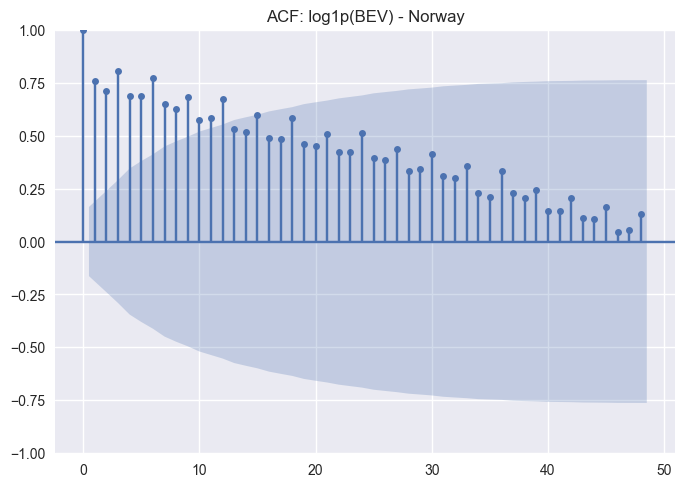

<Figure size 800x550 with 0 Axes>

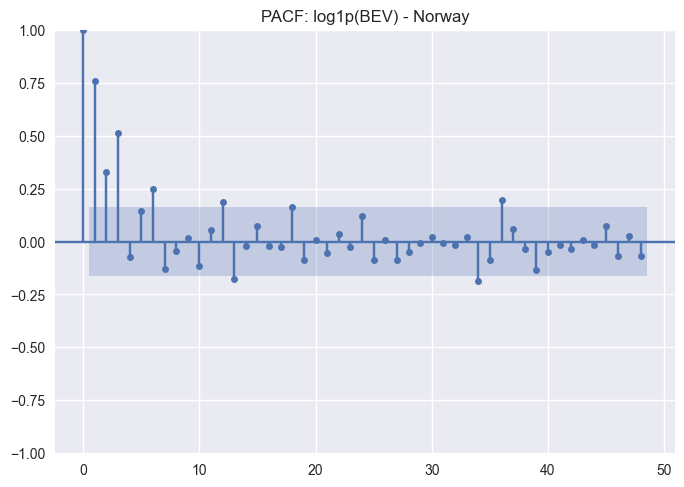

<Figure size 800x550 with 0 Axes>

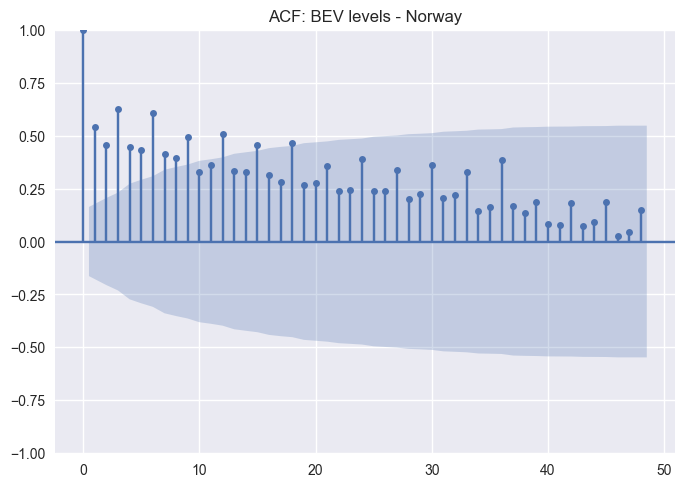

<Figure size 800x550 with 0 Axes>

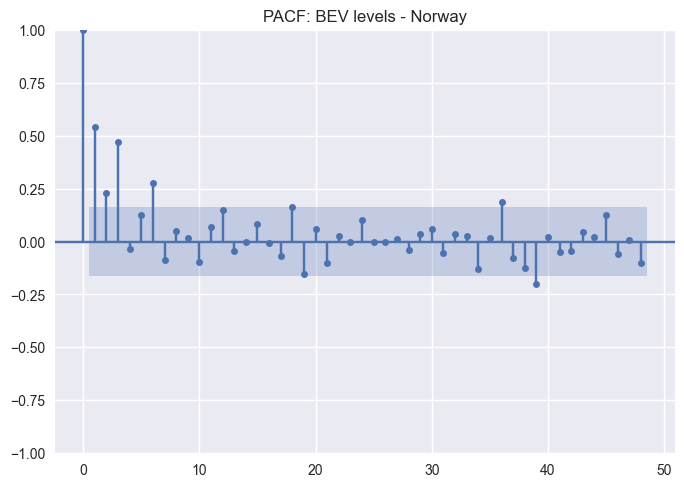

In [21]:
x = ts_log.dropna()

plt.figure()
plot_acf(x, lags=48)
plt.title("ACF: log1p(BEV)")
plt.show()

plt.figure()
plot_pacf(x, lags=48, method="ywm")
plt.title("PACF: log1p(BEV)")
plt.show()

x_raw = ts.dropna()

plt.figure()
plot_acf(x_raw, lags=48)
plt.title("ACF: BEV levels")
plt.show()

plt.figure()
plot_pacf(x_raw, lags=48, method="ywm")
plt.title("PACF: BEV levels")
plt.show()


#Norway
x_2 = ts_log_2.dropna()

plt.figure()
plot_acf(x_2, lags=48)
plt.title("ACF: log1p(BEV) - Norway")
plt.show()
plt.figure()
plot_pacf(x_2, lags=48, method="ywm")
plt.title("PACF: log1p(BEV) - Norway")
plt.show()

x_raw_2 = ts_2.dropna()

plt.figure()
plot_acf(x_raw_2, lags=48)
plt.title("ACF: BEV levels - Norway")
plt.show()

plt.figure()
plot_pacf(x_raw_2, lags=48, method="ywm")
plt.title("PACF: BEV levels - Norway")
plt.show()

### Outliers / shocks: simple detection

In [22]:
z = (x - x.rolling(12, min_periods=6).mean()) / x.rolling(12, min_periods=6).std()
outliers = z[np.abs(z) > 2.5]

print("Potential shock months (|z|>2.5):")
print(outliers)


Potential shock months (|z|>2.5):
date
2025-08-01   -2.532904
Freq: MS, Name: bev, dtype: float64


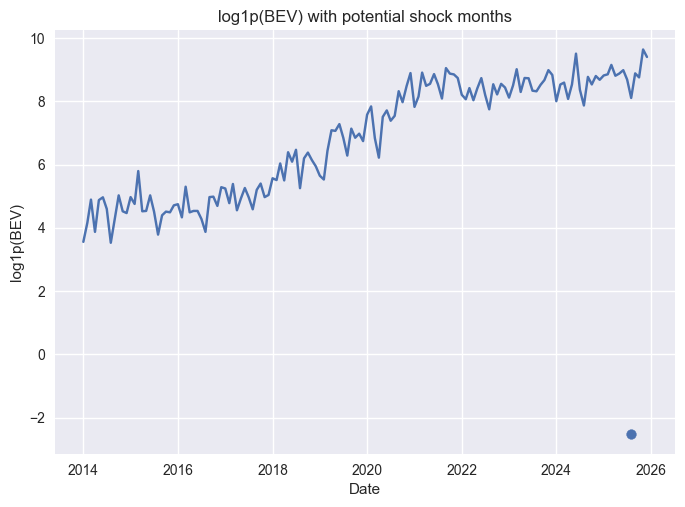

In [23]:
plt.figure()
plt.plot(x.index, x.values)
plt.scatter(outliers.index, outliers.values, marker="o")
plt.title("log1p(BEV) with potential shock months")
plt.xlabel("Date")
plt.ylabel("log1p(BEV)")
plt.show()


### BASS MODEL

In [24]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def bass_flow(p, q, m, T):
    """Bass expected flow (monthly new adopters) for t=1..T."""
    s = np.zeros(T, dtype=float)
    Y_cum = 0.0
    for t in range(T):
        F_prev = Y_cum / m
        s_t = m * (p + q * F_prev) * (1 - F_prev)
        s_t = max(s_t, 1e-12)
        s[t] = s_t
        Y_cum = min(Y_cum + s_t, m * (1 - 1e-9))
    return s

def fit_bass_on_log1p_flow(ts_bev: pd.Series, train_end: str):
    """Fit Bass by minimizing MSE between log1p(observed flow) and log1p(predicted flow)."""
    ts_bev = ts_bev.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end]
    y = np.log1p(train.values)
    bev = train.values
    T = len(train)

    cum_obs = float(np.sum(bev))
    p0, q0 = 0.01, 0.4
    m0 = max(cum_obs * 1.5, 1.0)

    bounds = [
        (1e-6, 1.0),            # p
        (1e-6, 5.0),            # q
        (cum_obs * 1.01, cum_obs * 200.0 + 1e6)  # m
    ]

    def obj(theta):
        p, q, m = theta
        s_hat = bass_flow(p, q, m, T)
        y_hat = np.log1p(s_hat)
        return float(np.mean((y - y_hat) ** 2))

    res = minimize(obj, x0=np.array([p0, q0, m0]), bounds=bounds, method="L-BFGS-B")
    p_hat, q_hat, m_hat = res.x
    return {"p": float(p_hat), "q": float(q_hat), "m": float(m_hat), "success": bool(res.success), "fun": float(res.fun)}

def bass_predict_log1p_train(ts_bev: pd.Series, params: dict, train_end: str):
    """In-sample fitted values for train window."""
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T = len(train)
    s_hat = bass_flow(params["p"], params["q"], params["m"], T)
    return pd.Series(np.log1p(s_hat), index=train.index)

def bass_forecast_log1p(ts_bev: pd.Series, params: dict, train_end: str, horizon: int):
    """Out-of-sample forecast continuing from the end-of-train state (approx via fitted cumulative)."""
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T_train = len(train)

    # Use predicted training flows to set consistent cumulative state
    s_train_hat = bass_flow(params["p"], params["q"], params["m"], T_train)
    Y_cum = float(np.sum(s_train_hat))
    Y_cum = min(Y_cum, params["m"] * (1 - 1e-9))

    s_fore = np.zeros(horizon, dtype=float)
    for h in range(horizon):
        F_prev = Y_cum / params["m"]
        s_h = params["m"] * (params["p"] + params["q"] * F_prev) * (1 - F_prev)
        s_h = max(s_h, 1e-12)
        s_fore[h] = s_h
        Y_cum = min(Y_cum + s_h, params["m"] * (1 - 1e-9))

    # build forecast index
    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx = pd.date_range(start=start, periods=horizon, freq="MS")
    return pd.Series(np.log1p(s_fore), index=idx)

## RAW

def fit_bass_on_raw_flow_wmse(ts_bev: pd.Series, train_end: str, eps=50.0):
    """
    Weighted MSE: weights = 1/(y+eps). Helps stabilize count heteroskedasticity.
    """
    ts_bev = ts_bev.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end]

    y = train.values.astype(float)
    T = len(train)

    cum_obs = float(np.sum(y))
    p0, q0 = 0.01, 0.4
    m0 = max(cum_obs * 1.5, 1.0)

    bounds = [
        (1e-6, 1.0),
        (1e-6, 5.0),
        (cum_obs * 1.01, cum_obs * 200.0 + 1e6)
    ]

    w = 1.0 / (y + eps)

    def obj(theta):
        p, q, m = theta
        s_hat = bass_flow(p, q, m, T)
        return float(np.mean(w * (y - s_hat) ** 2))

    res = minimize(obj, x0=np.array([p0, q0, m0]), bounds=bounds, method="L-BFGS-B")
    p_hat, q_hat, m_hat = res.x
    return {
        "p": float(p_hat), "q": float(q_hat), "m": float(m_hat),
        "success": bool(res.success), "fun": float(res.fun)
    }

def bass_predict_train_raw(ts_bev: pd.Series, params: dict, train_end: str):
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T = len(train)
    s_hat = bass_flow(params["p"], params["q"], params["m"], T)
    return pd.Series(s_hat, index=train.index)

def bass_forecast_raw(ts_bev: pd.Series, params: dict, train_end: str, horizon: int):
    train_end = pd.to_datetime(train_end)
    train = ts_bev[ts_bev.index <= train_end].dropna()
    T_train = len(train)

    # use predicted training flows for consistent cumulative state
    s_train_hat = bass_flow(params["p"], params["q"], params["m"], T_train)
    Y_cum = float(np.sum(s_train_hat))
    Y_cum = min(Y_cum, params["m"] * (1 - 1e-9))

    s_fore = np.zeros(horizon, dtype=float)
    for h in range(horizon):
        F_prev = Y_cum / params["m"]
        s_h = params["m"] * (params["p"] + params["q"] * F_prev) * (1 - F_prev)
        s_h = max(s_h, 1e-12)
        s_fore[h] = s_h
        Y_cum = min(Y_cum + s_h, params["m"] * (1 - 1e-9))

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx = pd.date_range(start=start, periods=horizon, freq="MS")
    return pd.Series(s_fore, index=idx)


## Dynamic Market Potential

In [25]:
def M_exp(t, M0, gamma):
    """Exponential market potential: M_t = M0 * exp(gamma * t)"""
    return M0 * np.exp(gamma * t)

def M_logistic(t, M_min, M_max, k, t0):
    """
    Saturating market potential:
    M_t = M_min + (M_max - M_min) / (1 + exp(-k*(t - t0)))
    """
    return M_min + (M_max - M_min) / (1.0 + np.exp(-k * (t - t0)))
def bass_dynamic_flow(p, q, M_t):
    """
    Discrete-time Bass with time-varying market potential M_t.
    Returns predicted flows s_t on RAW scale.
    """
    T = len(M_t)
    s = np.zeros(T, dtype=float)
    Y = 0.0  # cumulative adopters

    for t in range(T):
        Mt = max(M_t[t], 1e-9)
        Mt_prev = max(M_t[t-1], 1e-9) if t > 0 else Mt

        F_prev = min(max(Y / Mt_prev, 0.0), 1.0)
        s_t = (p + q * F_prev) * (Mt - Y)

        s_t = max(s_t, 1e-12)
        s[t] = s_t
        Y = min(Y + s_t, Mt * (1 - 1e-9))

    return s

def fit_dynamic_bass_logisticM(ts_flow: pd.Series, train_end: str,
                                  k_max=0.05, t0_lo=0.1, t0_hi=0.9,
                                  reg=1e-8):
    ts_flow = ts_flow.dropna().astype(float)
    train_end = pd.to_datetime(train_end)
    train = ts_flow.loc[:train_end]
    y = train.values
    T = len(train)
    t = np.arange(T, dtype=float)

    cum_obs = float(y.sum())
    y_max = float(y.max())

    # ---- initial guesses ----
    p0, q0 = 0.001, 0.08

    # anchor market potentials to data scale
    M_min0 = max(cum_obs * 0.9, y_max * 12)          # not too low
    M_max0 = max(cum_obs * 1.2, y_max * 36)          # modest headroom

    k0  = min(0.02, k_max * 0.5)
    t00 = T * 0.5

    x0 = np.array([p0, q0, M_min0, M_max0, k0, t00], dtype=float)

    # ---- bounds ----
    t0_lower = t0_lo * T
    t0_upper = t0_hi * T

    bounds = [
        (1e-5, 0.2),                 # p (tighter, realistic monthly)
        (1e-5, 1.5),                 # q
        (cum_obs * 0.5, cum_obs*2),  # M_min anchored
        (cum_obs * 1.05, cum_obs*8), # M_max anchored (avoid crazy)
        (1e-4, k_max),               # k smaller upper bound
        (t0_lower, t0_upper)         # t0 inside sample
    ]

    def obj(theta):
        p, q, M_min, M_max, k, t0 = theta
        if M_max <= M_min:
            return 1e30

        M_t = M_logistic(t, M_min, M_max, k, t0)
        s_hat = bass_dynamic_flow(p, q, M_t)

        mse = np.mean((y - s_hat) ** 2)

        # mild regularization to avoid boundary solutions
        pen = reg * ((k / k_max) ** 2 + ((t0 - T/2) / (T/2)) ** 2)

        return float(mse + pen)

    res = minimize(obj, x0=x0, bounds=bounds, method="L-BFGS-B")

    p, q, M_min, M_max, k, t0 = res.x
    M_t = M_logistic(t, M_min, M_max, k, t0)
    s_hat = bass_dynamic_flow(p, q, M_t)

    yhat_train = pd.Series(s_hat, index=train.index)
    resid_train = train - yhat_train

    return {
        "p": float(p), "q": float(q),
        "M_min": float(M_min), "M_max": float(M_max),
        "k": float(k), "t0": float(t0),
        "success": bool(res.success), "fun": float(res.fun),
        "yhat_train": yhat_train,
        "resid_train": resid_train,
    }

def forecast_dynamic_bass_logisticM(ts_flow: pd.Series, fit: dict, train_end: str, horizon: int):
    ts_flow = ts_flow.dropna().astype(float)
    train_end = pd.to_datetime(train_end)
    train = ts_flow.loc[:train_end]
    T_train = len(train)

    p, q = fit["p"], fit["q"]
    M_min, M_max, k, t0 = fit["M_min"], fit["M_max"], fit["k"], fit["t0"]

    T_total = T_train + horizon
    t_all = np.arange(T_total, dtype=float)
    M_all = M_logistic(t_all, M_min, M_max, k, t0)

    s_all = bass_dynamic_flow(p, q, M_all)
    s_fore = s_all[T_train:]

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx = pd.date_range(start=start, periods=horizon, freq="MS")
    return pd.Series(s_fore, index=idx)



### Split + compute residuals from diffusion mean

In [26]:
TRAIN_END = "2022-12-01"
H = 24  # forecast horizon months (choose 12 or 24)

params = fit_bass_on_log1p_flow(ts, train_end=TRAIN_END)
print("Bass params:", params)

yhat_train = bass_predict_log1p_train(ts, params, train_end=TRAIN_END)
yhat_fore  = bass_forecast_log1p(ts, params, train_end=TRAIN_END, horizon=H)

# Actual log series
ts_log = np.log1p(ts).dropna()

# Align true test window
test = ts_log[ts_log.index > pd.to_datetime(TRAIN_END)].iloc[:H]

# Residuals on training window: e_t = y_t - yhat_t
resid_train = (ts_log.loc[yhat_train.index] - yhat_train).dropna()

##Raw

params_raw = fit_bass_on_raw_flow_wmse(ts, train_end=TRAIN_END, eps=50.0)
print("Bass params (raw):", params_raw)
yhat_train_raw = bass_predict_train_raw(ts, params_raw, train_end=TRAIN_END)
yhat_fore_raw  = bass_forecast_raw(ts, params_raw, train_end=TRAIN_END, horizon=H)
# Actual series
ts_raw = ts.dropna()
# Align true test window
test_raw = ts_raw[ts_raw.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Residuals on training window: e_t = y_t - yhat_t
resid_train_raw = (ts_raw.loc[yhat_train_raw.index] - yhat_train_raw).dropna()


### Norway

params_2 = fit_bass_on_log1p_flow(ts_2, train_end=TRAIN_END)
print("Bass params Norway:", params_2)
yhat_train_2 = bass_predict_log1p_train(ts_2, params_2, train_end=TRAIN_END)
yhat_fore_2  = bass_forecast_log1p(ts_2, params_2, train_end=TRAIN_END, horizon=H)
# Actual log series
ts_log_2 = np.log1p(ts_2).dropna()
# Align true test window
test_2 = ts_log_2[ts_log_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Residuals on training window: e_t = y_t - yhat_t
resid_train_2 = (ts_log_2.loc[yhat_train_2.index] - yhat_train_2).dropna()

## Norway Raw

params_raw_2 = fit_bass_on_raw_flow_wmse(ts_2, train_end=TRAIN_END, eps=50.0)
print("Bass params Norway (raw):", params_raw_2)
yhat_train_raw_2 = bass_predict_train_raw(ts_2, params_raw_2, train_end=TRAIN_END)
yhat_fore_raw_2  = bass_forecast_raw(ts_2, params_raw_2, train_end=TRAIN_END, horizon=H)
# Actual series
ts_raw_2 = ts_2.dropna()
# Align true test window
test_raw_2 = ts_raw_2[ts_raw_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Residuals on training window: e_t = y_t - yhat_t
resid_train_raw_2 = (ts_raw_2.loc[yhat_train_raw_2.index] - yhat_train_raw_2).dropna()

Bass params: {'p': 0.00011784965274412191, 'q': 0.05693030967228811, 'm': 256123.49997808307, 'success': True, 'fun': 0.39562600548839866}
Bass params (raw): {'p': 2.8970236598388893e-05, 'q': 0.07822653114367169, 'm': 256121.64574838296, 'success': True, 'fun': 278.6158666598908}
Bass params Norway: {'p': 0.0012111667896449866, 'q': 0.03235761863412467, 'm': 801551.999995023, 'success': True, 'fun': 0.1469033690847604}
Bass params Norway (raw): {'p': 0.0008151045872609611, 'q': 0.03698409870762981, 'm': 801551.3907677364, 'success': True, 'fun': 724.0888422940008}


In [27]:
fit = fit_dynamic_bass_logisticM(ts, TRAIN_END)

T = len(ts.loc[:TRAIN_END])
t = np.arange(T)
M_t = M_logistic(t, fit["M_min"], fit["M_max"], fit["k"], fit["t0"])

print("p,q:", fit["p"], fit["q"])
print("M_min/M_max:", fit["M_min"], fit["M_max"])
print("k,t0:", fit["k"], fit["t0"])
print("M(t) start/end:", float(M_t[0]), float(M_t[-1]))
print("cum_obs:", float(ts.loc[:TRAIN_END].sum()))


p,q: 5.204571517923277e-05 0.0800792941616586
M_min/M_max: 153643.69550143546 305697.08458562527
k,t0: 0.0037106163236037526 27.219560802398636
M(t) start/end: 225834.25134926406 240842.18693368346
cum_obs: 170749.0


In [28]:
TRAIN_END = "2022-12-01"
H = 24

# 1) Fit diffusion on RAW
dyn_fit = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_raw = dyn_fit["yhat_train"]
dyn_yhat_fore_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit, train_end=TRAIN_END, horizon=H)

# 2) Build LOG series for evaluation
ts_log = np.log1p(ts).dropna()

# 3) Convert diffusion predictions to LOG before residuals
dyn_yhat_train_log = np.log1p(dyn_yhat_train_raw)
dyn_yhat_fore_log  = np.log1p(dyn_yhat_fore_raw)

# 4) Define train/test windows in LOG
train_log = ts_log.loc[dyn_yhat_train_log.index]
test_log  = ts_log.loc[dyn_yhat_fore_log.index]   # aligns automatically

# 5) Residuals in LOG
dyn_resid_train_log = (train_log - dyn_yhat_train_log).dropna()

##Raw

dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
print("Italy DynamicBass params:", {k: dyn_fit_it[k] for k in ["p","q","M_min","M_max","k","t0"]})

# In-sample fitted (RAW)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]

# Forecast (RAW)
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

# Actual RAW series
ts_it_raw = ts.dropna().astype(float)

# True test window (RAW)
test_it_raw = ts_it_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]

# Residuals on training window (RAW)
resid_train_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()

yhat_fore_raw_2  = bass_forecast_raw(ts_2, params_raw_2, train_end=TRAIN_END, horizon=H)
# Actual series
ts_raw_2 = ts_2.dropna()
# Align true test window
test_raw_2 = ts_raw_2[ts_raw_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Residuals on training window: e_t = y_t - yhat_t
resid_train_raw_2 = (ts_raw_2.loc[yhat_train_raw_2.index] - yhat_train_raw_2).dropna()

## Norway

# Fit diffusion on RAW Norway
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
print("Norway DynamicBass params:", {k: dyn_fit_no[k] for k in ["p","q","M_min","M_max","k","t0"]})

# In-sample fitted (RAW)
dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]

# Forecast (RAW)
dyn_yhat_fore_no_raw  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)

# Actual LOG series
ts_no_log = np.log1p(ts_2.dropna().astype(float))

# Convert diffusion predictions to LOG
dyn_yhat_train_no_log = np.log1p(np.clip(dyn_yhat_train_no_raw, 0, None))
dyn_yhat_fore_no_log  = np.log1p(np.clip(dyn_yhat_fore_no_raw, 0, None))

# True test window (LOG)
test_no_log = ts_no_log.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]

# Residuals on training window (LOG)
resid_train_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()

##Norway Raw

dyn_fit_no_raw = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
print("Norway DynamicBass params (raw):", {k: dyn_fit_no_raw[k] for k in ["p","q","M_min","M_max","k","t0"]})

# In-sample fitted (RAW)
dyn_yhat_train_no_raw2 = dyn_fit_no_raw["yhat_train"]

# Forecast (RAW)
dyn_yhat_fore_no_raw2  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no_raw, train_end=TRAIN_END, horizon=H)

# Actual RAW series
ts_no_raw = ts_2.dropna().astype(float)

# True test window (RAW)
test_no_raw = ts_no_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]

# Residuals on training window (RAW)
resid_train_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw2.index] - dyn_yhat_train_no_raw2).dropna()

Italy DynamicBass params: {'p': 5.204571517923277e-05, 'q': 0.0800792941616586, 'M_min': 153643.69550143546, 'M_max': 305697.08458562527, 'k': 0.0037106163236037526, 't0': 27.219560802398636}
Norway DynamicBass params: {'p': 0.000817831065187412, 'q': 0.04282633523151428, 'M_min': 480929.9462257639, 'M_max': 1176910.8267427501, 'k': 0.05, 't0': 74.88469413891039}
Norway DynamicBass params (raw): {'p': 0.000817831065187412, 'q': 0.04282633523151428, 'M_min': 480929.9462257639, 'M_max': 1176910.8267427501, 'k': 0.05, 't0': 74.88469413891039}


### Diffusion + SARIMAX residuals

In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_residual_sarimax(resid_train: pd.Series):
    # A reasonable starting model for monthly residuals:
    # ARMA(1,1) with seasonal AR(1) at 12 (you can auto-tune later)
    model = SARIMAX(
        resid_train,
        order=(1,0,1),
        seasonal_order=(1,0,0,12),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    return res

sarimax_fit = fit_residual_sarimax(resid_train)

# residual forecast
resid_fore = sarimax_fit.get_forecast(steps=H).predicted_mean
resid_fore.index = yhat_fore.index  # align

# Final forecast = diffusion mean + residual forecast
y_fore_sarimax = yhat_fore + resid_fore

print("Done: diffusion + SARIMAX residual baseline")

#RAW

sarimax_fit_raw = fit_residual_sarimax(resid_train_raw)
# residual forecast
resid_fore_raw = sarimax_fit_raw.get_forecast(steps=H).predicted_mean
resid_fore_raw.index = yhat_fore_raw.index  # align
# Final forecast = diffusion mean + residual forecast
y_fore_sarimax_raw = yhat_fore_raw + resid_fore_raw
print("Done: diffusion + SARIMAX residual baseline - raw")

## Norway

sarimax_fit_2 = fit_residual_sarimax(resid_train_2)
# residual forecast
resid_fore_2 = sarimax_fit_2.get_forecast(steps=H).predicted_mean
resid_fore_2.index = yhat_fore_2.index  # align
# Final forecast = diffusion mean + residual forecast
y_fore_sarimax_2 = yhat_fore_2 + resid_fore_2
print("Done: diffusion + SARIMAX residual baseline - Norway")

#RAW Norway
sarimax_fit_raw_2 = fit_residual_sarimax(resid_train_raw_2)
# residual forecast
resid_fore_raw_2 = sarimax_fit_raw_2.get_forecast(steps=H).predicted_mean
resid_fore_raw_2.index = yhat_fore_raw_2.index  # align
# Final forecast = diffusion mean + residual forecast
y_fore_sarimax_raw_2 = yhat_fore_raw_2 + resid_fore_raw_2
print("Done: diffusion + SARIMAX residual baseline - raw - Norway")


Done: diffusion + SARIMAX residual baseline
Done: diffusion + SARIMAX residual baseline - raw
Done: diffusion + SARIMAX residual baseline - Norway
Done: diffusion + SARIMAX residual baseline - raw - Norway


In [42]:
# --- DynamicBass + SARIMAX (Italy, LOG) ---
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_it_log = np.log1p(np.clip(dyn_yhat_train_it_raw, 0, None))
dyn_yhat_fore_it_log  = np.log1p(np.clip(dyn_yhat_fore_it_raw, 0, None))

ts_it_log = np.log1p(ts.dropna().astype(float))
resid_train_dyn_it_log = (ts_it_log.loc[dyn_yhat_train_it_log.index] - dyn_yhat_train_it_log).dropna()
sarimax_fit_dyn_it_log = fit_residual_sarimax(resid_train_dyn_it_log)

resid_fore_dyn_it_log = sarimax_fit_dyn_it_log.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_log.index = dyn_yhat_fore_it_log.index  # align

y_fore_sarimax_dyn_it_log = dyn_yhat_fore_it_log + resid_fore_dyn_it_log

print("Done: DynamicBass + SARIMAX residual - Italy (log)")

# --- DynamicBass + SARIMAX (Italy, RAW) ---

ts_it_raw = ts.dropna().astype(float)
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()
sarimax_fit_dyn_it_raw = fit_residual_sarimax(resid_train_dyn_it_raw)

resid_fore_dyn_it_raw = sarimax_fit_dyn_it_raw.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_raw.index = dyn_yhat_fore_it_raw.index  # align

y_fore_sarimax_dyn_it_raw = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw

print("Done: DynamicBass + SARIMAX residual - Italy (raw)")


# --- DynamicBass + SARIMAX (Norway, LOG) ---

ts_no_log = np.log1p(ts_2.dropna().astype(float))
resid_train_dyn_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()
sarimax_fit_dyn_no_log = fit_residual_sarimax(resid_train_dyn_no_log)

resid_fore_dyn_no_log = sarimax_fit_dyn_no_log.get_forecast(steps=H).predicted_mean
resid_fore_dyn_no_log.index = dyn_yhat_fore_no_log.index  # align

y_fore_sarimax_dyn_no_log = dyn_yhat_fore_no_log + resid_fore_dyn_no_log

print("Done: DynamicBass + SARIMAX residual - Norway (log)")


# --- DynamicBass + SARIMAX (Norway, RAW) ---

ts_no_raw = ts_2.dropna().astype(float)
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()
sarimax_fit_dyn_no_raw = fit_residual_sarimax(resid_train_dyn_no_raw)

resid_fore_dyn_no_raw = sarimax_fit_dyn_no_raw.get_forecast(steps=H).predicted_mean
resid_fore_dyn_no_raw.index = dyn_yhat_fore_no_raw.index  # align

y_fore_sarimax_dyn_no_raw = dyn_yhat_fore_no_raw + resid_fore_dyn_no_raw

print("Done: DynamicBass + SARIMAX residual - Norway (raw)")

Done: DynamicBass + SARIMAX residual - Italy (log)
Done: DynamicBass + SARIMAX residual - Italy (raw)
Done: DynamicBass + SARIMAX residual - Norway (log)
Done: DynamicBass + SARIMAX residual - Norway (raw)


### Diffusion + Neural residual model

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class ResidualDataset(Dataset):
    def __init__(self, resid: pd.Series, lookback=24):
        self.lookback = lookback
        self.resid = resid.values.astype(np.float32)
        self.months = resid.index.month.astype(np.int64)  # 1..12
        self.X, self.m, self.y = [], [], []
        for i in range(lookback, len(self.resid)):
            self.X.append(self.resid[i-lookback:i])      # (lookback,)
            self.m.append(self.months[i-1])              # month for current step context
            self.y.append(self.resid[i])                 # next residual
        self.X = np.stack(self.X)
        self.m = np.array(self.m)
        self.y = np.array(self.y).astype(np.float32)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]).unsqueeze(-1),  # (lookback, 1)
            torch.tensor(self.m[idx]-1),                  # 0..11
            torch.tensor(self.y[idx])                     # scalar
        )


### LSTM residual model

In [32]:
class ResidualLSTM(nn.Module):
    def __init__(self, hidden=64, month_emb=8):
        super().__init__()
        self.month_emb = nn.Embedding(12, month_emb)
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden + month_emb, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq, month_idx):
        # x_seq: (B, L, 1), month_idx: (B,)
        _, (h, _) = self.lstm(x_seq)       # h: (1, B, hidden)
        h = h[-1]                          # (B, hidden)
        m = self.month_emb(month_idx)      # (B, month_emb)
        out = self.head(torch.cat([h, m], dim=1))
        return out.squeeze(-1)             # (B,)


### TCN resiual model

In [33]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Dataset ----------
class ResidualTCNDataset(Dataset):
    """
    Predict e_t from past residuals + calendar features.
    Inputs:
      - past residual window (lookback)
      - explicit lag12 residual
      - month sin/cos
    """
    def __init__(self, resid: pd.Series, lookback=36):
        resid = resid.dropna()
        self.lookback = lookback
        r = resid.values.astype(np.float32)
        months = resid.index.month.astype(np.int64)

        X = []
        y = []

        for i in range(lookback, len(r)):
            window = r[i-lookback:i]  # (L,)
            # features for current step i (predict r[i])
            m = months[i]  # 1..12
            m_sin = np.sin(2*np.pi*m/12.0)
            m_cos = np.cos(2*np.pi*m/12.0)
            lag12 = r[i-12] if i-12 >= 0 else 0.0

            # concatenate extra features as additional channels later
            X.append((window, lag12, m_sin, m_cos))
            y.append(r[i])

        self.y = torch.tensor(np.array(y, dtype=np.float32))
        self.window = torch.tensor(np.stack([x[0] for x in X]).astype(np.float32))  # (N, L)
        self.lag12 = torch.tensor(np.array([x[1] for x in X], dtype=np.float32)).unsqueeze(-1)  # (N,1)
        self.m_sin = torch.tensor(np.array([x[2] for x in X], dtype=np.float32)).unsqueeze(-1)  # (N,1)
        self.m_cos = torch.tensor(np.array([x[3] for x in X], dtype=np.float32)).unsqueeze(-1)  # (N,1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # window -> (L,1) for conv1d after permute
        w = self.window[idx].unsqueeze(-1)  # (L,1)
        feats = torch.cat([self.lag12[idx], self.m_sin[idx], self.m_cos[idx]], dim=-1)  # (1,3) logically
        return w, feats, self.y[idx]


# ---------- Small TCN ----------
class CausalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.1):
        super().__init__()
        self.pad = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size=kernel, dilation=dilation)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.res = (nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        # x: (B, C, L)
        x_padded = nn.functional.pad(x, (self.pad, 0))  # left pad for causality
        h = self.conv(x_padded)
        h = self.act(h)
        h = self.drop(h)
        return h + self.res(x)

class ResidualTCN(nn.Module):
    def __init__(self, hidden=32, levels=4, kernel=3, dropout=0.1):
        super().__init__()
        layers = []
        in_ch = 1
        for i in range(levels):
            layers.append(CausalConvBlock(in_ch, hidden, kernel=kernel, dilation=2**i, dropout=dropout))
            in_ch = hidden
        self.tcn = nn.Sequential(*layers)
        # combine last hidden state with extra features (lag12, sin, cos)
        self.head = nn.Sequential(
            nn.Linear(hidden + 3, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, window, extra_feats):
        # window: (B, L, 1)
        x = window.permute(0, 2, 1)  # (B, 1, L)
        h = self.tcn(x)              # (B, hidden, L)
        h_last = h[:, :, -1]         # (B, hidden)
        out = self.head(torch.cat([h_last, extra_feats], dim=1))
        return out.squeeze(-1)


def train_tcn(resid_train: pd.Series, lookback=36, epochs=500, batch_size=16, lr=1e-3):
    ds = ResidualTCNDataset(resid_train, lookback=lookback)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    model = ResidualTCN(hidden=32, levels=4, kernel=3, dropout=0.15).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for ep in range(epochs):
        model.train()
        total = 0.0
        for w, feats, y in dl:
            w = w.to(DEVICE)
            feats = feats.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(w, feats)
            loss = loss_fn(pred, y)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item())

        if (ep+1) % 100 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")

    return model


@torch.no_grad()
def forecast_tcn(model, resid_train: pd.Series, start_date, horizon=12, lookback=36):
    model.eval()
    history = resid_train.values.astype(np.float32).tolist()
    idx = pd.date_range(start=pd.to_datetime(start_date), periods=horizon, freq="MS")

    preds = []
    for d in idx:
        m = d.month
        m_sin = np.sin(2*np.pi*m/12.0)
        m_cos = np.cos(2*np.pi*m/12.0)
        lag12 = history[-12] if len(history) >= 12 else 0.0

        window = np.array(history[-lookback:], dtype=np.float32).reshape(1, lookback, 1)
        feats = np.array([[lag12, m_sin, m_cos]], dtype=np.float32)

        w_t = torch.from_numpy(window).to(DEVICE)
        f_t = torch.from_numpy(feats).to(DEVICE)

        r_hat = model(w_t, f_t).cpu().numpy()[0]
        preds.append(float(r_hat))
        history.append(float(r_hat))

    return pd.Series(preds, index=idx)


In [34]:
LOOKBACK = 36
tcn_model = train_tcn(resid_train, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn = forecast_tcn(tcn_model, resid_train, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)

y_fore_tcn = yhat_fore + resid_fore_tcn

#RAW

tcn_model_raw = train_tcn(resid_train_raw, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn_raw = forecast_tcn(tcn_model_raw, resid_train_raw, start_date=start_fore_date_raw, horizon=H, lookback=LOOKBACK)
y_fore_tcn_raw = yhat_fore_raw + resid_fore_tcn_raw

# Norway

tcn_model_2 = train_tcn(resid_train_2, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn_2 = forecast_tcn(tcn_model_2, resid_train_2, start_date=start_fore_date_2, horizon=H, lookback=LOOKBACK)
y_fore_tcn_2 = yhat_fore_2 + resid_fore_tcn_2

# RAW Norway

tcn_model_raw_2 = train_tcn(resid_train_raw_2, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_tcn_raw_2 = forecast_tcn(tcn_model_raw_2, resid_train_raw_2, start_date=start_fore_date_raw_2, horizon=H, lookback=LOOKBACK)
y_fore_tcn_raw_2 = yhat_fore_raw_2 + resid_fore_tcn_raw_2


Epoch 100/800 loss=0.026851
Epoch 200/800 loss=0.008833
Epoch 300/800 loss=0.009245
Epoch 400/800 loss=0.007981
Epoch 500/800 loss=0.006766
Epoch 600/800 loss=0.002810
Epoch 700/800 loss=0.005261
Epoch 800/800 loss=0.004506
Epoch 100/800 loss=104931.020508
Epoch 200/800 loss=61232.368164
Epoch 300/800 loss=65312.787598
Epoch 400/800 loss=42576.648438
Epoch 500/800 loss=35085.839600
Epoch 600/800 loss=24357.166260
Epoch 700/800 loss=17677.557373
Epoch 800/800 loss=29652.402588
Epoch 100/800 loss=0.014429
Epoch 200/800 loss=0.006663
Epoch 300/800 loss=0.004419
Epoch 400/800 loss=0.004747
Epoch 500/800 loss=0.003361
Epoch 600/800 loss=0.002084
Epoch 700/800 loss=0.001721
Epoch 800/800 loss=0.002001
Epoch 100/800 loss=841169.843750
Epoch 200/800 loss=276907.628906
Epoch 300/800 loss=211574.261719
Epoch 400/800 loss=176412.078125
Epoch 500/800 loss=169068.970703
Epoch 600/800 loss=159248.441406
Epoch 700/800 loss=284992.632812
Epoch 800/800 loss=82608.155273


In [ ]:
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

def month_start_after(date_str: str):
    return (pd.to_datetime(date_str) + pd.DateOffset(months=1)).to_period("M").to_timestamp()

START_FORE_DATE = month_start_after(TRAIN_END)

# ---------------------------
# 1) ITALY — DynamicBass + TCN (LOG)
# ---------------------------
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_it_log = np.log1p(np.clip(dyn_yhat_train_it_raw, 0, None))
dyn_yhat_fore_it_log  = np.log1p(np.clip(dyn_yhat_fore_it_raw, 0, None))

ts_it_log = np.log1p(ts.dropna().astype(float))
resid_train_dyn_it_log = (ts_it_log.loc[dyn_yhat_train_it_log.index] - dyn_yhat_train_it_log).dropna()

tcn_model_dyn_it_log = train_tcn(resid_train_dyn_it_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_it_log = forecast_tcn(tcn_model_dyn_it_log, resid_train_dyn_it_log, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

# Align and final forecast (LOG)
resid_fore_dyn_it_log.index = dyn_yhat_fore_it_log.index
y_fore_dyn_it_log_tcn = dyn_yhat_fore_it_log + resid_fore_dyn_it_log


print("Done: Italy DynamicBass + TCN (LOG)")

# ---------------------------
# 2) ITALY — DynamicBass + TCN (RAW)
# ---------------------------
ts_it_raw = ts.dropna().astype(float)
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()

tcn_model_dyn_it_raw = train_tcn(resid_train_dyn_it_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_it_raw = forecast_tcn(tcn_model_dyn_it_raw, resid_train_dyn_it_raw, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

# Align and final forecast (RAW)
resid_fore_dyn_it_raw.index = dyn_yhat_fore_it_raw.index
y_fore_dyn_it_raw_tcn = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw

print("Done: Italy DynamicBass + TCN (RAW)")

# ---------------------------
# 3) NORWAY — DynamicBass + TCN (LOG)
# ---------------------------
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]
dyn_yhat_fore_no_raw  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_no_log = np.log1p(np.clip(dyn_yhat_train_no_raw, 0, None))
dyn_yhat_fore_no_log  = np.log1p(np.clip(dyn_yhat_fore_no_raw, 0, None))

ts_no_log = np.log1p(ts_2.dropna().astype(float))
resid_train_dyn_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()

tcn_model_dyn_no_log = train_tcn(resid_train_dyn_no_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_log = forecast_tcn(tcn_model_dyn_no_log, resid_train_dyn_no_log, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

# Align and final forecast (LOG)
resid_fore_dyn_no_log.index = dyn_yhat_fore_no_log.index
y_fore_dyn_no_log_tcn = dyn_yhat_fore_no_log + resid_fore_dyn_no_log

print("Done: Norway DynamicBass + TCN (LOG)")

# ---------------------------
# 4) NORWAY — DynamicBass + TCN (RAW)
# ---------------------------
ts_no_raw = ts_2.dropna().astype(float)
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()

tcn_model_dyn_no_raw = train_tcn(resid_train_dyn_no_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_raw = forecast_tcn(tcn_model_dyn_no_raw, resid_train_dyn_no_raw, start_date=START_FORE_DATE, horizon=H, lookback=LOOKBACK)

# Align and final forecast (RAW)
resid_fore_dyn_no_raw.index = dyn_yhat_fore_no_raw.index
y_fore_dyn_no_raw_tcn = dyn_yhat_fore_no_raw + resid_fore_dyn_no_raw

print("Done: Norway DynamicBass + TCN (RAW)")

Epoch 100/800 loss=0.030440
Epoch 200/800 loss=0.010785
Epoch 300/800 loss=0.007045
Epoch 400/800 loss=0.007116
Epoch 500/800 loss=0.005473
Epoch 600/800 loss=0.005451
Epoch 700/800 loss=0.005345
Epoch 800/800 loss=0.002862
Done: Italy DynamicBass + TCN (LOG)
Epoch 100/800 loss=107691.828125
Epoch 200/800 loss=81237.284180
Epoch 300/800 loss=60805.191406
Epoch 400/800 loss=35352.200684
Epoch 500/800 loss=32975.761475
Epoch 600/800 loss=20406.093994
Epoch 700/800 loss=21037.617676
Epoch 800/800 loss=31117.185303
Done: Italy DynamicBass + TCN (RAW)
Epoch 100/800 loss=0.011695
Epoch 200/800 loss=0.007169
Epoch 300/800 loss=0.009031
Epoch 400/800 loss=0.003641
Epoch 500/800 loss=0.002342
Epoch 600/800 loss=0.002384
Epoch 700/800 loss=0.001340
Epoch 800/800 loss=0.001841
Done: Norway DynamicBass + TCN (LOG)
Epoch 100/800 loss=610843.171875
Epoch 200/800 loss=333047.632812
Epoch 300/800 loss=438591.970703
Epoch 400/800 loss=158142.685547
Epoch 500/800 loss=116759.601562
Epoch 600/800 loss=17

### Train NN on residuals

In [36]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_residual_nn(resid_train: pd.Series, lookback=24, epochs=800, batch_size=32, lr=1e-3):
    ds = ResidualDataset(resid_train, lookback=lookback)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)
    model = ResidualLSTM(hidden=64, month_emb=8).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for ep in range(epochs):
        total = 0.0
        for x_seq, m_idx, y in dl:
            x_seq = x_seq.to(DEVICE)
            m_idx = m_idx.to(DEVICE)
            y = y.to(DEVICE)

            pred = model(x_seq, m_idx)
            loss = loss_fn(pred, y)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total += float(loss.item())
        if (ep+1) % 50 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")
    return model

LOOKBACK = 24
nn_model = train_residual_nn(resid_train, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

# RAW
nn_model_raw = train_residual_nn(resid_train_raw, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

# Norway
nn_model_2 = train_residual_nn(resid_train_2, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

# RAW Norway
nn_model_raw_2 = train_residual_nn(resid_train_raw_2, lookback=LOOKBACK, epochs=300, batch_size=32, lr=1e-3)

Epoch 50/300 loss=0.105075
Epoch 100/300 loss=0.097087
Epoch 150/300 loss=0.055056
Epoch 200/300 loss=0.027056
Epoch 250/300 loss=0.008787
Epoch 300/300 loss=0.002408
Epoch 50/300 loss=1570977.312500
Epoch 100/300 loss=1204605.312500
Epoch 150/300 loss=1356176.062500
Epoch 200/300 loss=1349429.453125
Epoch 250/300 loss=1262408.406250
Epoch 300/300 loss=1127482.656250
Epoch 50/300 loss=0.038244
Epoch 100/300 loss=0.029864
Epoch 150/300 loss=0.016481
Epoch 200/300 loss=0.006883
Epoch 250/300 loss=0.003505
Epoch 300/300 loss=0.000764
Epoch 50/300 loss=16308829.750000
Epoch 100/300 loss=14988553.500000
Epoch 150/300 loss=15582617.000000
Epoch 200/300 loss=14897821.250000
Epoch 250/300 loss=13375814.500000
Epoch 300/300 loss=13520448.750000


In [37]:
# ---------------------------
# Hyperparams
# ---------------------------
LOOKBACK = 24
EPOCHS = 300
BATCH = 32
LR = 1e-3

# ============================================================
# 1) ITALY — DynamicBass + LSTM (LOG)
# ============================================================
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_yhat_train_it_raw = dyn_fit_it["yhat_train"]
dyn_yhat_fore_it_raw  = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_it_log = np.log1p(np.clip(dyn_yhat_train_it_raw, 0, None))
dyn_yhat_fore_it_log  = np.log1p(np.clip(dyn_yhat_fore_it_raw, 0, None))

ts_it_log = np.log1p(ts.dropna().astype(float))
resid_train_dyn_it_log = (ts_it_log.loc[dyn_yhat_train_it_log.index] - dyn_yhat_train_it_log).dropna()

nn_model_dyn_it_log = train_residual_nn(resid_train_dyn_it_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)

print("Done: Italy DynamicBass + LSTM (LOG)")

# ============================================================
# 2) ITALY — DynamicBass + LSTM (RAW)
# ============================================================
ts_it_raw = ts.dropna().astype(float)
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_yhat_train_it_raw.index] - dyn_yhat_train_it_raw).dropna()

nn_model_dyn_it_raw = train_residual_nn(resid_train_dyn_it_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)


print("Done: Italy DynamicBass + LSTM (RAW)")

# ============================================================
# 3) NORWAY — DynamicBass + LSTM (LOG)
# ============================================================
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]
dyn_yhat_fore_no_raw  = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)

dyn_yhat_train_no_log = np.log1p(np.clip(dyn_yhat_train_no_raw, 0, None))
dyn_yhat_fore_no_log  = np.log1p(np.clip(dyn_yhat_fore_no_raw, 0, None))

ts_no_log = np.log1p(ts_2.dropna().astype(float))
resid_train_dyn_no_log = (ts_no_log.loc[dyn_yhat_train_no_log.index] - dyn_yhat_train_no_log).dropna()

nn_model_dyn_no_log = train_residual_nn(resid_train_dyn_no_log, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)

print("Done: Norway DynamicBass + LSTM (LOG)")

# ============================================================
# 4) NORWAY — DynamicBass + LSTM (RAW)
# ============================================================
ts_no_raw = ts_2.dropna().astype(float)
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()

nn_model_dyn_no_raw = train_residual_nn(resid_train_dyn_no_raw, lookback=LOOKBACK, epochs=EPOCHS, batch_size=BATCH, lr=LR)

print("Done: Norway DynamicBass + LSTM (RAW)")

Epoch 50/300 loss=0.138702
Epoch 100/300 loss=0.100966
Epoch 150/300 loss=0.059182
Epoch 200/300 loss=0.046265
Epoch 250/300 loss=0.025412
Epoch 300/300 loss=0.009244
Done: Italy DynamicBass + LSTM (LOG)
Epoch 50/300 loss=1299075.812500
Epoch 100/300 loss=1148932.718750
Epoch 150/300 loss=1172672.562500
Epoch 200/300 loss=1105472.437500
Epoch 250/300 loss=820238.437500
Epoch 300/300 loss=747715.812500
Done: Italy DynamicBass + LSTM (RAW)
Epoch 50/300 loss=0.044652
Epoch 100/300 loss=0.026400
Epoch 150/300 loss=0.018004
Epoch 200/300 loss=0.010697
Epoch 250/300 loss=0.005489
Epoch 300/300 loss=0.002961
Done: Norway DynamicBass + LSTM (LOG)
Epoch 50/300 loss=11544166.500000
Epoch 100/300 loss=4737523.250000
Epoch 150/300 loss=4377129.750000
Epoch 200/300 loss=11353105.000000
Epoch 250/300 loss=10464898.375000
Epoch 300/300 loss=3879584.125000
Done: Norway DynamicBass + LSTM (RAW)


### Forecast residuals with NN (recursive)

In [38]:
@torch.no_grad()
def forecast_residual_nn(model, resid_train: pd.Series, start_date: pd.Timestamp, horizon=12, lookback=24):
    model.eval()
    history = resid_train.values.astype(np.float32).tolist()
    idx = pd.date_range(start=start_date, periods=horizon, freq="MS")

    preds = []
    for d in idx:
        x = np.array(history[-lookback:], dtype=np.float32).reshape(1, lookback, 1)
        m = np.array([d.month - 1], dtype=np.int64)

        x_t = torch.from_numpy(x).to(DEVICE)
        m_t = torch.from_numpy(m).to(DEVICE)
        r_hat = model(x_t, m_t).cpu().numpy()[0]

        preds.append(r_hat)
        history.append(float(r_hat))

    return pd.Series(preds, index=idx)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn = forecast_residual_nn(nn_model, resid_train, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)

y_fore_nn = yhat_fore + resid_fore_nn
print("Done: diffusion + NN residual")

# RAW
start_fore_date_raw = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn_raw = forecast_residual_nn(nn_model_raw, resid_train_raw, start_date=start_fore_date_raw, horizon=H, lookback=LOOKBACK)
y_fore_nn_raw = yhat_fore_raw + resid_fore_nn_raw
print("Done: diffusion + NN residual - raw")

# Norway
start_fore_date_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn_2 = forecast_residual_nn(nn_model_2, resid_train_2, start_date=start_fore_date_2, horizon=H, lookback=LOOKBACK)
y_fore_nn_2 = yhat_fore_2 + resid_fore_nn_2
print("Done: diffusion + NN residual - Norway")

# RAW Norway
start_fore_date_raw_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_nn_raw_2 = forecast_residual_nn(nn_model_raw_2, resid_train_raw_2, start_date=start_fore_date_raw_2, horizon=H, lookback=LOOKBACK)
y_fore_nn_raw_2 = yhat_fore_raw_2 + resid_fore_nn_raw_2
print("Done: diffusion + NN residual - raw - Norway")


Done: diffusion + NN residual
Done: diffusion + NN residual - raw
Done: diffusion + NN residual - Norway
Done: diffusion + NN residual - raw - Norway


In [39]:
# Common start date (same as yours)
start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()


# ============================================================
# 1) Italy — DynamicBass + NN residual (LOG)
#    final: y_fore_dyn_it_log_nn
# ============================================================
resid_fore_dyn_it_log_nn = forecast_residual_nn(
    nn_model_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

# Align (important)
resid_fore_dyn_it_log_nn.index = dyn_yhat_fore_it_log.index

y_fore_dyn_it_log_nn = dyn_yhat_fore_it_log + resid_fore_dyn_it_log_nn
print("Done: DynamicBass + NN residual - Italy (log)")


# ============================================================
# 2) Italy — DynamicBass + NN residual (RAW)
#    final: y_fore_dyn_it_raw_nn
# ============================================================
resid_fore_dyn_it_raw_nn = forecast_residual_nn(
    nn_model_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

# Align
resid_fore_dyn_it_raw_nn.index = dyn_yhat_fore_it_raw.index

y_fore_dyn_it_raw_nn = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw_nn
print("Done: DynamicBass + NN residual - Italy (raw)")


# ============================================================
# 3) Norway — DynamicBass + NN residual (LOG)
#    final: y_fore_dyn_no_log_nn
# ============================================================
resid_fore_dyn_no_log_nn = forecast_residual_nn(
    nn_model_dyn_no_log,
    resid_train_dyn_no_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

# Align
resid_fore_dyn_no_log_nn.index = dyn_yhat_fore_no_log.index

y_fore_dyn_no_log_nn = dyn_yhat_fore_no_log + resid_fore_dyn_no_log_nn
print("Done: DynamicBass + NN residual - Norway (log)")


# ============================================================
# 4) Norway — DynamicBass + NN residual (RAW)
#    final: y_fore_dyn_no_raw_nn
# ============================================================
resid_fore_dyn_no_raw_nn = forecast_residual_nn(
    nn_model_dyn_no_raw,
    resid_train_dyn_no_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

# Align
resid_fore_dyn_no_raw_nn.index = dyn_yhat_fore_no_raw.index

y_fore_dyn_no_raw_nn = dyn_yhat_fore_no_raw + resid_fore_dyn_no_raw_nn
print("Done: DynamicBass + NN residual - Norway (raw)")

Done: DynamicBass + NN residual - Italy (log)
Done: DynamicBass + NN residual - Italy (raw)
Done: DynamicBass + NN residual - Norway (log)
Done: DynamicBass + NN residual - Norway (raw)


### Bass-only vs +SARIMAX vs +NN

In [40]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def eval_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
    }

# Align all forecasts to test index
y_true = test.values
y_bass = yhat_fore.loc[test.index].values
y_sar  = y_fore_sarimax.loc[test.index].values
y_nn   = y_fore_nn.loc[test.index].values
y_tcn = y_fore_tcn.loc[test.index].values

results = pd.DataFrame([
    eval_metrics(y_true, y_bass, "Bass mean only"),
    eval_metrics(y_true, y_sar,  "Bass + SARIMAX residual"),
    eval_metrics(y_true, y_nn,   "Bass + NN residual (LSTM)"),
    eval_metrics(y_true, y_tcn,  "Bass + NN residual (TCN)")
])
print(results)

# RAW
y_true_raw = test_raw.values
y_bass_raw = yhat_fore_raw.loc[test_raw.index].values
y_sar_raw  = y_fore_sarimax_raw.loc[test_raw.index].values
y_nn_raw   = y_fore_nn_raw.loc[test_raw.index].values
y_tcn_raw = y_fore_tcn_raw.loc[test_raw.index].values

results_raw = pd.DataFrame([
    eval_metrics(y_true_raw, y_bass_raw, "Bass mean only - raw"),
    eval_metrics(y_true_raw, y_sar_raw,  "Bass + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_nn_raw,   "Bass + NN residual (LSTM) - raw"),
    eval_metrics(y_true_raw, y_tcn_raw,  "Bass + NN residual (TCN) - raw")   
])
print(results_raw)


## Norway
# Align all forecasts to test index
y_true_2 = test_2.values
y_bass_2 = yhat_fore_2.loc[test_2.index].values
y_sar_2  = y_fore_sarimax_2.loc[test_2.index].values
y_nn_2   = y_fore_nn_2.loc[test_2.index].values
y_tcn_2 = y_fore_tcn_2.loc[test_2.index].values

results_2 = pd.DataFrame([
    eval_metrics(y_true_2, y_bass_2, "Bass mean only - Norway"),
    eval_metrics(y_true_2, y_sar_2,  "Bass + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_nn_2,   "Bass + NN residual (LSTM) - Norway"),
    eval_metrics(y_true_2, y_tcn_2,  "Bass + NN residual (TCN) - Norway")   
])
print(results_2)

# RAW Norway
y_true_raw_2 = test_raw_2.values
y_bass_raw_2 = yhat_fore_raw_2.loc[test_raw_2.index].values
y_sar_raw_2  = y_fore_sarimax_raw_2.loc[test_raw_2.index].values
y_nn_raw_2   = y_fore_nn_raw_2.loc[test_raw_2.index].values
y_tcn_raw_2 = y_fore_tcn_raw_2.loc[test_raw_2.index].values

results_raw_2 = pd.DataFrame([
    eval_metrics(y_true_raw_2, y_bass_raw_2, "Bass mean only - raw - Norway"),
    eval_metrics(y_true_raw_2, y_sar_raw_2,  "Bass + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_nn_raw_2,   "Bass + NN residual (LSTM) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_raw_2,  "Bass + NN residual (TCN) - raw - Norway")   
])
print(results_raw_2)

                       Model       MAE      RMSE      sMAPE
0             Bass mean only  0.476213  0.582629   5.650965
1    Bass + SARIMAX residual  0.444475  0.541680   5.264228
2  Bass + NN residual (LSTM)  0.963985  1.107149  11.990343
3   Bass + NN residual (TCN)  0.594536  0.678964   7.168918
                             Model          MAE         RMSE      sMAPE
0             Bass mean only - raw  2280.862822  3202.953607  46.533110
1    Bass + SARIMAX residual - raw  2596.011199  3408.785932  56.179752
2  Bass + NN residual (LSTM) - raw  2319.133245  3278.276155  47.599459
3   Bass + NN residual (TCN) - raw  2253.225073  2988.777864  47.336763
                                Model       MAE      RMSE      sMAPE
0             Bass mean only - Norway  0.485371  0.610933   5.501200
1    Bass + SARIMAX residual - Norway  0.351541  0.576602   3.961930
2  Bass + NN residual (LSTM) - Norway  2.268413  2.348110  22.359852
3   Bass + NN residual (TCN) - Norway  0.327688  0.553078   3.68

In [43]:
# ============================================================
# 1) ITALY — DynamicBass (LOG)
# ============================================================
y_true = test.values

y_dyn_it_log = dyn_yhat_fore_it_log.loc[test.index].values
y_sar_it_log = y_fore_sarimax_dyn_it_log.loc[test.index].values
y_nn_it_log  = y_fore_dyn_it_log_nn.loc[test.index].values
y_tcn_it_log = y_fore_dyn_it_log_tcn.loc[test.index].values

results_dyn_it_log = pd.DataFrame([
    eval_metrics(y_true, y_dyn_it_log, "DynamicBass mean only (LOG)"),
    eval_metrics(y_true, y_sar_it_log, "DynamicBass + SARIMAX residual (LOG)"),
    eval_metrics(y_true, y_nn_it_log,  "DynamicBass + NN residual (LSTM) (LOG)"),
    eval_metrics(y_true, y_tcn_it_log, "DynamicBass + NN residual (TCN) (LOG)")
])
print("\n=== ITALY — DynamicBass (LOG) ===")
print(results_dyn_it_log)

# ============================================================
# 2) ITALY — DynamicBass (RAW)
# ============================================================
y_true_it_raw = test_it_raw.values

y_dyn_it_raw = dyn_yhat_fore_it_raw.loc[test_it_raw.index].values
y_sar_it_raw = y_fore_sarimax_dyn_it_raw.loc[test_it_raw.index].values
y_nn_it_raw  = y_fore_dyn_it_raw_nn.loc[test_it_raw.index].values
y_tcn_it_raw = y_fore_dyn_it_raw_tcn.loc[test_it_raw.index].values

results_dyn_it_raw = pd.DataFrame([
    eval_metrics(y_true_it_raw, y_dyn_it_raw, "DynamicBass mean only (RAW)"),
    eval_metrics(y_true_it_raw, y_sar_it_raw, "DynamicBass + SARIMAX residual (RAW)"),
    eval_metrics(y_true_it_raw, y_nn_it_raw,  "DynamicBass + NN residual (LSTM) (RAW)"),
    eval_metrics(y_true_it_raw, y_tcn_it_raw, "DynamicBass + NN residual (TCN) (RAW)")
])
print("\n=== ITALY — DynamicBass (RAW) ===")
print(results_dyn_it_raw)

# ============================================================
# 3) NORWAY — DynamicBass (LOG)
# ============================================================
y_true_no_log = test_no_log.values

y_dyn_no_log = dyn_yhat_fore_no_log.loc[test_no_log.index].values
y_sar_no_log = y_fore_sarimax_dyn_no_log.loc[test_no_log.index].values
y_nn_no_log  = y_fore_dyn_no_log_nn.loc[test_no_log.index].values
y_tcn_no_log = y_fore_dyn_no_log_tcn.loc[test_no_log.index].values

results_dyn_no_log = pd.DataFrame([
    eval_metrics(y_true_no_log, y_dyn_no_log, "DynamicBass mean only (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_sar_no_log, "DynamicBass + SARIMAX residual (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_nn_no_log,  "DynamicBass + NN residual (LSTM) (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_tcn_no_log, "DynamicBass + NN residual (TCN) (LOG) - Norway")
])
print("\n=== NORWAY — DynamicBass (LOG) ===")
print(results_dyn_no_log)

# ============================================================
# 4) NORWAY — DynamicBass (RAW)
# ============================================================
y_true_no_raw = test_no_raw.values

y_dyn_no_raw = dyn_yhat_fore_no_raw.loc[test_no_raw.index].values
y_sar_no_raw = y_fore_sarimax_dyn_no_raw.loc[test_no_raw.index].values
y_nn_no_raw  = y_fore_dyn_no_raw_nn.loc[test_no_raw.index].values
y_tcn_no_raw = y_fore_dyn_no_raw_tcn.loc[test_no_raw.index].values

results_dyn_no_raw = pd.DataFrame([
    eval_metrics(y_true_no_raw, y_dyn_no_raw, "DynamicBass mean only (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_sar_no_raw, "DynamicBass + SARIMAX residual (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_nn_no_raw,  "DynamicBass + NN residual (LSTM) (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_tcn_no_raw, "DynamicBass + NN residual (TCN) (RAW) - Norway")
])
print("\n=== NORWAY — DynamicBass (RAW) ===")
print(results_dyn_no_raw)

# ============================================================
# Optional: combine all results into one table
# ============================================================
all_results = pd.concat([
    results_dyn_it_log.assign(Country="Italy", Scale="log"),
    results_dyn_it_raw.assign(Country="Italy", Scale="raw"),
    results_dyn_no_log.assign(Country="Norway", Scale="log"),
    results_dyn_no_raw.assign(Country="Norway", Scale="raw"),
], ignore_index=True)

print("\n=== ALL DynamicBass results combined ===")
print(all_results)


=== ITALY — DynamicBass (LOG) ===
                                    Model       MAE      RMSE      sMAPE
0             DynamicBass mean only (LOG)  0.909505  1.051563  11.254917
1    DynamicBass + SARIMAX residual (LOG)  0.923326  1.049884  11.432828
2  DynamicBass + NN residual (LSTM) (LOG)  1.541592  1.673526  19.963343
3   DynamicBass + NN residual (TCN) (LOG)  1.454751  1.570358  18.770604

=== ITALY — DynamicBass (RAW) ===
                                    Model          MAE         RMSE      sMAPE
0             DynamicBass mean only (RAW)  3298.250139  4064.526390  80.457468
1    DynamicBass + SARIMAX residual (RAW)  3365.747481  4029.406196  84.117781
2  DynamicBass + NN residual (LSTM) (RAW)  3160.868459  4000.387150  74.974750
3   DynamicBass + NN residual (TCN) (RAW)  3375.494716  3805.085056  95.438026

=== NORWAY — DynamicBass (LOG) ===
                                             Model       MAE      RMSE  \
0             DynamicBass mean only (LOG) - Norway  0.410848

In [44]:
print(all_results)

                                              Model          MAE         RMSE  \
0                       DynamicBass mean only (LOG)     0.909505     1.051563   
1              DynamicBass + SARIMAX residual (LOG)     0.923326     1.049884   
2            DynamicBass + NN residual (LSTM) (LOG)     1.541592     1.673526   
3             DynamicBass + NN residual (TCN) (LOG)     1.454751     1.570358   
4                       DynamicBass mean only (RAW)  3298.250139  4064.526390   
5              DynamicBass + SARIMAX residual (RAW)  3365.747481  4029.406196   
6            DynamicBass + NN residual (LSTM) (RAW)  3160.868459  4000.387150   
7             DynamicBass + NN residual (TCN) (RAW)  3375.494716  3805.085056   
8              DynamicBass mean only (LOG) - Norway     0.410848     0.612421   
9     DynamicBass + SARIMAX residual (LOG) - Norway     0.405099     0.635983   
10  DynamicBass + NN residual (LSTM) (LOG) - Norway     0.669340     0.873636   
11   DynamicBass + NN residu

### Plot forecasts

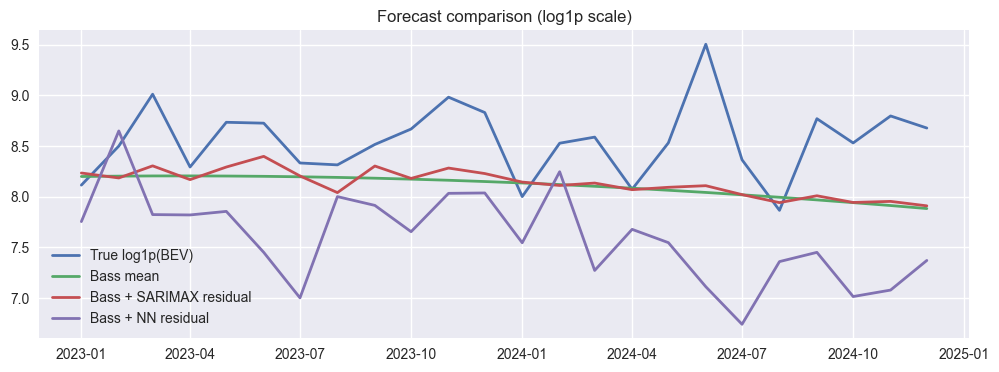

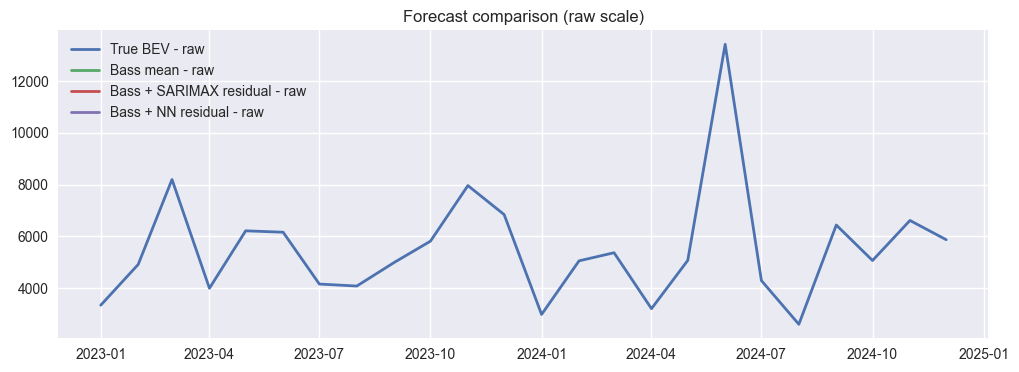

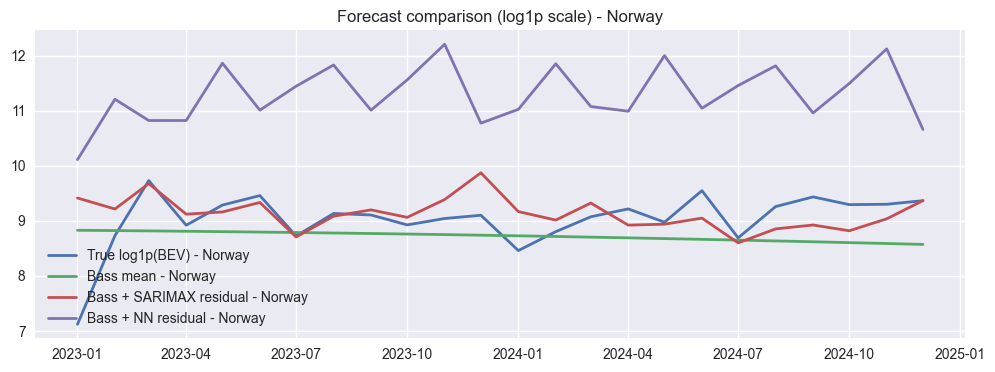

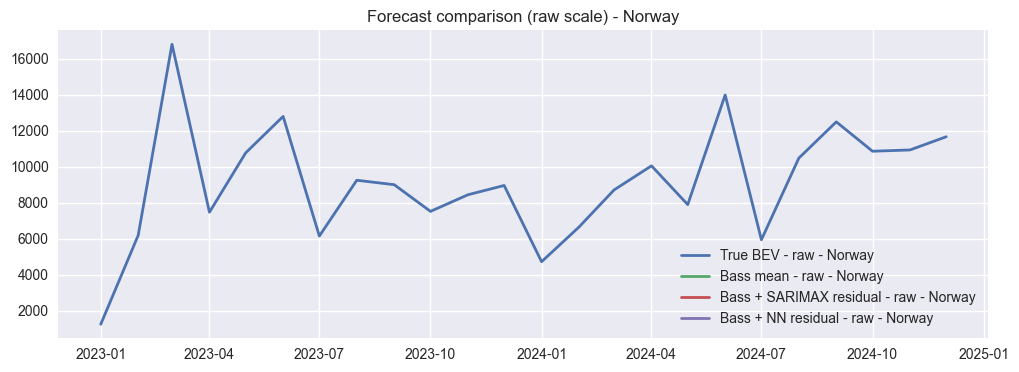

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="True log1p(BEV)", linewidth=2)
plt.plot(test.index, y_bass, label="Bass mean", linewidth=2)
plt.plot(test.index, y_sar, label="Bass + SARIMAX residual", linewidth=2)
plt.plot(test.index, y_nn, label="Bass + NN residual", linewidth=2)
plt.title("Forecast comparison (log1p scale)")
plt.legend()
plt.show()

# RAW
plt.figure(figsize=(12,4))
plt.plot(test_raw.index, test_raw.values, label="True BEV - raw", linewidth=2)
plt.plot(test_raw.index, np.expm1(y_bass_raw), label="Bass mean - raw", linewidth=2)
plt.plot(test_raw.index, np.expm1(y_sar_raw), label="Bass + SARIMAX residual - raw", linewidth=2)
plt.plot(test_raw.index, np.expm1(y_nn_raw), label="Bass + NN residual - raw", linewidth=2)
plt.title("Forecast comparison (raw scale)")
plt.legend()
plt.show()

# Norway
plt.figure(figsize=(12,4))
plt.plot(test_2.index, test_2.values, label="True log1p(BEV) - Norway", linewidth=2)
plt.plot(test_2.index, y_bass_2, label="Bass mean - Norway", linewidth=2)
plt.plot(test_2.index, y_sar_2, label="Bass + SARIMAX residual - Norway", linewidth=2)
plt.plot(test_2.index, y_nn_2, label="Bass + NN residual - Norway", linewidth=2)
plt.title("Forecast comparison (log1p scale) - Norway")
plt.legend()
plt.show()

# RAW Norway
plt.figure(figsize=(12,4))
plt.plot(test_raw_2.index, test_raw_2.values, label="True BEV - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, np.expm1(y_bass_raw_2), label="Bass mean - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, np.expm1(y_sar_raw_2), label="Bass + SARIMAX residual - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, np.expm1(y_nn_raw_2), label="Bass + NN residual - raw - Norway", linewidth=2)
plt.title("Forecast comparison (raw scale) - Norway")
plt.legend()
plt.show()

### Logistic

In [46]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

def logistic_cum(t, K, r, t0):
    # C(t) = K / (1 + exp(-r (t - t0)))
    return K / (1.0 + np.exp(-r * (t - t0)))

def fit_logistic_on_cumulative(ts_flow: pd.Series, train_end: str):
    ts_flow = ts_flow.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_flow[ts_flow.index <= train_end]

    # cumulative adoption
    C = train.cumsum().values.astype(float)
    t = np.arange(len(C), dtype=float)

    # initial guesses
    K0 = C.max() * 1.5
    r0 = 0.05
    t00 = len(C) / 2

    popt, pcov = curve_fit(
        logistic_cum, t, C,
        p0=[K0, r0, t00],
        bounds=([C.max()*1.01, 1e-5, 0], [C.max()*1000 + 1e9, 5.0, len(C)*5]),
        maxfev=20000
    )
    K, r, t0 = popt
    return {"K": float(K), "r": float(r), "t0": float(t0)}


In [47]:
def logistic_mean_log1p_flow(ts_flow: pd.Series, params: dict, train_end: str, horizon: int):
    """
    Returns:
      yhat_train: fitted log1p(flow) on train index
      yhat_fore:  forecast log1p(flow) for horizon months after train_end
    """
    ts_flow = ts_flow.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_flow[ts_flow.index <= train_end]
    T_train = len(train)

    # time indexes for cumulative curve
    t_train = np.arange(T_train, dtype=float)
    t_fore  = np.arange(T_train, T_train + horizon, dtype=float)

    # cumulative predictions
    C_hat_train = logistic_cum(t_train, params["K"], params["r"], params["t0"])
    C_hat_fore  = logistic_cum(t_fore,  params["K"], params["r"], params["t0"])

    # convert to flows: s_t = C_t - C_{t-1}
    s_hat_train = np.diff(np.concatenate([[0.0], C_hat_train]))
    s_hat_fore  = np.diff(np.concatenate([[C_hat_train[-1]], C_hat_fore]))

    # avoid negatives due to numeric issues
    s_hat_train = np.maximum(s_hat_train, 1e-12)
    s_hat_fore  = np.maximum(s_hat_fore, 1e-12)

    yhat_train = pd.Series(np.log1p(s_hat_train), index=train.index)

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx_fore = pd.date_range(start=start, periods=horizon, freq="MS")
    yhat_fore = pd.Series(np.log1p(s_hat_fore), index=idx_fore)

    return yhat_train, yhat_fore

def logistic_mean_raw_flow(ts_flow: pd.Series, params: dict, train_end: str, horizon: int):
    """
    Returns:
      yhat_train: fitted FLOW (raw) on train index
      yhat_fore:  forecast FLOW (raw) for horizon months after train_end
    """
    ts_flow = ts_flow.dropna()
    train_end = pd.to_datetime(train_end)
    train = ts_flow[ts_flow.index <= train_end]
    T_train = len(train)

    # time indexes for cumulative curve
    t_train = np.arange(T_train, dtype=float)
    t_fore  = np.arange(T_train, T_train + horizon, dtype=float)

    # cumulative predictions
    C_hat_train = logistic_cum(t_train, params["K"], params["r"], params["t0"])
    C_hat_fore  = logistic_cum(t_fore,  params["K"], params["r"], params["t0"])

    # convert to flows: s_t = C_t - C_{t-1}
    s_hat_train = np.diff(np.concatenate([[0.0], C_hat_train]))
    s_hat_fore  = np.diff(np.concatenate([[C_hat_train[-1]], C_hat_fore]))

    # avoid negatives due to numeric issues
    s_hat_train = np.maximum(s_hat_train, 1e-12)
    s_hat_fore  = np.maximum(s_hat_fore, 1e-12)

    # RETURN RAW FLOWS (no log)
    yhat_train = pd.Series(s_hat_train, index=train.index)

    start = (train.index.max() + pd.DateOffset(months=1)).to_period("M").to_timestamp()
    idx_fore = pd.date_range(start=start, periods=horizon, freq="MS")
    yhat_fore = pd.Series(s_hat_fore, index=idx_fore)

    return yhat_train, yhat_fore



In [48]:
TRAIN_END = "2022-12-01"
H = 24

# Fit logistic mean
log_params = fit_logistic_on_cumulative(ts, train_end=TRAIN_END)
print("Logistic params:", log_params)

yhat_train_log, yhat_fore_log = logistic_mean_log1p_flow(ts, log_params, train_end=TRAIN_END, horizon=H)

# Residuals on training window (log scale)
ts_log = np.log1p(ts).dropna()
resid_train_log = (ts_log.loc[yhat_train_log.index] - yhat_train_log).dropna()

# True test
test = ts_log[ts_log.index > pd.to_datetime(TRAIN_END)].iloc[:H]

# --- SARIMAX residual baseline ---
from statsmodels.tsa.statespace.sarimax import SARIMAX

sar_model = SARIMAX(
    resid_train_log,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

resid_fore_sar = sar_model.get_forecast(steps=H).predicted_mean
resid_fore_sar.index = yhat_fore_log.index
y_fore_log_sar = yhat_fore_log + resid_fore_sar

# --- TCN residual (use your existing train_tcn / forecast_tcn) ---
tcn_model = train_tcn(resid_train_log, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn = forecast_tcn(tcn_model, resid_train_log, start_date=yhat_fore_log.index[0], horizon=H, lookback=36)
y_fore_log_tcn = yhat_fore_log + resid_fore_tcn

# RAW

# Fit logistic mean
log_params_raw = fit_logistic_on_cumulative(ts, train_end=TRAIN_END)
print("Logistic params (raw):", log_params_raw)
yhat_train_raw, yhat_fore_raw = logistic_mean_raw_flow(ts, log_params_raw, train_end=TRAIN_END, horizon=H)
# Actual series
ts_raw = ts.dropna()
# Align true test window
test_raw = ts_raw[ts_raw.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Residuals on training window: e_t = y_t - yhat_t
resid_train_raw = (ts_raw.loc[yhat_train_raw.index] - yhat_train_raw).dropna()
# --- SARIMAX residual baseline ---
sar_model_raw = SARIMAX(
    resid_train_raw,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
resid_fore_sar_raw = sar_model_raw.get_forecast(steps=H).predicted_mean
resid_fore_sar_raw.index = yhat_fore_raw.index
y_fore_raw_sar = yhat_fore_raw + resid_fore_sar_raw
# --- TCN residual (use your existing train_tcn / forecast_tcn) ---
tcn_model_raw = train_tcn(resid_train_raw, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn_raw = forecast_tcn(tcn_model_raw, resid_train_raw, start_date=yhat_fore_raw.index[0], horizon=H, lookback=36)
y_fore_raw_tcn = yhat_fore_raw + resid_fore_tcn_raw


## Norway
# Fit logistic mean
log_params_2 = fit_logistic_on_cumulative(ts_2, train_end=TRAIN_END)
print("Logistic params Norway:", log_params_2)
yhat_train_log_2, yhat_fore_log_2 = logistic_mean_log1p_flow(ts_2, log_params_2, train_end=TRAIN_END, horizon=H)
# Residuals on training window (log scale)
ts_log_2 = np.log1p(ts_2).dropna()
resid_train_log_2 = (ts_log_2.loc[yhat_train_log_2.index] - yhat_train_log_2).dropna()
# True test
test_2 = ts_log_2[ts_log_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# --- SARIMAX residual baseline ---
sar_model_2 = SARIMAX(
    resid_train_log_2,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
resid_fore_sar_2 = sar_model_2.get_forecast(steps=H).predicted_mean
resid_fore_sar_2.index = yhat_fore_log_2.index
y_fore_log_sar_2 = yhat_fore_log_2 + resid_fore_sar_2
# --- TCN residual (use your existing train_tcn / forecast_tcn) ---
tcn_model_2 = train_tcn(resid_train_log_2, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn_2 = forecast_tcn(tcn_model_2, resid_train_log_2, start_date=yhat_fore_log_2.index[0], horizon=H, lookback=36)
y_fore_log_tcn_2 = yhat_fore_log_2 + resid_fore_tcn_2

# RAW Norway
# Fit logistic mean
log_params_raw_2 = fit_logistic_on_cumulative(ts_2, train_end=TRAIN_END)
print("Logistic params Norway (raw):", log_params_raw_2)
yhat_train_raw_2, yhat_fore_raw_2 = logistic_mean_raw_flow(ts_2, log_params_raw_2, train_end=TRAIN_END, horizon=H)
# Actual series
ts_raw_2 = ts_2.dropna()
# Align true test window
test_raw_2 = ts_raw_2[ts_raw_2.index > pd.to_datetime(TRAIN_END)].iloc[:H]
# Residuals on training window: e_t = y_t - yhat_t
resid_train_raw_2 = (ts_raw_2.loc[yhat_train_raw_2.index] - yhat_train_raw_2).dropna()
# --- SARIMAX residual baseline ---
sar_model_raw_2 = SARIMAX(
    resid_train_raw_2,
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
resid_fore_sar_raw_2 = sar_model_raw_2.get_forecast(steps=H).predicted_mean
resid_fore_sar_raw_2.index = yhat_fore_raw_2.index
y_fore_raw_sar_2 = yhat_fore_raw_2 + resid_fore_sar_raw_2
# --- TCN residual (use your existing train_tcn / forecast_tcn) ---
tcn_model_raw_2 = train_tcn(resid_train_raw_2, lookback=36, epochs=600, batch_size=16, lr=1e-3)
resid_fore_tcn_raw_2 = forecast_tcn(tcn_model_raw_2, resid_train_raw_2, start_date=yhat_fore_raw_2.index[0], horizon=H, lookback=36)
y_fore_raw_tcn_2 = yhat_fore_raw_2 + resid_fore_tcn_raw_2





Logistic params: {'K': 226101.73350211405, 'r': 0.09507430589672816, 't0': 94.79174899967526}
Epoch 100/600 loss=0.034122
Epoch 200/600 loss=0.011552
Epoch 300/600 loss=0.009790
Epoch 400/600 loss=0.003825
Epoch 500/600 loss=0.004419
Epoch 600/600 loss=0.005448
Logistic params (raw): {'K': 226101.73350211405, 'r': 0.09507430589672816, 't0': 94.79174899967526}
Epoch 100/600 loss=95765.066406
Epoch 200/600 loss=46574.281250
Epoch 300/600 loss=59950.082031
Epoch 400/600 loss=49949.267090
Epoch 500/600 loss=24106.373047
Epoch 600/600 loss=12624.193359
Logistic params Norway: {'K': 1256958.1518512147, 'r': 0.03535186114564394, 't0': 117.6450634085733}
Epoch 100/600 loss=0.020261
Epoch 200/600 loss=0.006858
Epoch 300/600 loss=0.005429
Epoch 400/600 loss=0.003067
Epoch 500/600 loss=0.002224
Epoch 600/600 loss=0.003638
Logistic params Norway (raw): {'K': 1256958.1518512147, 'r': 0.03535186114564394, 't0': 117.6450634085733}
Epoch 100/600 loss=540627.710938
Epoch 200/600 loss=547909.273438
Epoc

In [49]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def eval_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
    }

# Align all forecasts to test index
y_true = test.values
y_bass = yhat_fore.loc[test.index].values
y_sar  = y_fore_sarimax.loc[test.index].values
y_nn   = y_fore_nn.loc[test.index].values
y_tcn = y_fore_tcn.loc[test.index].values
y_log_sar = y_fore_log_sar.loc[test.index].values
y_log_tcn = y_fore_log_tcn.loc[test.index].values


results = pd.DataFrame([
    eval_metrics(y_true, y_bass, "Bass mean only"),
    eval_metrics(y_true, y_sar,  "Bass + SARIMAX residual"),
    eval_metrics(y_true, y_nn,   "Bass + NN residual (LSTM)"),
    eval_metrics(y_true, y_tcn,  "Bass + NN residual (TCN)"),
    eval_metrics(y_true, y_log_sar, "Log + SARIMAX residual"),
    eval_metrics(y_true, y_log_tcn, "Log + TCN residual")  
])
print(results)

# RAW
# Align all forecasts to test index
y_true_raw = test_raw.values
y_bass_raw = yhat_fore_raw.loc[test_raw.index].values
y_sar_raw  = y_fore_sarimax_raw.loc[test_raw.index].values
y_nn_raw   = y_fore_nn_raw.loc[test_raw.index].values
y_tcn_raw = y_fore_tcn_raw.loc[test_raw.index].values
y_log_sar_raw = y_fore_raw_sar.loc[test_raw.index].values
y_log_tcn_raw = y_fore_raw_tcn.loc[test_raw.index].values

results_raw = pd.DataFrame([
    eval_metrics(y_true_raw, y_bass_raw, "Bass mean only - raw"),
    eval_metrics(y_true_raw, y_sar_raw,  "Bass + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_nn_raw,   "Bass + NN residual (LSTM) - raw"),
    eval_metrics(y_true_raw, y_tcn_raw,  "Bass + NN residual (TCN) - raw"),
    eval_metrics(y_true_raw, y_log_sar_raw, "Log + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_log_tcn_raw, "Log + TCN residual - raw")   
])
print(results_raw)

#Norway
# Align all forecasts to test index
y_true_2 = test_2.values
y_bass_2 = yhat_fore_2.loc[test_2.index].values
y_sar_2  = y_fore_sarimax_2.loc[test_2.index].values
y_nn_2   = y_fore_nn_2.loc[test_2.index].values
y_tcn_2 = y_fore_tcn_2.loc[test_2.index].values
y_log_sar_2 = y_fore_log_sar_2.loc[test_2.index].values
y_log_tcn_2 = y_fore_log_tcn_2.loc[test_2.index].values

results_2 = pd.DataFrame([
    eval_metrics(y_true_2, y_bass_2, "Bass mean only - Norway"),
    eval_metrics(y_true_2, y_sar_2,  "Bass + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_nn_2,   "Bass + NN residual (LSTM) - Norway"),
    eval_metrics(y_true_2, y_tcn_2,  "Bass + NN residual (TCN) - Norway"),
    eval_metrics(y_true_2, y_log_sar_2, "Log + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_log_tcn_2, "Log + TCN residual - Norway")  
])
print(results_2)

# RAW Norway
y_true_raw_2 = test_raw_2.values
y_bass_raw_2 = yhat_fore_raw_2.loc[test_raw_2.index].values
y_sar_raw_2  = y_fore_sarimax_raw_2.loc[test_raw_2.index].values
y_nn_raw_2   = y_fore_nn_raw_2.loc[test_raw_2.index].values
y_tcn_raw_2 = y_fore_tcn_raw_2.loc[test_raw_2.index].values
y_log_sar_raw_2 = y_fore_raw_sar_2.loc[test_raw_2.index].values
y_log_tcn_raw_2 = y_fore_raw_tcn_2.loc[test_raw_2.index].values

results_raw_2 = pd.DataFrame([
    eval_metrics(y_true_raw_2, y_bass_raw_2, "Bass mean only - raw - Norway"),
    eval_metrics(y_true_raw_2, y_sar_raw_2,  "Bass + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_nn_raw_2,   "Bass + NN residual (LSTM) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_raw_2,  "Bass + NN residual (TCN) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_log_sar_raw_2, "Log + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_log_tcn_raw_2, "Log + TCN residual - raw - Norway")   
])
print(results_raw_2)


                       Model       MAE      RMSE      sMAPE
0             Bass mean only  0.476213  0.582629   5.650965
1    Bass + SARIMAX residual  0.444475  0.541680   5.264228
2  Bass + NN residual (LSTM)  0.963985  1.107149  11.990343
3   Bass + NN residual (TCN)  0.594536  0.678964   7.168918
4     Log + SARIMAX residual  1.150991  1.301928  14.546257
5         Log + TCN residual  1.233769  1.356161  15.735673
                             Model          MAE         RMSE       sMAPE
0             Bass mean only - raw  3610.388442  4350.138761   94.115508
1    Bass + SARIMAX residual - raw  2596.011199  3408.785932   56.179752
2  Bass + NN residual (LSTM) - raw  2319.133245  3278.276155   47.599459
3   Bass + NN residual (TCN) - raw  2253.225073  2988.777864   47.336763
4     Log + SARIMAX residual - raw  3758.420016  4384.391212  101.404294
5         Log + TCN residual - raw  3701.664389  4237.420695  108.772151
                                Model       MAE      RMSE      sMAPE


### Multi-horizon TCN

In [50]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def month_sin_cos(month):
    msin = np.sin(2*np.pi*month/12.0)
    mcos = np.cos(2*np.pi*month/12.0)
    return msin, mcos

class ResidualMultiHorizonDataset(Dataset):
    """
    Input: residual window of length L (past)
    Output: next H residuals (direct multi-step)
    Features: month sin/cos for each horizon step (H x 2)
    """
    def __init__(self, resid: pd.Series, lookback=36, horizon=24):
        resid = resid.dropna()
        self.lookback = lookback
        self.horizon = horizon

        r = resid.values.astype(np.float32)
        idx = resid.index

        X = []
        F = []
        Y = []

        for t in range(lookback, len(r) - horizon):
            window = r[t-lookback:t]  # (L,)
            future = r[t:t+horizon]   # (H,)

            # month features for each future step
            future_dates = idx[t:t+horizon]
            feats = []
            for d in future_dates:
                ms, mc = month_sin_cos(d.month)
                feats.append([ms, mc])
            feats = np.array(feats, dtype=np.float32)  # (H,2)

            X.append(window)
            F.append(feats)
            Y.append(future)

        self.X = torch.tensor(np.stack(X), dtype=torch.float32)            # (N,L)
        self.F = torch.tensor(np.stack(F), dtype=torch.float32)            # (N,H,2)
        self.Y = torch.tensor(np.stack(Y), dtype=torch.float32)            # (N,H)

    def __len__(self): return self.Y.shape[0]
    def __getitem__(self, i):
        return self.X[i].unsqueeze(-1), self.F[i], self.Y[i]  # (L,1), (H,2), (H,)

class MultiHorizonTCN(nn.Module):
    """
    TCN encodes past residual window -> context vector.
    Then a small head maps (context + future month features) -> H residuals.
    """
    def __init__(self, hidden=32, levels=4, kernel=3, dropout=0.15, horizon=24):
        super().__init__()
        self.horizon = horizon

        def causal_block(in_ch, out_ch, dilation):
            pad = (kernel - 1) * dilation
            return nn.Sequential(
                nn.ConstantPad1d((pad, 0), 0.0),
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel, dilation=dilation),
                nn.ReLU(),
                nn.Dropout(dropout),
            )

        layers = []
        in_ch = 1
        for i in range(levels):
            layers.append(causal_block(in_ch, hidden, dilation=2**i))
            in_ch = hidden
        self.tcn = nn.Sequential(*layers)

        # map context + (H,2) month features to (H,) outputs
        self.head = nn.Sequential(
            nn.Linear(hidden + 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_window, future_feats):
        # x_window: (B,L,1) -> conv expects (B,1,L)
        x = x_window.permute(0, 2, 1)             # (B,1,L)
        h = self.tcn(x)                           # (B,hidden,L)
        context = h[:, :, -1]                     # (B,hidden)

        # future_feats: (B,H,2)
        B, H, _ = future_feats.shape
        context_rep = context.unsqueeze(1).expand(B, H, context.shape[1])  # (B,H,hidden)
        z = torch.cat([context_rep, future_feats], dim=-1)                 # (B,H,hidden+2)

        out = self.head(z).squeeze(-1)                                     # (B,H)
        return out

def train_multi_tcn(resid_train: pd.Series, lookback=36, horizon=24, epochs=800, batch_size=16, lr=1e-3):
    ds = ResidualMultiHorizonDataset(resid_train, lookback=lookback, horizon=horizon)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = MultiHorizonTCN(hidden=32, levels=4, kernel=3, dropout=0.15, horizon=horizon).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    for ep in range(epochs):
        model.train()
        total = 0.0
        for xw, ff, yy in dl:
            xw = xw.to(DEVICE)
            ff = ff.to(DEVICE)
            yy = yy.to(DEVICE)

            pred = model(xw, ff)
            loss = loss_fn(pred, yy)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item())

        if (ep+1) % 200 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")

    return model

@torch.no_grad()
def forecast_multi_tcn(model, resid_train: pd.Series, start_date, horizon=24, lookback=36):
    model.eval()
    history = resid_train.values.astype(np.float32)
    xw = torch.tensor(history[-lookback:], dtype=torch.float32).view(1, lookback, 1).to(DEVICE)

    idx = pd.date_range(start=pd.to_datetime(start_date), periods=horizon, freq="MS")
    feats = []
    for d in idx:
        ms, mc = month_sin_cos(d.month)
        feats.append([ms, mc])
    feats = torch.tensor(np.array(feats, dtype=np.float32)).unsqueeze(0).to(DEVICE)  # (1,H,2)

    pred = model(xw, feats).cpu().numpy().flatten()
    return pd.Series(pred, index=idx)


In [51]:
torch.manual_seed(42)
np.random.seed(42)

H = 24
LOOKBACK = 36

tcn_mh = train_multi_tcn(resid_train, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh = forecast_multi_tcn(tcn_mh, resid_train, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)

y_fore_bass_tcn_mh = yhat_fore + resid_fore_mh

# RAW
tcn_mh_raw = train_multi_tcn(resid_train_raw, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh_raw = forecast_multi_tcn(tcn_mh_raw, resid_train_raw, start_date=start_fore_date_raw, horizon=H, lookback=LOOKBACK)
y_fore_bass_tcn_mh_raw = yhat_fore_raw + resid_fore_mh_raw

## Norway
tcn_mh_2 = train_multi_tcn(resid_train_2, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh_2 = forecast_multi_tcn(tcn_mh_2, resid_train_2, start_date=start_fore_date_2, horizon=H, lookback=LOOKBACK)
y_fore_bass_tcn_mh_2 = yhat_fore_2 + resid_fore_mh_2

# RAW Norway
tcn_mh_raw_2 = train_multi_tcn(resid_train_raw_2, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
start_fore_date_raw_2 = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh_raw_2 = forecast_multi_tcn(tcn_mh_raw_2, resid_train_raw_2, start_date=start_fore_date_raw_2, horizon=H, lookback=LOOKBACK)
y_fore_bass_tcn_mh_raw_2 = yhat_fore_raw_2 + resid_fore_mh_raw_2


Epoch 200/800 loss=0.166215
Epoch 400/800 loss=0.148071
Epoch 600/800 loss=0.142566
Epoch 800/800 loss=0.140215
Epoch 200/800 loss=1204047.333333
Epoch 400/800 loss=1200521.916667
Epoch 600/800 loss=1190333.375000
Epoch 800/800 loss=1175542.125000
Epoch 200/800 loss=0.051516
Epoch 400/800 loss=0.044714
Epoch 600/800 loss=0.043935
Epoch 800/800 loss=0.043413
Epoch 200/800 loss=4863554.833333
Epoch 400/800 loss=4859717.833333
Epoch 600/800 loss=4850828.833333
Epoch 800/800 loss=4833388.083333


In [52]:
# ---------------------------
# Reproducibility
# ---------------------------
torch.manual_seed(42)
np.random.seed(42)

# ---------------------------
# Hyperparams
# ---------------------------
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

# ============================================================
# A) Build DynamicBass mean + residual series (Italy/Norway, log/raw)
# ============================================================

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()

# ---------- ITALY: Dynamic mean forecasts ----------
dyn_fit_it = fit_dynamic_bass_logisticM(ts, train_end=TRAIN_END)
dyn_mean_it_raw = forecast_dynamic_bass_logisticM(ts, dyn_fit_it, train_end=TRAIN_END, horizon=H)
dyn_train_it_raw = dyn_fit_it["yhat_train"]

ts_it_raw = ts.dropna().astype(float)
test_it_raw = ts_it_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_train_it_raw.index] - dyn_train_it_raw).dropna()

ts_it_log = np.log1p(ts_it_raw)
dyn_train_it_log = np.log1p(np.clip(dyn_train_it_raw, 0, None))
dyn_mean_it_log  = np.log1p(np.clip(dyn_mean_it_raw, 0, None))
test_it_log = ts_it_log.loc[test_it_raw.index]
resid_train_dyn_it_log = (ts_it_log.loc[dyn_train_it_log.index] - dyn_train_it_log).dropna()

# ---------- NORWAY: Dynamic mean forecasts ----------
dyn_fit_no = fit_dynamic_bass_logisticM(ts_2, train_end=TRAIN_END)
dyn_mean_no_raw = forecast_dynamic_bass_logisticM(ts_2, dyn_fit_no, train_end=TRAIN_END, horizon=H)
dyn_train_no_raw = dyn_fit_no["yhat_train"]

ts_no_raw = ts_2.dropna().astype(float)
test_no_raw = ts_no_raw.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_train_no_raw.index] - dyn_train_no_raw).dropna()

ts_no_log = np.log1p(ts_no_raw)
dyn_train_no_log = np.log1p(np.clip(dyn_train_no_raw, 0, None))
dyn_mean_no_log  = np.log1p(np.clip(dyn_mean_no_raw, 0, None))
test_no_log = ts_no_log.loc[test_no_raw.index]
resid_train_dyn_no_log = (ts_no_log.loc[dyn_train_no_log.index] - dyn_train_no_log).dropna()

# ============================================================
# B) Train Multi-horizon TCN on Dynamic residuals + forecast residuals
# ============================================================

# --- Italy LOG ---
tcn_mh_dyn_it_log = train_multi_tcn(
    resid_train_dyn_it_log,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()

resid_fore_dyn_it_log = forecast_multi_tcn(
    tcn_mh_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

# ✅ align safely (do NOT overwrite index)
resid_fore_dyn_it_log = resid_fore_dyn_it_log.reindex(dyn_yhat_fore_it_log.index)

# optional sanity check
assert resid_fore_dyn_it_log.isna().sum() == 0, "Index mismatch: residual forecast not aligned to dyn mean index"

y_fore_dyn_it_log_tcn_mh = dyn_yhat_fore_it_log + resid_fore_dyn_it_log
print("Done: Italy DynamicBass + Multi-horizon TCN residual (LOG)")

# --- Italy RAW ---
tcn_mh_dyn_it_raw = train_multi_tcn(
    resid_train_dyn_it_raw,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

resid_fore_dyn_it_raw = forecast_multi_tcn(
    tcn_mh_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

resid_fore_dyn_it_raw = resid_fore_dyn_it_raw.reindex(dyn_yhat_fore_it_raw.index)

assert resid_fore_dyn_it_raw.isna().sum() == 0, "Index mismatch: residual forecast not aligned to dyn mean index"

y_fore_dyn_it_raw_tcn_mh = dyn_yhat_fore_it_raw + resid_fore_dyn_it_raw
print("Done: Italy DynamicBass + Multi-horizon TCN residual (RAW)")

# --- Norway LOG ---
tcn_mh_dyn_no_log = train_multi_tcn(resid_train_dyn_no_log, lookback=LOOKBACK, horizon=H, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_log = forecast_multi_tcn(tcn_mh_dyn_no_log, resid_train_dyn_no_log, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)
resid_fore_dyn_no_log.index = dyn_mean_no_log.index
y_fore_dyn_no_log_tcn_mh = dyn_mean_no_log + resid_fore_dyn_no_log
print("Done: Norway DynamicBass + Multi-horizon TCN residual (LOG)")

# --- Norway RAW ---
tcn_mh_dyn_no_raw = train_multi_tcn(resid_train_dyn_no_raw, lookback=LOOKBACK, horizon=H, epochs=EPOCHS, batch_size=BATCH, lr=LR)
resid_fore_dyn_no_raw = forecast_multi_tcn(tcn_mh_dyn_no_raw, resid_train_dyn_no_raw, start_date=start_fore_date, horizon=H, lookback=LOOKBACK)
resid_fore_dyn_no_raw.index = dyn_mean_no_raw.index
y_fore_dyn_no_raw_tcn_mh = dyn_mean_no_raw + resid_fore_dyn_no_raw
print("Done: Norway DynamicBass + Multi-horizon TCN residual (RAW)")

Epoch 200/800 loss=0.155761
Epoch 400/800 loss=0.132106
Epoch 600/800 loss=0.126908
Epoch 800/800 loss=0.123979
Done: Italy DynamicBass + Multi-horizon TCN residual (LOG)
Epoch 200/800 loss=1342624.333333
Epoch 400/800 loss=1339912.916667
Epoch 600/800 loss=1335661.375000
Epoch 800/800 loss=1333748.083333
Done: Italy DynamicBass + Multi-horizon TCN residual (RAW)
Epoch 200/800 loss=0.048323
Epoch 400/800 loss=0.041364
Epoch 600/800 loss=0.039996
Epoch 800/800 loss=0.039903
Done: Norway DynamicBass + Multi-horizon TCN residual (LOG)
Epoch 200/800 loss=4863060.500000
Epoch 400/800 loss=4860882.000000
Epoch 600/800 loss=4851337.000000
Epoch 800/800 loss=4836740.000000
Done: Norway DynamicBass + Multi-horizon TCN residual (RAW)


In [53]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def eval_metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
    }

# Align all forecasts to test index
y_true = test.values
y_bass = yhat_fore.loc[test.index].values
y_sar  = y_fore_sarimax.loc[test.index].values
y_nn   = y_fore_nn.loc[test.index].values
y_tcn = y_fore_tcn.loc[test.index].values
y_tcn_mh = y_fore_bass_tcn_mh.loc[test.index].values

results = pd.DataFrame([
    eval_metrics(y_true, y_bass, "Bass mean only"),
    eval_metrics(y_true, y_sar,  "Bass + SARIMAX residual"),
    eval_metrics(y_true, y_nn,   "Bass + NN residual (LSTM)"),
    eval_metrics(y_true, y_tcn,  "Bass + NN residual (TCN)"),
    eval_metrics(y_true, y_tcn_mh,  "Bass + Multi-horizon TCN residual")
])
print(results)

# RAW
# Align all forecasts to test index
y_true_raw = test_raw.values
y_bass_raw = yhat_fore_raw.loc[test_raw.index].values
y_sar_raw  = y_fore_sarimax_raw.loc[test_raw.index].values
y_nn_raw   = y_fore_nn_raw.loc[test_raw.index].values
y_tcn_raw = y_fore_tcn_raw.loc[test_raw.index].values
y_tcn_mh_raw = y_fore_bass_tcn_mh_raw.loc[test_raw.index].values

results_raw = pd.DataFrame([
    eval_metrics(y_true_raw, y_bass_raw, "Bass mean only - raw"),
    eval_metrics(y_true_raw, y_sar_raw,  "Bass + SARIMAX residual - raw"),
    eval_metrics(y_true_raw, y_nn_raw,   "Bass + NN residual (LSTM) - raw"),
    eval_metrics(y_true_raw, y_tcn_raw,  "Bass + NN residual (TCN) - raw"),
    eval_metrics(y_true_raw, y_tcn_mh_raw,  "Bass + Multi-horizon TCN residual - raw")
])
print(results_raw)

## Norway

# Align all forecasts to test index
y_true_2 = test_2.values
y_bass_2 = yhat_fore_2.loc[test_2.index].values
y_sar_2  = y_fore_sarimax_2.loc[test_2.index].values
y_nn_2   = y_fore_nn_2.loc[test_2.index].values
y_tcn_2 = y_fore_tcn_2.loc[test_2.index].values
y_tcn_mh_2 = y_fore_bass_tcn_mh_2.loc[test_2.index].values

results_2 = pd.DataFrame([
    eval_metrics(y_true_2, y_bass_2, "Bass mean only - Norway"),
    eval_metrics(y_true_2, y_sar_2,  "Bass + SARIMAX residual - Norway"),
    eval_metrics(y_true_2, y_nn_2,   "Bass + NN residual (LSTM) - Norway"),
    eval_metrics(y_true_2, y_tcn_2,  "Bass + NN residual (TCN) - Norway"),
    eval_metrics(y_true_2, y_tcn_mh_2,  "Bass + Multi-horizon TCN residual - Norway")
])
print(results_2)

# RAW Norway
y_true_raw_2 = test_raw_2.values
y_bass_raw_2 = yhat_fore_raw_2.loc[test_raw_2.index].values
y_sar_raw_2  = y_fore_sarimax_raw_2.loc[test_raw_2.index].values
y_nn_raw_2   = y_fore_nn_raw_2.loc[test_raw_2.index].values
y_tcn_raw_2 = y_fore_tcn_raw_2.loc[test_raw_2.index].values
y_tcn_mh_raw_2 = y_fore_bass_tcn_mh_raw_2.loc[test_raw_2.index].values

results_raw_2 = pd.DataFrame([
    eval_metrics(y_true_raw_2, y_bass_raw_2, "Bass mean only - raw - Norway"),
    eval_metrics(y_true_raw_2, y_sar_raw_2,  "Bass + SARIMAX residual - raw - Norway"),
    eval_metrics(y_true_raw_2, y_nn_raw_2,   "Bass + NN residual (LSTM) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_raw_2,  "Bass + NN residual (TCN) - raw - Norway"),
    eval_metrics(y_true_raw_2, y_tcn_mh_raw_2,  "Bass + Multi-horizon TCN residual - raw - Norway")
])
print(results_raw_2)

                               Model       MAE      RMSE      sMAPE
0                     Bass mean only  0.476213  0.582629   5.650965
1            Bass + SARIMAX residual  0.444475  0.541680   5.264228
2          Bass + NN residual (LSTM)  0.963985  1.107149  11.990343
3           Bass + NN residual (TCN)  0.594536  0.678964   7.168918
4  Bass + Multi-horizon TCN residual  0.374711  0.444122   4.446271
                                     Model          MAE         RMSE  \
0                     Bass mean only - raw  3610.388442  4350.138761   
1            Bass + SARIMAX residual - raw  2596.011199  3408.785932   
2          Bass + NN residual (LSTM) - raw  2319.133245  3278.276155   
3           Bass + NN residual (TCN) - raw  2253.225073  2988.777864   
4  Bass + Multi-horizon TCN residual - raw  3075.892315  3877.886093   

       sMAPE  
0  94.115508  
1  56.179752  
2  47.599459  
3  47.336763  
4  72.332683  
                                        Model       MAE      RMSE    

In [54]:
print(results_raw_2)

                                              Model          MAE  \
0                     Bass mean only - raw - Norway  2985.619129   
1            Bass + SARIMAX residual - raw - Norway  5575.428818   
2          Bass + NN residual (LSTM) - raw - Norway  3092.345238   
3           Bass + NN residual (TCN) - raw - Norway  7579.554145   
4  Bass + Multi-horizon TCN residual - raw - Norway  2687.948518   

           RMSE      sMAPE  
0   3728.834858  33.583895  
1   8356.955757  43.833077  
2   3923.777003  37.391316  
3  11889.720027  52.845968  
4   3354.687834  31.247554  


In [55]:
# ============================================================
# 1) ITALY — DynamicBass (LOG)
# ============================================================
y_true = test.values

y_dyn_it_log = dyn_yhat_fore_it_log.loc[test.index].values
y_sar_it_log = y_fore_sarimax_dyn_it_log.loc[test.index].values
y_nn_it_log  = y_fore_dyn_it_log_nn.loc[test.index].values
y_tcn_it_log = y_fore_dyn_it_log_tcn.loc[test.index].values
y_tcn_mh_it_log = y_fore_dyn_it_log_tcn_mh.loc[test.index].values

results_dyn_it_log = pd.DataFrame([
    eval_metrics(y_true, y_dyn_it_log, "DynamicBass mean only (LOG)"),
    eval_metrics(y_true, y_sar_it_log, "DynamicBass + SARIMAX residual (LOG)"),
    eval_metrics(y_true, y_nn_it_log,  "DynamicBass + NN residual (LSTM) (LOG)"),
    eval_metrics(y_true, y_tcn_it_log, "DynamicBass + NN residual (TCN) (LOG)"),
    eval_metrics(y_true, y_tcn_mh_it_log, "DynamicBass + Multi-horizon TCN residual (LOG)")
])
print("\n=== ITALY — DynamicBass (LOG) ===")
print(results_dyn_it_log)

# ============================================================
# 2) ITALY — DynamicBass (RAW)
# ============================================================
y_true_it_raw = test_it_raw.values

y_dyn_it_raw = dyn_yhat_fore_it_raw.loc[test_it_raw.index].values
y_sar_it_raw = y_fore_sarimax_dyn_it_raw.loc[test_it_raw.index].values
y_nn_it_raw  = y_fore_dyn_it_raw_nn.loc[test_it_raw.index].values
y_tcn_it_raw = y_fore_dyn_it_raw_tcn.loc[test_it_raw.index].values
y_tcn_mh_it_raw = y_fore_dyn_it_raw_tcn_mh.loc[test_it_raw.index].values

results_dyn_it_raw = pd.DataFrame([
    eval_metrics(y_true_it_raw, y_dyn_it_raw, "DynamicBass mean only (RAW)"),
    eval_metrics(y_true_it_raw, y_sar_it_raw, "DynamicBass + SARIMAX residual (RAW)"),
    eval_metrics(y_true_it_raw, y_nn_it_raw,  "DynamicBass + NN residual (LSTM) (RAW)"),
    eval_metrics(y_true_it_raw, y_tcn_it_raw, "DynamicBass + NN residual (TCN) (RAW)"),
    eval_metrics(y_true_it_raw, y_tcn_mh_it_raw, "DynamicBass + Multi-horizon TCN residual (RAW)")
])
print("\n=== ITALY — DynamicBass (RAW) ===")
print(results_dyn_it_raw)

# ============================================================
# 3) NORWAY — DynamicBass (LOG)
# ============================================================
y_true_no_log = test_no_log.values

y_dyn_no_log = dyn_yhat_fore_no_log.loc[test_no_log.index].values
y_sar_no_log = y_fore_sarimax_dyn_no_log.loc[test_no_log.index].values
y_nn_no_log  = y_fore_dyn_no_log_nn.loc[test_no_log.index].values
y_tcn_no_log = y_fore_dyn_no_log_tcn.loc[test_no_log.index].values
y_tcn_mh_no_log = y_fore_dyn_no_log_tcn_mh.loc[test_no_log.index].values

results_dyn_no_log = pd.DataFrame([
    eval_metrics(y_true_no_log, y_dyn_no_log, "DynamicBass mean only (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_sar_no_log, "DynamicBass + SARIMAX residual (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_nn_no_log,  "DynamicBass + NN residual (LSTM) (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_tcn_no_log, "DynamicBass + NN residual (TCN) (LOG) - Norway"),
    eval_metrics(y_true_no_log, y_tcn_mh_no_log, "DynamicBass + Multi-horizon TCN residual (LOG) - Norway")
])
print("\n=== NORWAY — DynamicBass (LOG) ===")
print(results_dyn_no_log)

# ============================================================
# 4) NORWAY — DynamicBass (RAW)
# ============================================================
y_true_no_raw = test_no_raw.values

y_dyn_no_raw = dyn_yhat_fore_no_raw.loc[test_no_raw.index].values
y_sar_no_raw = y_fore_sarimax_dyn_no_raw.loc[test_no_raw.index].values
y_nn_no_raw  = y_fore_dyn_no_raw_nn.loc[test_no_raw.index].values
y_tcn_no_raw = y_fore_dyn_no_raw_tcn.loc[test_no_raw.index].values
y_tcn_mh_no_raw = y_fore_dyn_no_raw_tcn_mh.loc[test_no_raw.index].values

results_dyn_no_raw = pd.DataFrame([
    eval_metrics(y_true_no_raw, y_dyn_no_raw, "DynamicBass mean only (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_sar_no_raw, "DynamicBass + SARIMAX residual (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_nn_no_raw,  "DynamicBass + NN residual (LSTM) (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_tcn_no_raw, "DynamicBass + NN residual (TCN) (RAW) - Norway"),
    eval_metrics(y_true_no_raw, y_tcn_mh_no_raw, "DynamicBass + Multi-horizon TCN residual (RAW) - Norway")
])
print("\n=== NORWAY — DynamicBass (RAW) ===")
print(results_dyn_no_raw)

# ============================================================
# Optional: combine all results into one table
# ============================================================
all_results = pd.concat([
    results_dyn_it_log.assign(Country="Italy", Scale="log"),
    results_dyn_it_raw.assign(Country="Italy", Scale="raw"),
    results_dyn_no_log.assign(Country="Norway", Scale="log"),
    results_dyn_no_raw.assign(Country="Norway", Scale="raw"),
], ignore_index=True)

print("\n=== ALL DynamicBass results combined ===")
print(all_results)


=== ITALY — DynamicBass (LOG) ===
                                            Model       MAE      RMSE  \
0                     DynamicBass mean only (LOG)  0.909505  1.051563   
1            DynamicBass + SARIMAX residual (LOG)  0.923326  1.049884   
2          DynamicBass + NN residual (LSTM) (LOG)  1.541592  1.673526   
3           DynamicBass + NN residual (TCN) (LOG)  1.454751  1.570358   
4  DynamicBass + Multi-horizon TCN residual (LOG)  1.556303  1.655546   

       sMAPE  
0  11.254917  
1  11.432828  
2  19.963343  
3  18.770604  
4  20.184242  

=== ITALY — DynamicBass (RAW) ===
                                            Model          MAE         RMSE  \
0                     DynamicBass mean only (RAW)  3298.250139  4064.526390   
1            DynamicBass + SARIMAX residual (RAW)  3365.747481  4029.406196   
2          DynamicBass + NN residual (LSTM) (RAW)  3160.868459  4000.387150   
3           DynamicBass + NN residual (TCN) (RAW)  3375.494716  3805.085056   
4  Dyn

In [56]:
print(all_results)

                                                Model          MAE  \
0                         DynamicBass mean only (LOG)     0.909505   
1                DynamicBass + SARIMAX residual (LOG)     0.923326   
2              DynamicBass + NN residual (LSTM) (LOG)     1.541592   
3               DynamicBass + NN residual (TCN) (LOG)     1.454751   
4      DynamicBass + Multi-horizon TCN residual (LOG)     1.556303   
5                         DynamicBass mean only (RAW)  3298.250139   
6                DynamicBass + SARIMAX residual (RAW)  3365.747481   
7              DynamicBass + NN residual (LSTM) (RAW)  3160.868459   
8               DynamicBass + NN residual (TCN) (RAW)  3375.494716   
9      DynamicBass + Multi-horizon TCN residual (RAW)  9294.870155   
10               DynamicBass mean only (LOG) - Norway     0.410848   
11      DynamicBass + SARIMAX residual (LOG) - Norway     0.405099   
12    DynamicBass + NN residual (LSTM) (LOG) - Norway     0.669340   
13     DynamicBass +

In [57]:
print(results_dyn_no_raw)

                                               Model          MAE  \
0               DynamicBass mean only (RAW) - Norway  3511.058709   
1      DynamicBass + SARIMAX residual (RAW) - Norway  5160.459126   
2    DynamicBass + NN residual (LSTM) (RAW) - Norway  3885.035996   
3     DynamicBass + NN residual (TCN) (RAW) - Norway  3501.795003   
4  DynamicBass + Multi-horizon TCN residual (RAW)...  2901.506689   

          RMSE      sMAPE  
0  4296.591950  37.629507  
1  7895.197123  41.800674  
2  4613.674468  40.570871  
3  4572.436871  44.118840  
4  3571.004386  33.042687  


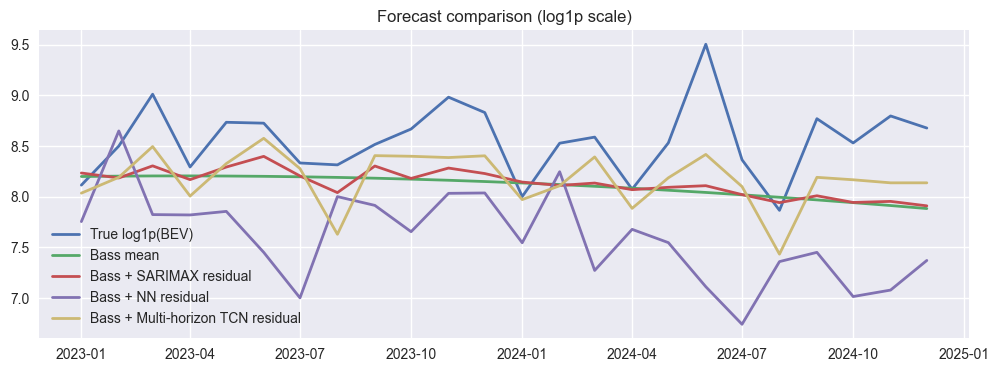

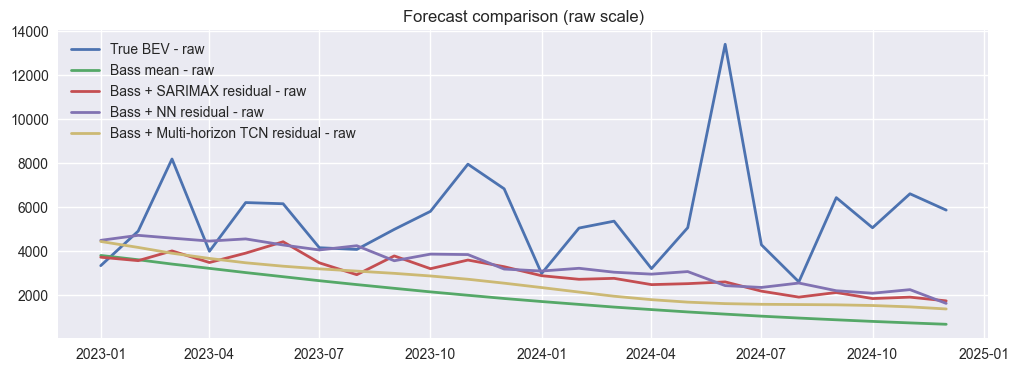

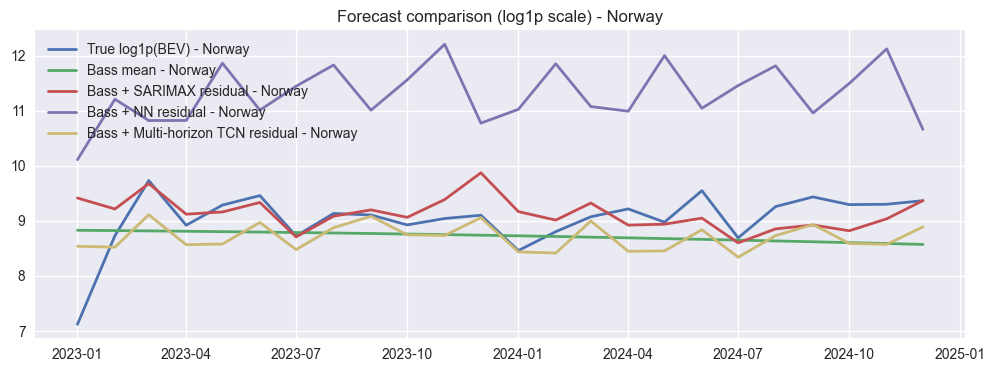

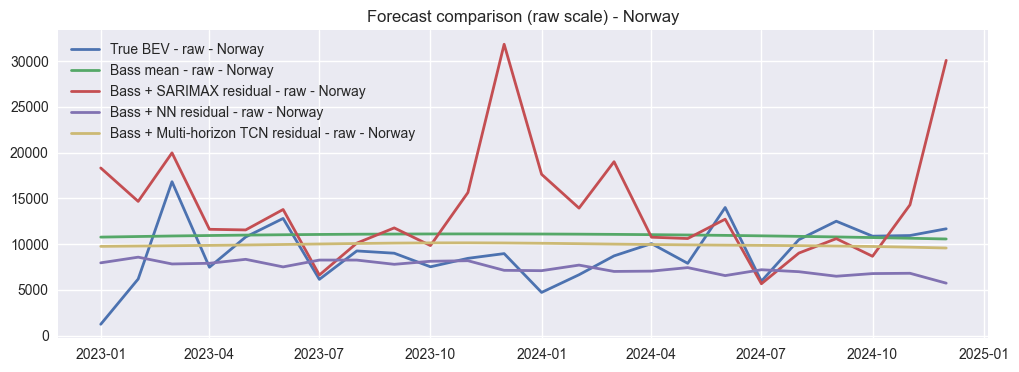

In [58]:

plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="True log1p(BEV)", linewidth=2)
plt.plot(test.index, y_bass, label="Bass mean", linewidth=2)
plt.plot(test.index, y_sar, label="Bass + SARIMAX residual", linewidth=2)
plt.plot(test.index, y_nn, label="Bass + NN residual", linewidth=2)
plt.plot(test.index, y_tcn_mh, label="Bass + Multi-horizon TCN residual", linewidth=2)
plt.title("Forecast comparison (log1p scale)")
plt.legend()
plt.show()

# RAW
plt.figure(figsize=(12,4))
plt.plot(test_raw.index, test_raw.values, label="True BEV - raw", linewidth=2)
plt.plot(test_raw.index, y_bass_raw, label="Bass mean - raw", linewidth=2)
plt.plot(test_raw.index, y_sar_raw, label="Bass + SARIMAX residual - raw", linewidth=2)
plt.plot(test_raw.index, y_nn_raw, label="Bass + NN residual - raw", linewidth=2)
plt.plot(test_raw.index, y_tcn_mh_raw, label="Bass + Multi-horizon TCN residual - raw", linewidth=2)
plt.title("Forecast comparison (raw scale)")
plt.legend()
plt.show()

## Norway
plt.figure(figsize=(12,4))
plt.plot(test_2.index, test_2.values, label="True log1p(BEV) - Norway", linewidth=2)
plt.plot(test_2.index, y_bass_2, label="Bass mean - Norway", linewidth=2)
plt.plot(test_2.index, y_sar_2, label="Bass + SARIMAX residual - Norway", linewidth=2)
plt.plot(test_2.index, y_nn_2, label="Bass + NN residual - Norway", linewidth=2)
plt.plot(test_2.index, y_tcn_mh_2, label="Bass + Multi-horizon TCN residual - Norway", linewidth=2)
plt.title("Forecast comparison (log1p scale) - Norway")
plt.legend()
plt.show()

# RAW Norway
plt.figure(figsize=(12,4))
plt.plot(test_raw_2.index, test_raw_2.values, label="True BEV - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_bass_raw_2, label="Bass mean - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_sar_raw_2, label="Bass + SARIMAX residual - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_nn_raw_2, label="Bass + NN residual - raw - Norway", linewidth=2)
plt.plot(test_raw_2.index, y_tcn_mh_raw_2, label="Bass + Multi-horizon TCN residual - raw - Norway", linewidth=2)
plt.title("Forecast comparison (raw scale) - Norway")
plt.legend()
plt.show()

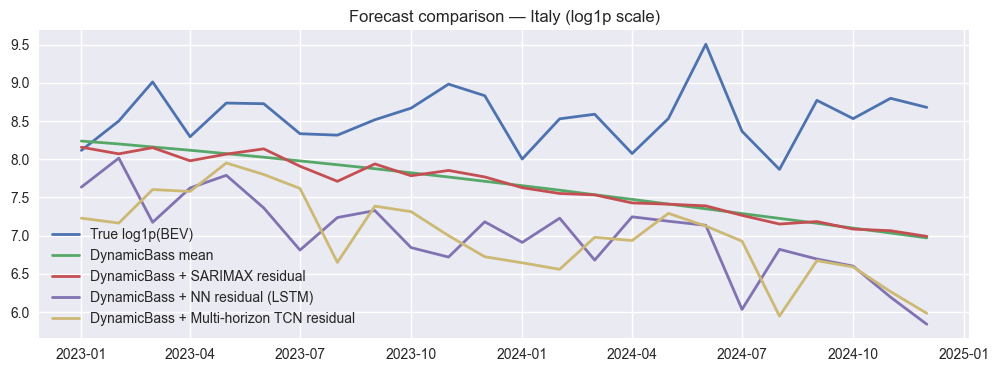

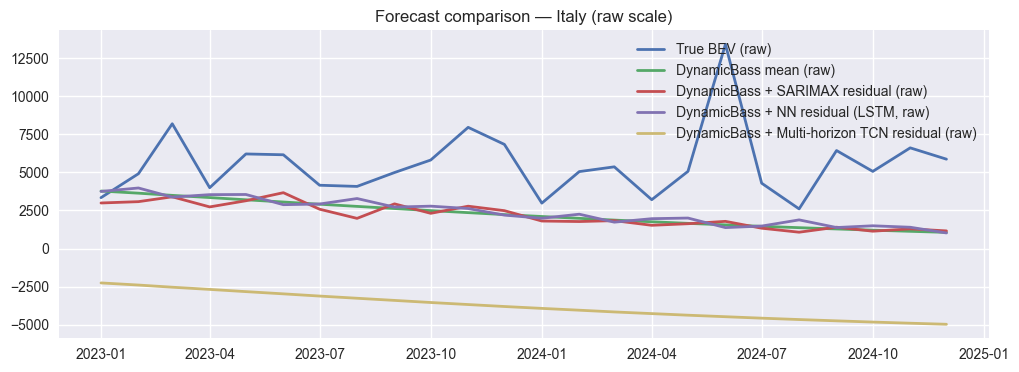

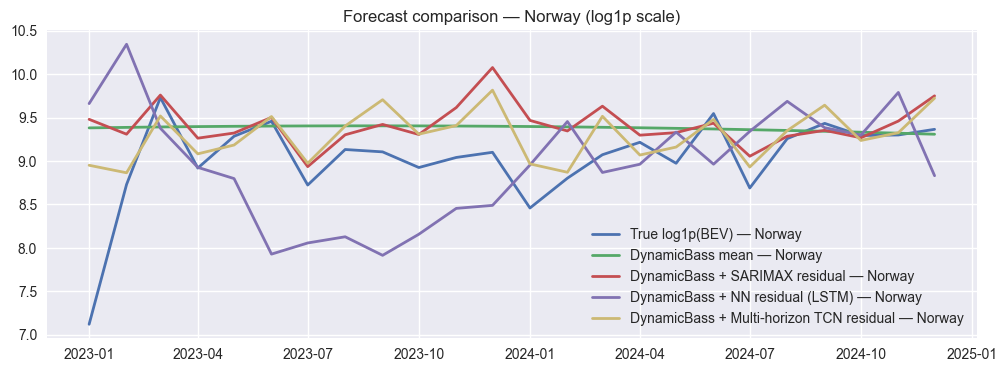

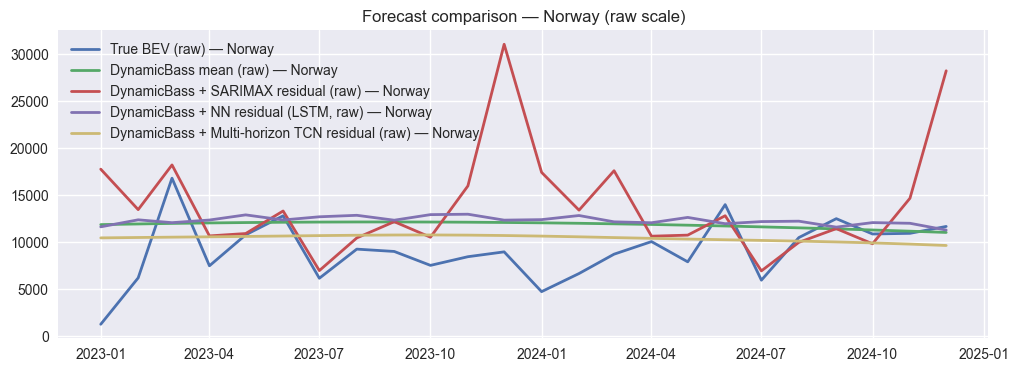

In [59]:
plt.figure(figsize=(12,4))
plt.plot(test.index, test.values, label="True log1p(BEV)", linewidth=2)

plt.plot(test.index, dyn_yhat_fore_it_log.loc[test.index].values,
         label="DynamicBass mean", linewidth=2)

plt.plot(test.index, y_fore_sarimax_dyn_it_log.loc[test.index].values,
         label="DynamicBass + SARIMAX residual", linewidth=2)

plt.plot(test.index, y_fore_dyn_it_log_nn.loc[test.index].values,
         label="DynamicBass + NN residual (LSTM)", linewidth=2)

plt.plot(test.index, y_fore_dyn_it_log_tcn_mh.loc[test.index].values,
         label="DynamicBass + Multi-horizon TCN residual", linewidth=2)

plt.title("Forecast comparison — Italy (log1p scale)")
plt.legend()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(test_it_raw.index, test_it_raw.values,
         label="True BEV (raw)", linewidth=2)

plt.plot(test_it_raw.index, dyn_yhat_fore_it_raw.loc[test_it_raw.index].values,
         label="DynamicBass mean (raw)", linewidth=2)

plt.plot(test_it_raw.index, y_fore_sarimax_dyn_it_raw.loc[test_it_raw.index].values,
         label="DynamicBass + SARIMAX residual (raw)", linewidth=2)

plt.plot(test_it_raw.index, y_fore_dyn_it_raw_nn.loc[test_it_raw.index].values,
         label="DynamicBass + NN residual (LSTM, raw)", linewidth=2)

plt.plot(test_it_raw.index, y_fore_dyn_it_raw_tcn_mh.loc[test_it_raw.index].values,
         label="DynamicBass + Multi-horizon TCN residual (raw)", linewidth=2)

plt.title("Forecast comparison — Italy (raw scale)")
plt.legend()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(test_no_log.index, test_no_log.values,
         label="True log1p(BEV) — Norway", linewidth=2)

plt.plot(test_no_log.index, dyn_yhat_fore_no_log.loc[test_no_log.index].values,
         label="DynamicBass mean — Norway", linewidth=2)

plt.plot(test_no_log.index, y_fore_sarimax_dyn_no_log.loc[test_no_log.index].values,
         label="DynamicBass + SARIMAX residual — Norway", linewidth=2)

plt.plot(test_no_log.index, y_fore_dyn_no_log_nn.loc[test_no_log.index].values,
         label="DynamicBass + NN residual (LSTM) — Norway", linewidth=2)

plt.plot(test_no_log.index, y_fore_dyn_no_log_tcn_mh.loc[test_no_log.index].values,
         label="DynamicBass + Multi-horizon TCN residual — Norway", linewidth=2)

plt.title("Forecast comparison — Norway (log1p scale)")
plt.legend()
plt.show()


plt.figure(figsize=(12,4))
plt.plot(test_no_raw.index, test_no_raw.values,
         label="True BEV (raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, dyn_yhat_fore_no_raw.loc[test_no_raw.index].values,
         label="DynamicBass mean (raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, y_fore_sarimax_dyn_no_raw.loc[test_no_raw.index].values,
         label="DynamicBass + SARIMAX residual (raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, y_fore_dyn_no_raw_nn.loc[test_no_raw.index].values,
         label="DynamicBass + NN residual (LSTM, raw) — Norway", linewidth=2)

plt.plot(test_no_raw.index, y_fore_dyn_no_raw_tcn_mh.loc[test_no_raw.index].values,
         label="DynamicBass + Multi-horizon TCN residual (raw) — Norway", linewidth=2)

plt.title("Forecast comparison — Norway (raw scale)")
plt.legend()
plt.show()


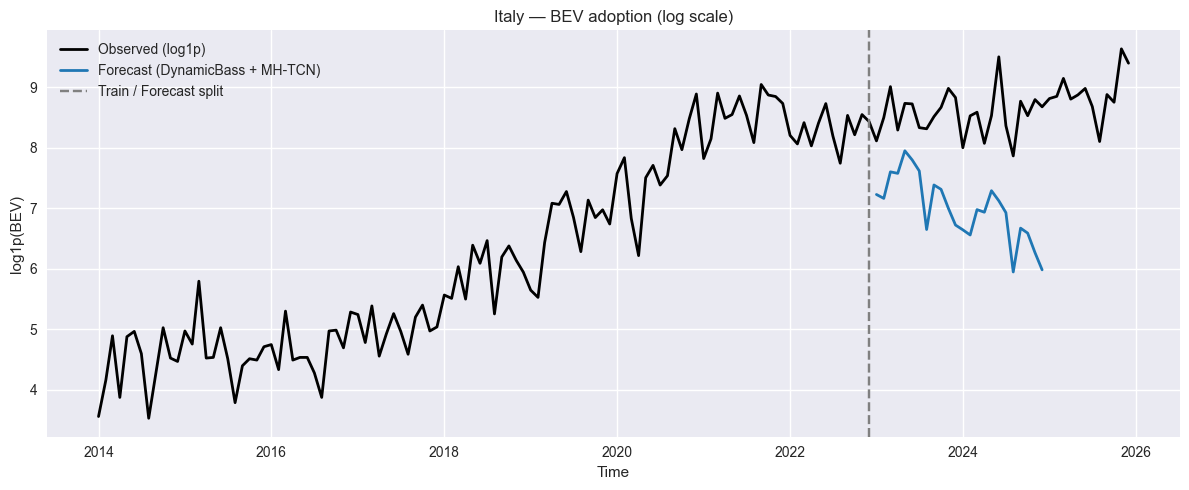

In [60]:
plt.figure(figsize=(12,5))

# Full historical data
plt.plot(ts_it_log.index, ts_it_log.values,
         label="Observed (log1p)", color="black", linewidth=2)

# Forecast (only future)
plt.plot(dyn_yhat_fore_it_log.index, y_fore_dyn_it_log_tcn_mh.values,
         label="Forecast (DynamicBass + MH-TCN)", color="tab:blue", linewidth=2)

# Train / forecast split
plt.axvline(pd.to_datetime(TRAIN_END),
            color="gray", linestyle="--", label="Train / Forecast split")

plt.title("Italy — BEV adoption (log scale)")
plt.xlabel("Time")
plt.ylabel("log1p(BEV)")
plt.legend()
plt.tight_layout()
plt.show()


Epoch 200/800 loss=0.122626
Epoch 400/800 loss=0.110335
Epoch 600/800 loss=0.108368
Epoch 800/800 loss=0.107826


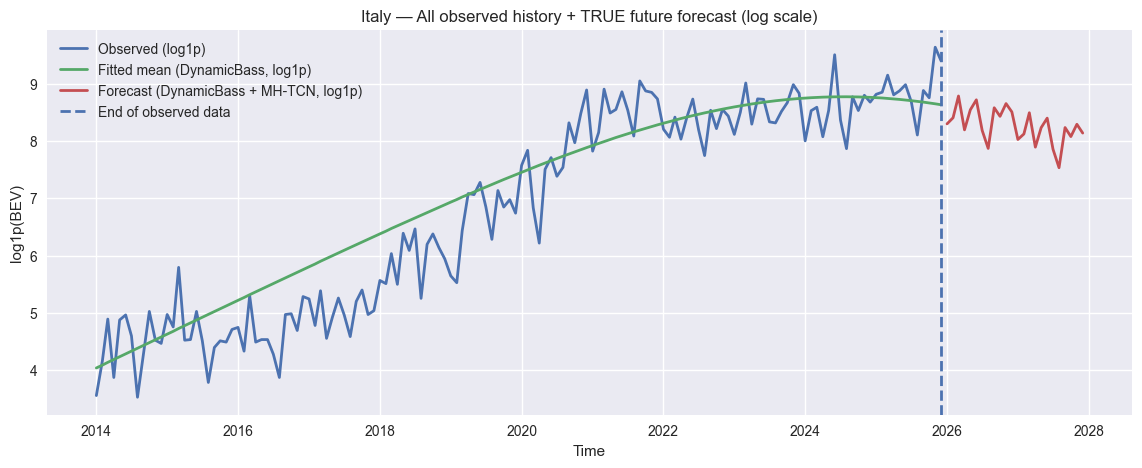

Epoch 200/800 loss=2688666.950000
Epoch 400/800 loss=2518905.200000
Epoch 600/800 loss=2670293.550000
Epoch 800/800 loss=2631296.425000


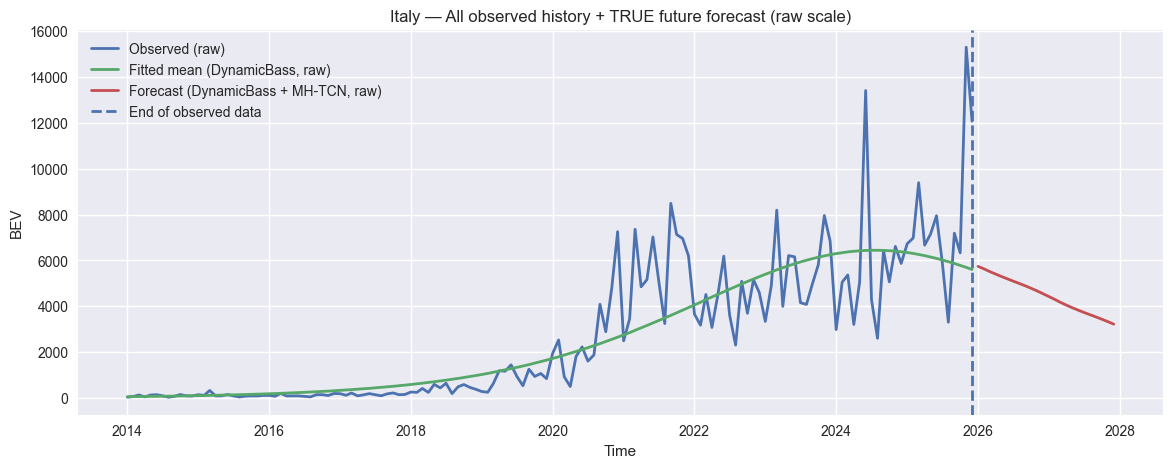

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
H = 24
LOOKBACK = 36

# choose series
ts_it = ts.dropna().astype(float)      # Italy raw series (monthly)
last_obs = ts_it.index.max()
TRAIN_END_FUTURE = last_obs            # <-- THIS makes it forecast beyond observed data
start_fore_date = (last_obs + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

# ============================================================
# 1) ITALY — DynamicBass + Multi-horizon TCN (LOG) — TRUE FUTURE
# ============================================================

# --- Diffusion fit on RAW (because your dynamic model outputs RAW flows) ---
dyn_fit_it = fit_dynamic_bass_logisticM(ts_it, train_end=TRAIN_END_FUTURE)
dyn_mean_it_raw_in = dyn_fit_it["yhat_train"]  # fitted mean (RAW) for whole history
dyn_mean_it_raw_fc = forecast_dynamic_bass_logisticM(ts_it, dyn_fit_it, train_end=TRAIN_END_FUTURE, horizon=H)

# --- Convert diffusion mean to LOG ---
dyn_mean_it_log_in = np.log1p(np.clip(dyn_mean_it_raw_in, 0, None))
dyn_mean_it_log_fc = np.log1p(np.clip(dyn_mean_it_raw_fc, 0, None))

# --- Build observed LOG series ---
ts_it_log = np.log1p(ts_it)

# --- Residuals on LOG, using all history up to last_obs ---
resid_train_dyn_it_log = (ts_it_log.loc[dyn_mean_it_log_in.index] - dyn_mean_it_log_in).dropna()

# --- Train MH-TCN on residuals and forecast future residuals ---
tcn_mh_dyn_it_log = train_multi_tcn(
    resid_train_dyn_it_log, lookback=LOOKBACK, horizon=H,
    epochs=800, batch_size=16, lr=1e-3
)

resid_fore_dyn_it_log = forecast_multi_tcn(
    tcn_mh_dyn_it_log, resid_train_dyn_it_log,
    start_date=start_fore_date, horizon=H, lookback=LOOKBACK
)

# --- Final future forecast on LOG ---
y_fore_dyn_it_log_tcn_mh_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log

# =========================
# PLOT (ALL HISTORY + FUTURE)
# =========================
plt.figure(figsize=(14,5))
plt.plot(ts_it_log.index, ts_it_log.values, label="Observed (log1p)", linewidth=2)
plt.plot(dyn_mean_it_log_in.index, dyn_mean_it_log_in.values, label="Fitted mean (DynamicBass, log1p)", linewidth=2)
plt.plot(y_fore_dyn_it_log_tcn_mh_future.index, y_fore_dyn_it_log_tcn_mh_future.values,
         label="Forecast (DynamicBass + MH-TCN, log1p)", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (log scale)")
plt.xlabel("Time")
plt.ylabel("log1p(BEV)")
plt.legend()
plt.show()


# ============================================================
# 2) ITALY — DynamicBass + Multi-horizon TCN (RAW) — TRUE FUTURE
# ============================================================

# Residuals on RAW
resid_train_dyn_it_raw = (ts_it.loc[dyn_mean_it_raw_in.index] - dyn_mean_it_raw_in).dropna()

tcn_mh_dyn_it_raw = train_multi_tcn(
    resid_train_dyn_it_raw, lookback=LOOKBACK, horizon=H,
    epochs=800, batch_size=16, lr=1e-3
)

resid_fore_dyn_it_raw = forecast_multi_tcn(
    tcn_mh_dyn_it_raw, resid_train_dyn_it_raw,
    start_date=start_fore_date, horizon=H, lookback=LOOKBACK
)

y_fore_dyn_it_raw_tcn_mh_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw

plt.figure(figsize=(14,5))
plt.plot(ts_it.index, ts_it.values, label="Observed (raw)", linewidth=2)
plt.plot(dyn_mean_it_raw_in.index, dyn_mean_it_raw_in.values, label="Fitted mean (DynamicBass, raw)", linewidth=2)
plt.plot(y_fore_dyn_it_raw_tcn_mh_future.index, y_fore_dyn_it_raw_tcn_mh_future.values,
         label="Forecast (DynamicBass + MH-TCN, raw)", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.xlabel("Time")
plt.ylabel("BEV")
plt.legend()
plt.show()


Epoch 200/800 loss=2712504.650000
Epoch 400/800 loss=2681620.375000
Epoch 600/800 loss=2707647.750000
Epoch 800/800 loss=2673356.500000


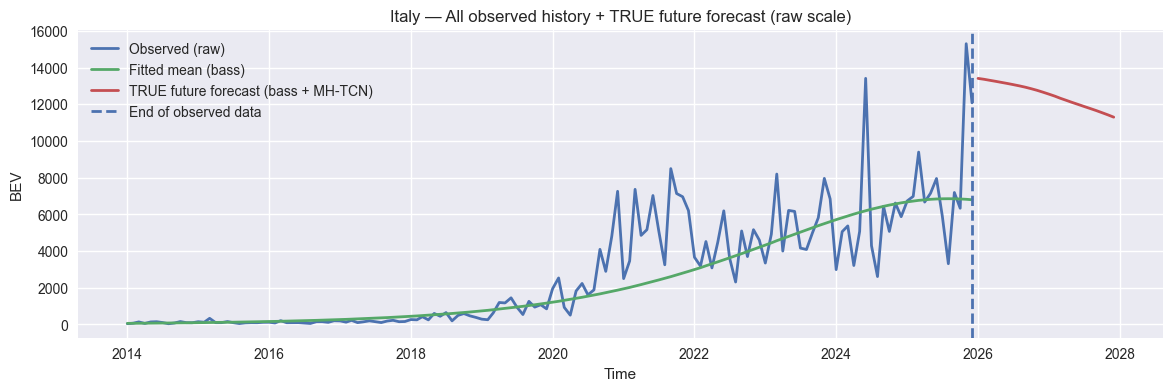

Epoch 200/800 loss=13701995.000000
Epoch 400/800 loss=12982617.400000
Epoch 600/800 loss=14171594.200000
Epoch 800/800 loss=14102729.000000


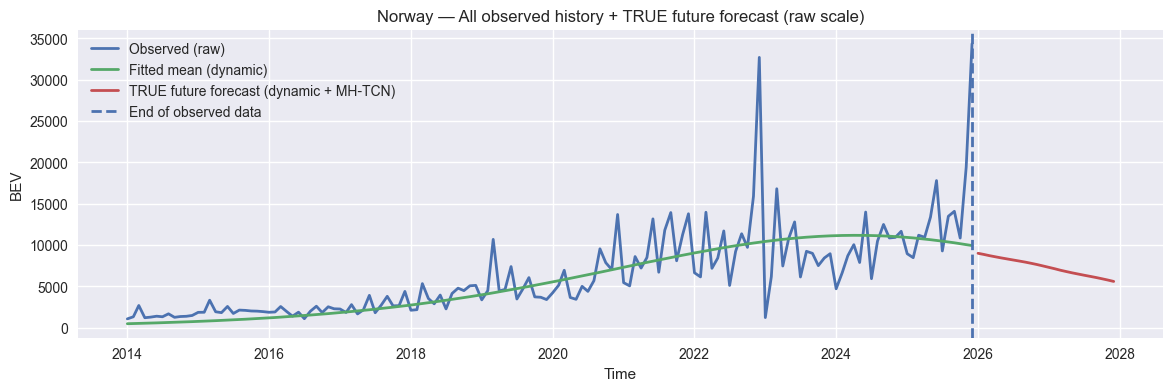

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ---------------------------
# Settings
# ---------------------------
H_FUTURE = 24         # how many months AFTER last observed you want to forecast
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

torch.manual_seed(42)
np.random.seed(42)

# ---------------------------
# Choose "best" model per country (EDIT if you want)
# ---------------------------
# Italy: if your best was Bass + MH-TCN, set italy_model = "bass"
# Norway: if your best was Dynamic + MH-TCN, set norway_model = "dynamic"
italy_model = "bass"      # "bass" or "dynamic"
norway_model = "dynamic"  # "bass" or "dynamic"

# ---------------------------
# Helper: run one country end-to-end (no new functions; just a block)
# ---------------------------

# =============== ITALY ===============
ts_it = ts.dropna().astype(float)
TRAIN_END_TRUE_IT = ts_it.index.max()  # last observed month

if italy_model == "dynamic":
    # Diffusion mean (RAW) fit on full history
    dyn_fit_it = fit_dynamic_bass_logisticM(ts_it, train_end=str(TRAIN_END_TRUE_IT.date()))
    mean_train_it = dyn_fit_it["yhat_train"]  # index aligned to train
    mean_fore_it  = forecast_dynamic_bass_logisticM(ts_it, dyn_fit_it, train_end=str(TRAIN_END_TRUE_IT.date()), horizon=H_FUTURE)
    mean_fore_it  = mean_fore_it.reindex(pd.date_range(TRAIN_END_TRUE_IT + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))

    # Residuals on RAW
    resid_train_it = (ts_it.loc[mean_train_it.index] - mean_train_it).dropna()

else:
    # Bass mean (RAW) fit on full history
    params_it = fit_bass_on_raw_flow_wmse(ts_it, train_end=str(TRAIN_END_TRUE_IT.date()), eps=50.0)
    mean_train_it = bass_predict_train_raw(ts_it, params_it, train_end=str(TRAIN_END_TRUE_IT.date()))
    mean_fore_it  = bass_forecast_raw(ts_it, params_it, train_end=str(TRAIN_END_TRUE_IT.date()), horizon=H_FUTURE)
    mean_fore_it  = mean_fore_it.reindex(pd.date_range(TRAIN_END_TRUE_IT + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))

    # Residuals on RAW
    resid_train_it = (ts_it.loc[mean_train_it.index] - mean_train_it).dropna()

# MH-TCN residual model (multi-horizon) on RAW residuals
tcn_mh_it = train_multi_tcn(resid_train_it, lookback=LOOKBACK, horizon=H_FUTURE, epochs=EPOCHS, batch_size=BATCH, lr=LR)
start_fore_it = (TRAIN_END_TRUE_IT + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()
resid_fore_it = forecast_multi_tcn(tcn_mh_it, resid_train_it, start_date=start_fore_it, horizon=H_FUTURE, lookback=LOOKBACK)
resid_fore_it.index = mean_fore_it.index

# Final forecast (RAW)
y_fore_it = mean_fore_it + resid_fore_it
y_fore_it = np.clip(y_fore_it, 0, None)

# Plot ITALY
plt.figure(figsize=(14,4))
plt.plot(ts_it.index, ts_it.values, label="Observed (raw)", linewidth=2)
plt.plot(mean_train_it.index, mean_train_it.values, label=f"Fitted mean ({italy_model})", linewidth=2)
plt.plot(y_fore_it.index, y_fore_it.values, label=f"TRUE future forecast ({italy_model} + MH-TCN)", linewidth=2)
plt.axvline(TRAIN_END_TRUE_IT, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.ylabel("BEV")
plt.xlabel("Time")
plt.legend()
plt.show()


# =============== NORWAY ===============
ts_no = ts_2.dropna().astype(float)
TRAIN_END_TRUE_NO = ts_no.index.max()  # last observed month

if norway_model == "dynamic":
    dyn_fit_no = fit_dynamic_bass_logisticM(ts_no, train_end=str(TRAIN_END_TRUE_NO.date()))
    mean_train_no = dyn_fit_no["yhat_train"]
    mean_fore_no  = forecast_dynamic_bass_logisticM(ts_no, dyn_fit_no, train_end=str(TRAIN_END_TRUE_NO.date()), horizon=H_FUTURE)
    mean_fore_no  = mean_fore_no.reindex(pd.date_range(TRAIN_END_TRUE_NO + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))

    resid_train_no = (ts_no.loc[mean_train_no.index] - mean_train_no).dropna()

else:
    params_no = fit_bass_on_raw_flow_wmse(ts_no, train_end=str(TRAIN_END_TRUE_NO.date()), eps=50.0)
    mean_train_no = bass_predict_train_raw(ts_no, params_no, train_end=str(TRAIN_END_TRUE_NO.date()))
    mean_fore_no  = bass_forecast_raw(ts_no, params_no, train_end=str(TRAIN_END_TRUE_NO.date()), horizon=H_FUTURE)
    mean_fore_no  = mean_fore_no.reindex(pd.date_range(TRAIN_END_TRUE_NO + pd.offsets.MonthBegin(1), periods=H_FUTURE, freq="MS"))

    resid_train_no = (ts_no.loc[mean_train_no.index] - mean_train_no).dropna()

# MH-TCN residuals
tcn_mh_no = train_multi_tcn(resid_train_no, lookback=LOOKBACK, horizon=H_FUTURE, epochs=EPOCHS, batch_size=BATCH, lr=LR)
start_fore_no = (TRAIN_END_TRUE_NO + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()
resid_fore_no = forecast_multi_tcn(tcn_mh_no, resid_train_no, start_date=start_fore_no, horizon=H_FUTURE, lookback=LOOKBACK)
resid_fore_no.index = mean_fore_no.index

y_fore_no = mean_fore_no + resid_fore_no
y_fore_no = np.clip(y_fore_no, 0, None)

# Plot NORWAY
plt.figure(figsize=(14,4))
plt.plot(ts_no.index, ts_no.values, label="Observed (raw)", linewidth=2)
plt.plot(mean_train_no.index, mean_train_no.values, label=f"Fitted mean ({norway_model})", linewidth=2)
plt.plot(y_fore_no.index, y_fore_no.values, label=f"TRUE future forecast ({norway_model} + MH-TCN)", linewidth=2)
plt.axvline(TRAIN_END_TRUE_NO, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Norway — All observed history + TRUE future forecast (raw scale)")
plt.ylabel("BEV")
plt.xlabel("Time")
plt.legend()
plt.show()


Epoch 50/300 loss=3171943.916667
Epoch 100/300 loss=3411095.666667
Epoch 150/300 loss=3118013.208333
Epoch 200/300 loss=2796157.302083
Epoch 250/300 loss=2699121.541667
Epoch 300/300 loss=2311032.583333
Epoch 50/300 loss=0.084130
Epoch 100/300 loss=0.090515
Epoch 150/300 loss=0.086983
Epoch 200/300 loss=0.049583
Epoch 250/300 loss=0.029133
Epoch 300/300 loss=0.015959
Epoch 100/800 loss=278997.476562
Epoch 200/800 loss=278402.877604
Epoch 300/800 loss=102988.602214
Epoch 400/800 loss=86043.201172
Epoch 500/800 loss=67854.716146
Epoch 600/800 loss=68925.912760
Epoch 700/800 loss=57719.921875
Epoch 800/800 loss=58023.372396
Epoch 100/800 loss=0.033211
Epoch 200/800 loss=0.019777
Epoch 300/800 loss=0.008303
Epoch 400/800 loss=0.006847
Epoch 500/800 loss=0.005945
Epoch 600/800 loss=0.006377
Epoch 700/800 loss=0.003383
Epoch 800/800 loss=0.003404
Epoch 200/800 loss=2653082.100000
Epoch 400/800 loss=2630014.775000
Epoch 600/800 loss=2611176.025000
Epoch 800/800 loss=2653880.025000
Epoch 200/8

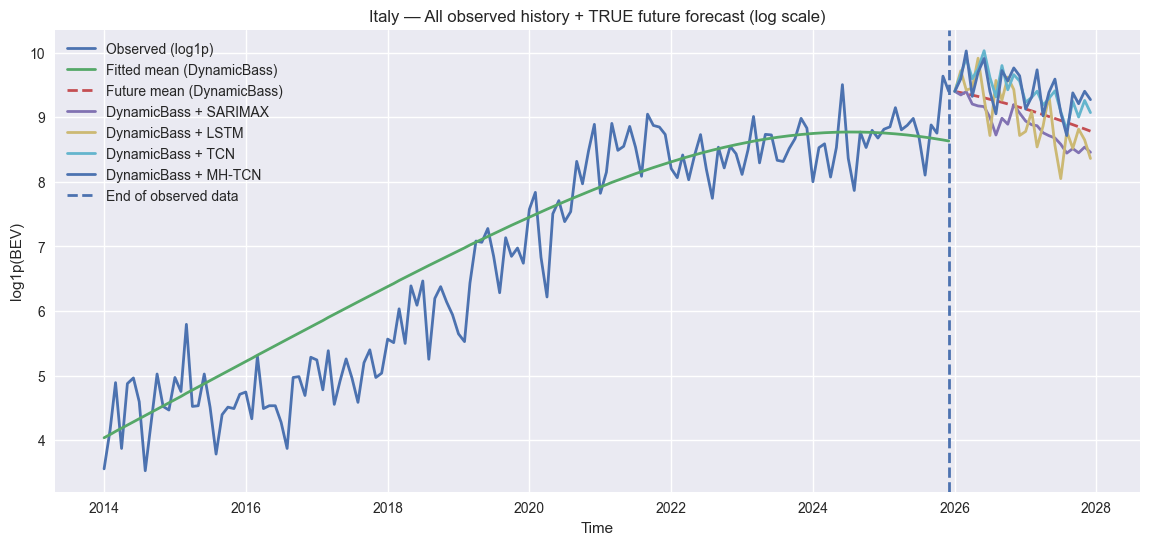

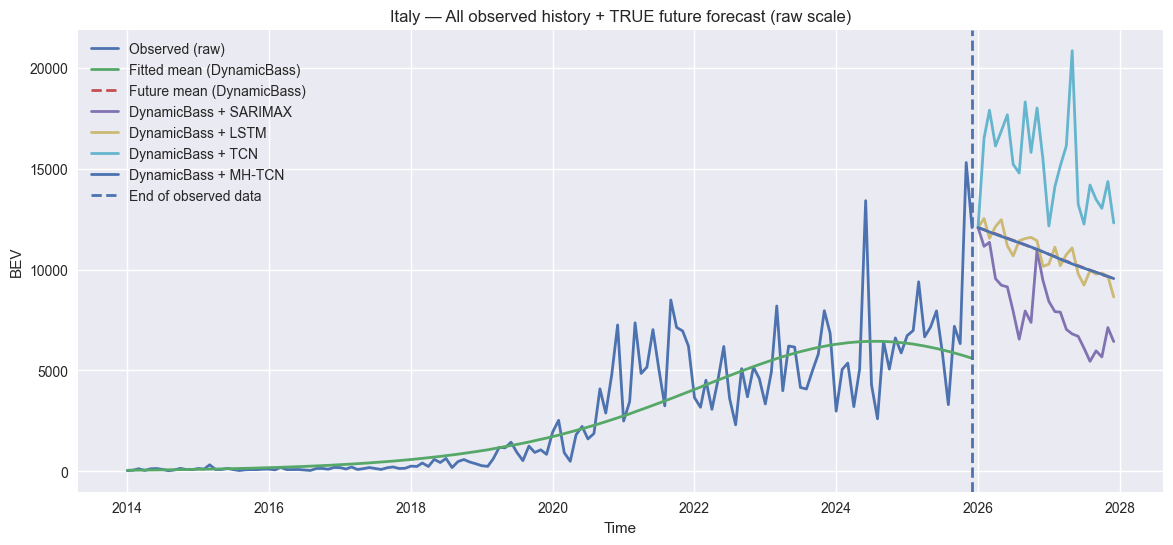

In [63]:
# =========================
# SETTINGS
# =========================
H = 24
LOOKBACK = 36

ts_it = ts.dropna().astype(float)
last_obs = ts_it.index.max()
TRAIN_END_FUTURE = last_obs
start_fore_date = (last_obs + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

# ============================================================
# 1) FIT DYNAMIC DIFFUSION ON RAW
# ============================================================
dyn_fit_it = fit_dynamic_bass_logisticM(ts_it, train_end=TRAIN_END_FUTURE)
dyn_mean_it_raw_in = dyn_fit_it["yhat_train"]
dyn_mean_it_raw_fc = forecast_dynamic_bass_logisticM(ts_it, dyn_fit_it, train_end=TRAIN_END_FUTURE, horizon=H)

# Observed series
ts_it_raw = ts_it.copy()
ts_it_log = np.log1p(ts_it_raw)

# Convert mean to log
dyn_mean_it_log_in = np.log1p(np.clip(dyn_mean_it_raw_in, 0, None))
dyn_mean_it_log_fc = np.log1p(np.clip(dyn_mean_it_raw_fc, 0, None))

# ============================================================
# 2) BUILD RESIDUALS
# ============================================================

# RAW residuals
resid_train_dyn_it_raw = (ts_it_raw.loc[dyn_mean_it_raw_in.index] - dyn_mean_it_raw_in).dropna()

# LOG residuals
resid_train_dyn_it_log = (ts_it_log.loc[dyn_mean_it_log_in.index] - dyn_mean_it_log_in).dropna()

# ============================================================
# 3) SARIMAX RESIDUAL FORECASTS
# ============================================================
sarimax_fit_dyn_it_raw = fit_residual_sarimax(resid_train_dyn_it_raw)
resid_fore_dyn_it_raw_sar = sarimax_fit_dyn_it_raw.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_raw_sar.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_sar_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_sar

sarimax_fit_dyn_it_log = fit_residual_sarimax(resid_train_dyn_it_log)
resid_fore_dyn_it_log_sar = sarimax_fit_dyn_it_log.get_forecast(steps=H).predicted_mean
resid_fore_dyn_it_log_sar.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_sar_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_sar

# ============================================================
# 4) LSTM RESIDUAL FORECASTS
# ============================================================
LOOKBACK_LSTM = 24

nn_model_dyn_it_raw = train_residual_nn(resid_train_dyn_it_raw, lookback=LOOKBACK_LSTM, epochs=300, batch_size=32, lr=1e-3)
resid_fore_dyn_it_raw_nn = forecast_residual_nn(
    nn_model_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK_LSTM
)
resid_fore_dyn_it_raw_nn.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_nn_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_nn

nn_model_dyn_it_log = train_residual_nn(resid_train_dyn_it_log, lookback=LOOKBACK_LSTM, epochs=300, batch_size=32, lr=1e-3)
resid_fore_dyn_it_log_nn = forecast_residual_nn(
    nn_model_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK_LSTM
)
resid_fore_dyn_it_log_nn.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_nn_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_nn

# ============================================================
# 5) TCN RESIDUAL FORECASTS
# ============================================================
tcn_model_dyn_it_raw = train_tcn(resid_train_dyn_it_raw, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_raw_tcn = forecast_tcn(
    tcn_model_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_raw_tcn.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_tcn_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_tcn

tcn_model_dyn_it_log = train_tcn(resid_train_dyn_it_log, lookback=LOOKBACK, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_log_tcn = forecast_tcn(
    tcn_model_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_log_tcn.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_tcn_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_tcn

# ============================================================
# 6) MULTI-HORIZON TCN RESIDUAL FORECASTS
# ============================================================
tcn_mh_dyn_it_raw = train_multi_tcn(resid_train_dyn_it_raw, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_raw_mh = forecast_multi_tcn(
    tcn_mh_dyn_it_raw,
    resid_train_dyn_it_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_raw_mh.index = dyn_mean_it_raw_fc.index
y_fore_dyn_it_raw_mh_future = dyn_mean_it_raw_fc + resid_fore_dyn_it_raw_mh

tcn_mh_dyn_it_log = train_multi_tcn(resid_train_dyn_it_log, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn_it_log_mh = forecast_multi_tcn(
    tcn_mh_dyn_it_log,
    resid_train_dyn_it_log,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_dyn_it_log_mh.index = dyn_mean_it_log_fc.index
y_fore_dyn_it_log_mh_future = dyn_mean_it_log_fc + resid_fore_dyn_it_log_mh

# ============================================================
# 7) ANCHOR FUTURE FORECASTS TO LAST OBSERVED VALUE
# ============================================================

def anchor_forecast_to_last_observed(y_fore, observed_series):
    offset = observed_series.iloc[-1] - y_fore.iloc[0]
    return y_fore + offset

# RAW
dyn_mean_it_raw_fc_anchor      = anchor_forecast_to_last_observed(dyn_mean_it_raw_fc, ts_it_raw)
y_fore_dyn_it_raw_sar_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_sar_future, ts_it_raw)
y_fore_dyn_it_raw_nn_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_nn_future, ts_it_raw)
y_fore_dyn_it_raw_tcn_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_tcn_future, ts_it_raw)
y_fore_dyn_it_raw_mh_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_raw_mh_future, ts_it_raw)

# LOG
dyn_mean_it_log_fc_anchor      = anchor_forecast_to_last_observed(dyn_mean_it_log_fc, ts_it_log)
y_fore_dyn_it_log_sar_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_log_sar_future, ts_it_log)
y_fore_dyn_it_log_nn_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_log_nn_future, ts_it_log)
y_fore_dyn_it_log_tcn_future   = anchor_forecast_to_last_observed(y_fore_dyn_it_log_tcn_future, ts_it_log)
y_fore_dyn_it_log_mh_future    = anchor_forecast_to_last_observed(y_fore_dyn_it_log_mh_future, ts_it_log)

# ============================================================
# 8) PLOT — LOG SCALE
# ============================================================
plt.figure(figsize=(14, 6))
plt.plot(ts_it_log.index, ts_it_log.values, label="Observed (log1p)", linewidth=2)
plt.plot(dyn_mean_it_log_in.index, dyn_mean_it_log_in.values, label="Fitted mean (DynamicBass)", linewidth=2)
plt.plot(dyn_mean_it_log_fc_anchor.index, dyn_mean_it_log_fc_anchor.values, label="Future mean (DynamicBass)", linewidth=2, linestyle="--")
plt.plot(y_fore_dyn_it_log_sar_future.index, y_fore_dyn_it_log_sar_future.values, label="DynamicBass + SARIMAX", linewidth=2)
plt.plot(y_fore_dyn_it_log_nn_future.index, y_fore_dyn_it_log_nn_future.values, label="DynamicBass + LSTM", linewidth=2)
plt.plot(y_fore_dyn_it_log_tcn_future.index, y_fore_dyn_it_log_tcn_future.values, label="DynamicBass + TCN", linewidth=2)
plt.plot(y_fore_dyn_it_log_mh_future.index, y_fore_dyn_it_log_mh_future.values, label="DynamicBass + MH-TCN", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (log scale)")
plt.xlabel("Time")
plt.ylabel("log1p(BEV)")
plt.legend()
plt.show()

# ============================================================
# 9) PLOT — RAW SCALE
# ============================================================
plt.figure(figsize=(14, 6))
plt.plot(ts_it_raw.index, ts_it_raw.values, label="Observed (raw)", linewidth=2)
plt.plot(dyn_mean_it_raw_in.index, dyn_mean_it_raw_in.values, label="Fitted mean (DynamicBass)", linewidth=2)
plt.plot(dyn_mean_it_raw_fc_anchor.index, dyn_mean_it_raw_fc_anchor.values, label="Future mean (DynamicBass)", linewidth=2, linestyle="--")
plt.plot(y_fore_dyn_it_raw_sar_future.index, y_fore_dyn_it_raw_sar_future.values, label="DynamicBass + SARIMAX", linewidth=2)
plt.plot(y_fore_dyn_it_raw_nn_future.index, y_fore_dyn_it_raw_nn_future.values, label="DynamicBass + LSTM", linewidth=2)
plt.plot(y_fore_dyn_it_raw_tcn_future.index, y_fore_dyn_it_raw_tcn_future.values, label="DynamicBass + TCN", linewidth=2)
plt.plot(y_fore_dyn_it_raw_mh_future.index, y_fore_dyn_it_raw_mh_future.values, label="DynamicBass + MH-TCN", linewidth=2)

plt.axvline(last_obs, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.xlabel("Time")
plt.ylabel("BEV")
plt.legend()
plt.show()

Epoch 200/800 loss=2644312.950000
Epoch 400/800 loss=2713760.250000
Epoch 600/800 loss=2590797.750000
Epoch 800/800 loss=2657128.925000


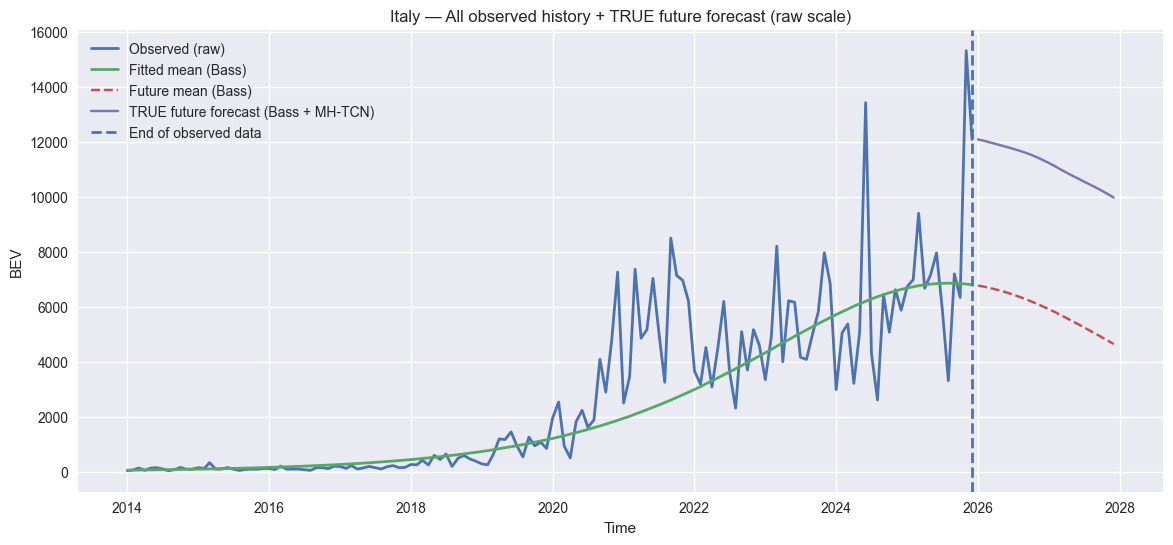

Epoch 200/800 loss=13731558.200000
Epoch 400/800 loss=13386675.600000
Epoch 600/800 loss=13763941.300000
Epoch 800/800 loss=13346014.400000


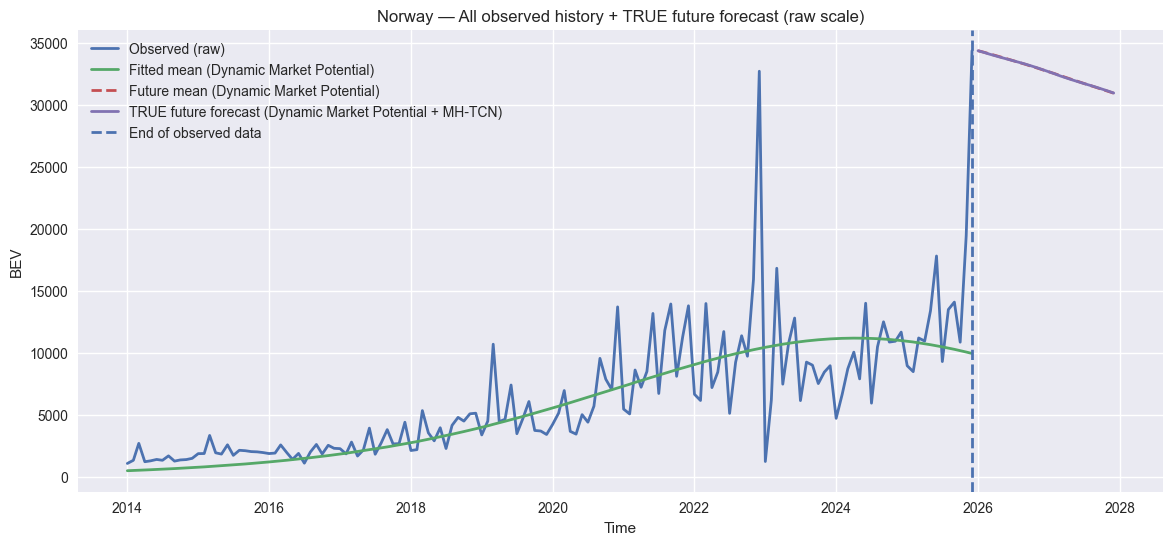

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
H = 24
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

def anchor_forecast_to_last_observed(y_fore: pd.Series, observed_series: pd.Series):
    """
    Shift future forecast so that its first point starts at the last observed value.
    Used only for visualization continuity.
    """
    offset = observed_series.iloc[-1] - y_fore.iloc[0]
    return y_fore + offset

# ============================================================
# ITALY — RAW — BEST MODEL: Bass + MH-TCN
# ============================================================
ts_it_raw = ts.dropna().astype(float)
last_obs_it = ts_it_raw.index.max()
TRAIN_END_FUTURE_IT = last_obs_it
start_fore_date_it = (last_obs_it + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

# --- Bass mean fit on full observed history ---
params_it_raw = fit_bass_on_raw_flow_wmse(ts_it_raw, train_end=TRAIN_END_FUTURE_IT, eps=50.0)
bass_mean_it_raw_in = bass_predict_train_raw(ts_it_raw, params_it_raw, train_end=TRAIN_END_FUTURE_IT)
bass_mean_it_raw_fc = bass_forecast_raw(ts_it_raw, params_it_raw, train_end=TRAIN_END_FUTURE_IT, horizon=H)

# --- Residuals on RAW ---
resid_train_it_raw = (ts_it_raw.loc[bass_mean_it_raw_in.index] - bass_mean_it_raw_in).dropna()

# --- MH-TCN residual model ---
tcn_mh_it_raw = train_multi_tcn(
    resid_train_it_raw,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

resid_fore_it_raw_mh = forecast_multi_tcn(
    tcn_mh_it_raw,
    resid_train_it_raw,
    start_date=start_fore_date_it,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_it_raw_mh.index = bass_mean_it_raw_fc.index

# --- Final future forecast ---
y_fore_it_raw_mh_future = bass_mean_it_raw_fc + resid_fore_it_raw_mh

# --- Anchor for visualization ---
y_fore_it_raw_mh_future_anchor = anchor_forecast_to_last_observed(y_fore_it_raw_mh_future, ts_it_raw)

# --- Plot Italy ---
plt.figure(figsize=(14, 6))
plt.plot(ts_it_raw.index, ts_it_raw.values, label="Observed (raw)", linewidth=2)
plt.plot(bass_mean_it_raw_in.index, bass_mean_it_raw_in.values, label="Fitted mean (Bass)", linewidth=2)
plt.plot(bass_mean_it_raw_fc.index, bass_mean_it_raw_fc.values,
         label="Future mean (Bass)", linestyle="--")

plt.plot(y_fore_it_raw_mh_future_anchor.index, y_fore_it_raw_mh_future_anchor.values,
         label="TRUE future forecast (Bass + MH-TCN)")

plt.axvline(last_obs_it, linestyle="--", linewidth=2, label="End of observed data")
plt.title("Italy — All observed history + TRUE future forecast (raw scale)")
plt.xlabel("Time")
plt.ylabel("BEV")
plt.legend()
plt.show()


# ============================================================
# NORWAY — RAW — BEST MODEL: Dynamic Market Potential + MH-TCN
# ============================================================
ts_no = ts_2.dropna().astype(float)
last_obs_no = ts_no.index.max()

def anchor_forecast_to_last_observed(forecast, observed):
    offset = observed.iloc[-1] - forecast.iloc[0]
    return forecast + offset
TRAIN_END_FUTURE_NO = last_obs_no
start_fore_date_no = (last_obs_no + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()

# --- Dynamic mean fit on full observed history ---
dyn_fit_no = fit_dynamic_bass_logisticM(ts_no_raw, train_end=TRAIN_END_FUTURE_NO)
dyn_mean_no_raw_in = dyn_fit_no["yhat_train"]
dyn_mean_no_raw_fc = forecast_dynamic_bass_logisticM(ts_no_raw, dyn_fit_no, train_end=TRAIN_END_FUTURE_NO, horizon=H)

# --- Residuals on RAW ---
resid_train_no_raw = (ts_no_raw.loc[dyn_mean_no_raw_in.index] - dyn_mean_no_raw_in).dropna()

# --- MH-TCN residual model ---
tcn_mh_no_raw = train_multi_tcn(
    resid_train_no_raw,
    lookback=LOOKBACK,
    horizon=H,
    epochs=EPOCHS,
    batch_size=BATCH,
    lr=LR
)

resid_fore_no_raw_mh = forecast_multi_tcn(
    tcn_mh_no_raw,
    resid_train_no_raw,
    start_date=start_fore_date_no,
    horizon=H,
    lookback=LOOKBACK
)
resid_fore_no_raw_mh.index = dyn_mean_no_raw_fc.index

# Fit SARIMAX on residuals
sarimax_no = SARIMAX(
    resid_train_dyn_no_raw,
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast residuals
resid_fore_no_raw_sarimax = sarimax_no.forecast(steps=H)

resid_fore_no_raw_tcn = forecast_tcn(
    tcn_model_dyn_no_raw,
    resid_train_dyn_no_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)


resid_fore_no_raw_lstm = forecast_residual_nn(
    nn_model_dyn_no_raw,
    resid_train_dyn_no_raw,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

y_fore_no_raw_lstm_future = dyn_mean_no_raw_fc + resid_fore_no_raw_lstm

# Final forecast
y_fore_no_raw_sarimax_future = dyn_mean_no_raw_fc + resid_fore_no_raw_sarimax

# Final forecast
y_fore_no_raw_tcn_future = dyn_mean_no_raw_fc + resid_fore_no_raw_tcn

# --- Final future forecast ---
y_fore_no_raw_mh_future = dyn_mean_no_raw_fc + resid_fore_no_raw_mh

# --- Anchor for visualization ---
y_fore_no_raw_mh_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_mh_future, ts_no)
y_fore_no_raw_tcn_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_tcn_future, ts_no)
y_fore_no_raw_lstm_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_lstm_future, ts_no)
y_fore_no_raw_sarimax_anchor = anchor_forecast_to_last_observed(y_fore_no_raw_sarimax_future, ts_no)

# --- Plot Norway ---
plt.figure(figsize=(14,5))

# observed
plt.plot(ts_no.index, ts_no.values,
         label="Observed BEV", linewidth=3)

# diffusion mean
plt.plot(dyn_mean_no_raw_fc.index, dyn_mean_no_raw_fc.values,
         label="Dynamic Market Potential mean", linestyle="--", linewidth=2)

# residual models
plt.plot(y_fore_no_raw_sarimax_anchor.index, y_fore_no_raw_sarimax_anchor.values,
         label="DynamicBass + SARIMAX")

plt.plot(y_fore_no_raw_lstm_anchor.index, y_fore_no_raw_lstm_anchor.values,
         label="DynamicBass + LSTM")

plt.plot(y_fore_no_raw_tcn_anchor.index, y_fore_no_raw_tcn_anchor.values,
         label="DynamicBass + TCN")

plt.plot(y_fore_no_raw_mh_anchor.index, y_fore_no_raw_mh_anchor.values,
         label="DynamicBass + MH-TCN (best)", linewidth=3)

plt.axvline(last_obs_no, linestyle="--", color="black")

plt.title("Norway BEV Forecast Comparison (Raw Scale)")
plt.ylabel("Monthly BEV registrations")
plt.xlabel("Time")
plt.legend()
plt.show()

In [65]:
print("ITALY")
print("First 5 future mean values:")
print(bass_mean_it_raw_fc.head())

print("First 5 residual forecast values:")
print(resid_fore_it_raw_mh.head())

print("First 5 final forecast values:")
print(y_fore_it_raw_mh_future.head())

print("Residual forecast summary:")
print(resid_fore_it_raw_mh.describe())

ITALY
First 5 future mean values:
2026-01-01    6762.967689
2026-02-01    6724.378985
2026-03-01    6679.076577
2026-04-01    6627.235039
2026-05-01    6569.053895
Freq: MS, dtype: float64
First 5 residual forecast values:
2026-01-01    7637.403320
2026-02-01    7627.138672
2026-03-01    7617.761230
2026-04-01    7611.784668
2026-05-01    7610.809570
Freq: MS, dtype: float32
First 5 final forecast values:
2026-01-01    14400.371009
2026-02-01    14351.517657
2026-03-01    14296.837808
2026-04-01    14239.019707
2026-05-01    14179.863465
Freq: MS, dtype: float64
Residual forecast summary:
count      24.000000
mean     7630.451660
std        14.388556
min      7610.809570
25%      7617.095459
50%      7630.452148
75%      7643.808594
max      7650.094727
dtype: float64


## COMPUTATIONAL COST

In [361]:
import time

def timed_train(train_fn, *args, **kwargs):
    """
    Wrap any training function and measure wall-clock time.
    """
    start = time.time()
    model = train_fn(*args, **kwargs)
    elapsed = time.time() - start
    return model, elapsed



In [362]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

results_cost = []

# ---------------------------
# Baseline: Bass mean (no training cost)
# ---------------------------
mae_bass = mean_absolute_error(y_true, yhat_fore.loc[test.index])
results_cost.append({
    "Model": "Bass mean",
    "MAE": mae_bass,
    "ΔMAE vs Bass": 0.0,
    "Train time (s)": 0.0
})

# ---------------------------
# SARIMAX residual
# ---------------------------
start = time.time()
sarimax_fit = fit_residual_sarimax(resid_train)
sarimax_time = time.time() - start

resid_fore = sarimax_fit.get_forecast(steps=H).predicted_mean
resid_fore.index = yhat_fore.index
y_fore_sar = yhat_fore + resid_fore

mae_sar = mean_absolute_error(y_true, y_fore_sar.loc[test.index])

results_cost.append({
    "Model": "Bass + SARIMAX residual",
    "MAE": mae_sar,
    "ΔMAE vs Bass": mae_bass - mae_sar,
    "Train time (s)": sarimax_time
})

# ---------------------------
# Multi-horizon TCN residual
# ---------------------------
tcn_mh, tcn_time = timed_train(
    train_multi_tcn,
    resid_train,
    lookback=LOOKBACK,
    horizon=H,
    epochs=800,
    batch_size=16,
    lr=1e-3
)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh = forecast_multi_tcn(
    tcn_mh,
    resid_train,
    start_date=start_fore_date,
    horizon=H,
    lookback=LOOKBACK
)

y_fore_tcn_mh = yhat_fore + resid_fore_mh
mae_tcn = mean_absolute_error(y_true, y_fore_tcn_mh.loc[test.index])

results_cost.append({
    "Model": "Bass + Multi-horizon TCN residual",
    "MAE": mae_tcn,
    "ΔMAE vs Bass": mae_bass - mae_tcn,
    "Train time (s)": tcn_time
})

df_cost_it_log = pd.DataFrame(results_cost)
print(df_cost_it_log)


Epoch 200/800 loss=0.170106
Epoch 400/800 loss=0.148025
Epoch 600/800 loss=0.143312
Epoch 800/800 loss=0.139404
                               Model       MAE  ΔMAE vs Bass  Train time (s)
0                          Bass mean  0.476213      0.000000        0.000000
1            Bass + SARIMAX residual  0.444475      0.031738        0.483211
2  Bass + Multi-horizon TCN residual  0.439916      0.036297       42.342460


In [363]:
import time
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_residual_sarimax(resid_train: pd.Series):
    model = SARIMAX(
        resid_train,
        order=(1,0,1),
        seasonal_order=(1,0,0,12),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit(disp=False)

def time_block(name, fn):
    t0 = time.perf_counter()
    out = fn()
    t1 = time.perf_counter()
    print(f"{name} train time: {t1 - t0:.3f} s")
    return out, (t1 - t0)

# ---------------------------
# Norway series (RAW)
# ---------------------------
TRAIN_END = "2022-12-01"
H = 24

ts_no_raw = ts_2.dropna().astype(float)

# 1) Dynamic Market Potential (fit diffusion)
dyn_fit_no, t_dyn_fit = time_block(
    "Norway DynamicBass (diffusion fit)",
    lambda: fit_dynamic_bass_logisticM(ts_no_raw, train_end=TRAIN_END)
)

dyn_mean_no_raw = forecast_dynamic_bass_logisticM(ts_no_raw, dyn_fit_no, train_end=TRAIN_END, horizon=H)

# residuals (RAW)
dyn_yhat_train_no_raw = dyn_fit_no["yhat_train"]
resid_train_dyn_no_raw = (ts_no_raw.loc[dyn_yhat_train_no_raw.index] - dyn_yhat_train_no_raw).dropna()

# 2) Dynamic + SARIMAX
sarimax_no, t_sar = time_block(
    "Norway DynamicBass + SARIMAX (residual fit)",
    lambda: fit_residual_sarimax(resid_train_dyn_no_raw)
)

# forecast SARIMAX residuals (timing is usually tiny; optional)
resid_fore_sar = sarimax_no.get_forecast(steps=H).predicted_mean
resid_fore_sar.index = dyn_mean_no_raw.index
y_fore_dyn_no_raw_sarimax = dyn_mean_no_raw + resid_fore_sar

# 3) Dynamic + Multi-Horizon TCN
LOOKBACK = 36
EPOCHS = 800
BATCH = 16
LR = 1e-3

tcn_mh_no, t_tcn = time_block(
    "Norway DynamicBass + MH-TCN (residual training)",
    lambda: train_multi_tcn(resid_train_dyn_no_raw, lookback=LOOKBACK, horizon=H,
                            epochs=EPOCHS, batch_size=BATCH, lr=LR)
)

start_fore_date = (pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp()
resid_fore_mh = forecast_multi_tcn(tcn_mh_no, resid_train_dyn_no_raw, start_date=start_fore_date,
                                  horizon=H, lookback=LOOKBACK)
resid_fore_mh.index = dyn_mean_no_raw.index
y_fore_dyn_no_raw_mh_tcn = dyn_mean_no_raw + resid_fore_mh

print("\nSummary (Norway RAW):")
print(f"DynamicBass diffusion fit: {t_dyn_fit:.3f} s")
print(f"DynamicBass + SARIMAX fit: {t_sar:.3f} s")
print(f"DynamicBass + MH-TCN train: {t_tcn:.3f} s")


Norway DynamicBass (diffusion fit) train time: 0.552 s
Norway DynamicBass + SARIMAX (residual fit) train time: 0.677 s
Epoch 200/800 loss=4861339.916667
Epoch 400/800 loss=4858014.833333
Epoch 600/800 loss=4855713.000000
Epoch 800/800 loss=4849019.333333
Norway DynamicBass + MH-TCN (residual training) train time: 73.503 s

Summary (Norway RAW):
DynamicBass diffusion fit: 0.552 s
DynamicBass + SARIMAX fit: 0.677 s
DynamicBass + MH-TCN train: 73.503 s


### error by horizon

In [ ]:
import numpy as np
import pandas as pd

# True series and forecasts as pandas Series aligned to test.index
y_true_s = pd.Series(test.values, index=test.index, name="y_true")

y_bass_s   = pd.Series(yhat_fore.loc[test.index].values, index=test.index, name="Bass")
y_sar_s    = pd.Series(y_fore_sarimax.loc[test.index].values, index=test.index, name="Bass+SARIMAX")
y_nn_s     = pd.Series(y_fore_nn.loc[test.index].values, index=test.index, name="Bass+LSTM")
y_tcn_s    = pd.Series(y_fore_tcn.loc[test.index].values, index=test.index, name="Bass+TCN")
y_tcn_mh_s = pd.Series(y_fore_bass_tcn_mh.loc[test.index].values, index=test.index, name="Bass+MH-TCN")

forecasts = {
    "Bass": y_bass_s,
    "Bass+SARIMAX": y_sar_s,
    "Bass+LSTM": y_nn_s,
    "Bass+TCN": y_tcn_s,
    "Bass+MH-TCN": y_tcn_mh_s
}


def error_by_horizon_single(y_true: pd.Series, forecasts: dict):
    H = len(y_true)
    rows = []
    for model, y_pred in forecasts.items():
        y_pred = y_pred.reindex(y_true.index)
        for h, dt in enumerate(y_true.index, start=1):
            err = y_true.loc[dt] - y_pred.loc[dt]
            rows.append({
                "Model": model,
                "h": h,
                "date": dt,
                "abs_err": float(abs(err)),
                "sq_err": float(err**2),
                "ape": float(abs(err) / (abs(y_true.loc[dt]) + 1e-8))
            })
    df = pd.DataFrame(rows)
    out = (df.groupby(["Model", "h"])
             .agg(MAE=("abs_err", "mean"),
                  RMSE=("sq_err", lambda s: float(np.sqrt(np.mean(s)))),
                  MAPE=("ape", lambda s: float(100*np.mean(s))))
             .reset_index())
    return out, df

horizon_metrics, horizon_raw = error_by_horizon_single(y_true_s, forecasts)
horizon_metrics.head()


,Model,h,MAE,RMSE,MAPE
0,Bass,1,0.084996,0.084996,1.047438
1,Bass,2,0.296837,0.296837,3.492182
2,Bass,3,0.806217,0.806217,8.946630
3,Bass,4,0.087762,0.087762,1.058232
4,Bass,5,0.530298,0.530298,6.071261


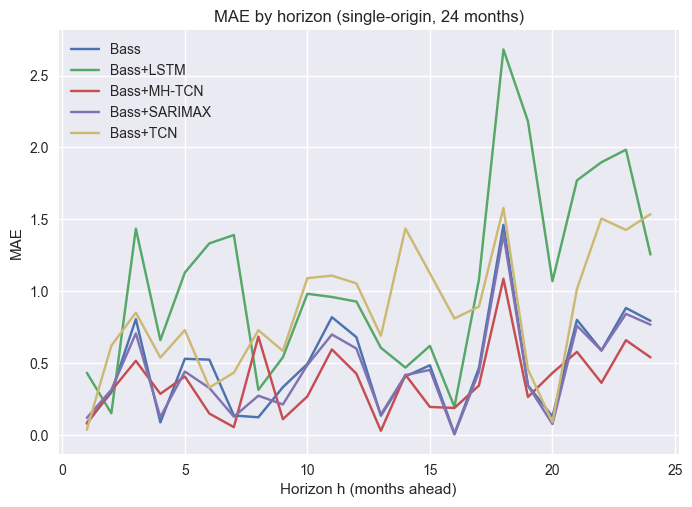

In [112]:
import matplotlib.pyplot as plt

plt.figure()
for model, sub in horizon_metrics.groupby("Model"):
    plt.plot(sub["h"], sub["MAE"], label=model)
plt.title("MAE by horizon (single-origin, 24 months)")
plt.xlabel("Horizon h (months ahead)")
plt.ylabel("MAE")
plt.legend()
plt.show()


In [113]:
pivot = horizon_metrics.pivot(index="h", columns="Model", values="MAE")
pivot["MH-TCN minus SARIMAX"] = pivot["Bass+MH-TCN"] - pivot["Bass+SARIMAX"]
pivot.head(10)


Model,Bass,Bass+LSTM,Bass+MH-TCN,Bass+SARIMAX,Bass+TCN,MH-TCN minus SARIMAX
h,,,,,,
1,0.084996,0.433163,0.079138,0.119447,0.037617,-0.040308
2,0.296837,0.151457,0.308570,0.314817,0.621514,-0.006247
3,0.806217,1.434690,0.516224,0.706787,0.850814,-0.190564
4,0.087762,0.660132,0.286592,0.124536,0.539289,0.162056
5,0.530298,1.129895,0.407575,0.441535,0.729662,-0.033960
6,0.524474,1.333070,0.149466,0.327516,0.330777,-0.178050
7,0.136204,1.390968,0.055297,0.127936,0.434314,-0.072639
8,0.123674,0.314472,0.684773,0.273670,0.729200,0.411103
9,0.332900,0.540921,0.110345,0.212734,0.585062,-0.102389


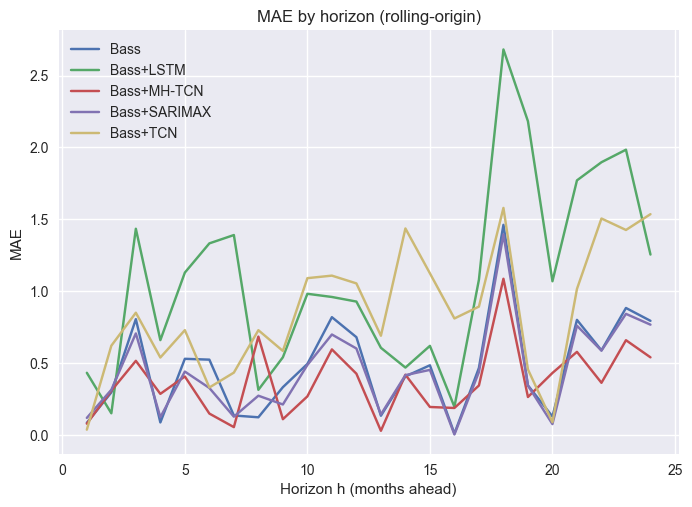

In [114]:
import matplotlib.pyplot as plt

plt.figure()
for m, sub in horizon_metrics.groupby("Model"):
    plt.plot(sub["h"], sub["MAE"], label=m)
plt.title("MAE by horizon (rolling-origin)")
plt.xlabel("Horizon h (months ahead)")
plt.ylabel("MAE")
plt.legend()
plt.show()


### Performance in shock periods

In [115]:
def detect_shocks(resid: pd.Series, window=12, z=2.5):
    r = resid.dropna()
    mu = r.rolling(window, min_periods=6).mean()
    sd = r.rolling(window, min_periods=6).std()
    zscore = (r - mu) / (sd + 1e-8)
    shock_months = zscore[np.abs(zscore) >= z].index
    return shock_months, zscore


In [116]:
shock_months, zscore = detect_shocks(resid_train, window=12, z=2.0)

print("Total shock months detected:", len(shock_months))
print("Shock months (first 10):", list(shock_months[:10]))


Total shock months detected: 3
Shock months (first 10): [Timestamp('2015-08-01 00:00:00'), Timestamp('2016-08-01 00:00:00'), Timestamp('2020-04-01 00:00:00')]


### Quantile RMN

In [117]:
class QuantileLoss(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, preds, target):
        """
        preds: (B, H, Q)
        target: (B, H)
        """
        losses = []
        for i, q in enumerate(self.quantiles):
            e = target - preds[:, :, i]
            losses.append(torch.max((q - 1) * e, q * e).unsqueeze(-1))
        loss = torch.mean(torch.sum(torch.cat(losses, dim=-1), dim=-1))
        return loss


In [118]:
class QuantileMultiHorizonTCN(nn.Module):
    def __init__(self, hidden=32, levels=4, kernel=3, dropout=0.15, horizon=24, quantiles=(0.1, 0.5, 0.9)):
        super().__init__()
        self.horizon = horizon
        self.quantiles = quantiles
        Q = len(quantiles)

        def causal_block(in_ch, out_ch, dilation):
            pad = (kernel - 1) * dilation
            return nn.Sequential(
                nn.ConstantPad1d((pad, 0), 0.0),
                nn.Conv1d(in_ch, out_ch, kernel_size=kernel, dilation=dilation),
                nn.ReLU(),
                nn.Dropout(dropout),
            )

        layers = []
        in_ch = 1
        for i in range(levels):
            layers.append(causal_block(in_ch, hidden, dilation=2 ** i))
            in_ch = hidden
        self.tcn = nn.Sequential(*layers)

        self.head = nn.Sequential(
            nn.Linear(hidden + 2, 64),
            nn.ReLU(),
            nn.Linear(64, Q)
        )

    def forward(self, x_window, future_feats):
        x = x_window.permute(0, 2, 1)       # (B,1,L)
        h = self.tcn(x)                     # (B,hidden,L)
        context = h[:, :, -1]               # (B,hidden)

        B, H, _ = future_feats.shape
        context_rep = context.unsqueeze(1).expand(B, H, context.shape[1])
        z = torch.cat([context_rep, future_feats], dim=-1)

        out = self.head(z)                  # (B,H,Q)
        return out


In [119]:
def train_quantile_tcn(resid_train, lookback=36, horizon=24, quantiles=(0.1,0.5,0.9),
                       epochs=800, batch_size=16, lr=1e-3):

    ds = ResidualMultiHorizonDataset(resid_train, lookback=lookback, horizon=horizon)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = QuantileMultiHorizonTCN(
        hidden=32, levels=4, kernel=3, dropout=0.15,
        horizon=horizon, quantiles=quantiles
    ).to(DEVICE)

    loss_fn = QuantileLoss(quantiles)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for ep in range(epochs):
        model.train()
        total = 0.0
        for xw, ff, yy in dl:
            xw = xw.to(DEVICE)
            ff = ff.to(DEVICE)
            yy = yy.to(DEVICE)

            pred = model(xw, ff)
            loss = loss_fn(pred, yy)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += float(loss.item())

        if (ep + 1) % 200 == 0:
            print(f"Epoch {ep+1}/{epochs} loss={total/len(dl):.6f}")

    return model


In [120]:
@torch.no_grad()
def forecast_quantile_tcn(model, resid_train, start_date, horizon=24, lookback=36):
    model.eval()

    history = resid_train.values.astype(np.float32)
    xw = torch.tensor(history[-lookback:], dtype=torch.float32).view(1, lookback, 1).to(DEVICE)

    idx = pd.date_range(start=pd.to_datetime(start_date), periods=horizon, freq="MS")
    feats = []
    for d in idx:
        ms, mc = month_sin_cos(d.month)
        feats.append([ms, mc])
    feats = torch.tensor(np.array(feats, dtype=np.float32)).unsqueeze(0).to(DEVICE)

    preds = model(xw, feats).cpu().numpy()[0]   # (H,Q)

    out = {}
    for i, q in enumerate(model.quantiles):
        out[q] = pd.Series(preds[:, i], index=idx)

    return out


In [121]:
quantiles = (0.1, 0.5, 0.9)
q_model = train_quantile_tcn(resid_train, lookback=36, horizon=24, quantiles=quantiles)

resid_q_fore = forecast_quantile_tcn(
    q_model,
    resid_train,
    start_date=start_fore_date,
    horizon=24,
    lookback=36
)

# Combine with Bass forecast
y_q_fore = {
    q: yhat_fore.loc[resid_q_fore[q].index] + resid_q_fore[q]
    for q in quantiles
}


Epoch 200/800 loss=0.296116
Epoch 400/800 loss=0.268954
Epoch 600/800 loss=0.255127
Epoch 800/800 loss=0.248018


In [122]:
def interval_coverage(y_true, y_lo, y_hi):
    inside = ((y_true >= y_lo) & (y_true <= y_hi)).mean()
    return float(inside)

coverage_80 = interval_coverage(
    y_true_s,
    y_q_fore[0.1].loc[y_true_s.index],
    y_q_fore[0.9].loc[y_true_s.index]
)

print("80% interval coverage:", coverage_80)


80% interval coverage: 0.3333333333333333


In [123]:
interval_width = (y_q_fore[0.9] - y_q_fore[0.1]).mean()
print("Average interval width:", interval_width)


Average interval width: 0.6427461144824823


In [127]:
quantiles = (0.05, 0.5, 0.95)

q_model_90 = train_quantile_tcn(
    resid_train,
    lookback=36,
    horizon=24,
    quantiles=quantiles,
    epochs=800,
    batch_size=16,
    lr=1e-3
)

# Forecast residual quantiles
resid_q_fore_90 = forecast_quantile_tcn(
    q_model_90,
    resid_train,
    start_date=start_fore_date,
    horizon=24,
    lookback=36
)

# Combine with Bass forecast to get BEV quantiles
y_q_fore_90 = {
    q: yhat_fore.loc[resid_q_fore_90[q].index] + resid_q_fore_90[q]
    for q in quantiles
}

# Now extract and fix monotonicity
idx = y_true_s.index

p05 = y_q_fore_90[0.05].reindex(idx)
p50 = y_q_fore_90[0.5].reindex(idx)
p95 = y_q_fore_90[0.95].reindex(idx)

y = y_true_s.reindex(idx)

# Apply monotonic fix
q_stack = np.vstack([p05.values, p50.values, p95.values]).T  # (H, 3)
q_sorted = np.sort(q_stack, axis=1)

p05_fix = pd.Series(q_sorted[:, 0], index=idx)
p50_fix = pd.Series(q_sorted[:, 1], index=idx)
p95_fix = pd.Series(q_sorted[:, 2], index=idx)

coverage_fix = float(((y >= p05_fix) & (y <= p95_fix)).mean())
print("Coverage after monotonic fix:", coverage_fix)
print("Average interval width:", float((p95_fix - p05_fix).mean()))

Epoch 200/800 loss=0.244931
Epoch 400/800 loss=0.219405
Epoch 600/800 loss=0.210179
Epoch 800/800 loss=0.205418
Coverage after monotonic fix: 0.5416666666666666
Average interval width: 1.1130260055263836


In [129]:
p10_fix = p05_fix
p90_fix = p95_fix

In [130]:
def calibrate_gamma_fine(y_true, q_low, q_med, q_high, target=0.80, g_min=0.5, g_max=5.0, n=5001):
    gammas = np.linspace(g_min, g_max, n)
    best = None
    for g in gammas:
        lo = q_med - g * (q_med - q_low)
        hi = q_med + g * (q_high - q_med)
        cov = float(((y_true >= lo) & (y_true <= hi)).mean())
        avg_width = float((hi - lo).mean())

        # choose closest to target; tie-breaker = narrower interval
        score = abs(cov - target)
        if best is None or score < best["score"] or (score == best["score"] and avg_width < best["avg_width"]):
            best = {"gamma": float(g), "cov": cov, "avg_width": avg_width, "score": score}
    return best

best = calibrate_gamma_fine(y, p10_fix, p50_fix, p90_fix, target=0.80, g_min=0.5, g_max=6.0, n=20001)
best
gamma = best["gamma"]
p10_cal = p50_fix - gamma * (p50_fix - p10_fix)
p90_cal = p50_fix + gamma * (p90_fix - p50_fix)

cov = float(((y >= p10_cal) & (y <= p90_cal)).mean())
print("Coverage:", cov)
print("Avg width:", float((p90_cal - p10_cal).mean()))
print("Gamma:", gamma)



Coverage: 0.7916666666666666
Avg width: 2.178136241514857
Gamma: 1.9569500000000002


In [131]:
def calibrate_two_sided(y_true, q_low, q_med, q_high, target=0.80,
                        g1_range=np.linspace(0.5, 3.0, 126),
                        g2_range=np.linspace(0.5, 5.0, 226)):
    best = None
    for g_low in g1_range:
        lo = q_med - g_low * (q_med - q_low)
        for g_high in g2_range:
            hi = q_med + g_high * (q_high - q_med)
            cov = float(((y_true >= lo) & (y_true <= hi)).mean())
            avg_width = float((hi - lo).mean())
            score = abs(cov - target)
            if best is None or score < best["score"] or (score == best["score"] and avg_width < best["avg_width"]):
                best = {"g_low": float(g_low), "g_high": float(g_high), "cov": cov, "avg_width": avg_width, "score": score}
    return best

best2 = calibrate_two_sided(y, p10_fix, p50_fix, p90_fix, target=0.80)
best2
g_low = best2["g_low"]
g_high = best2["g_high"]

p10_cal2 = p50_fix - g_low  * (p50_fix - p10_fix)
p90_cal2 = p50_fix + g_high * (p90_fix - p50_fix)

cov2 = float(((y >= p10_cal2) & (y <= p90_cal2)).mean())
print("Coverage:", cov2)
print("Avg width:", float((p90_cal2 - p10_cal2).mean()))
print("g_low, g_high:", g_low, g_high)


Coverage: 0.7916666666666666
Avg width: 1.221240474184354
g_low, g_high: 0.5 1.96


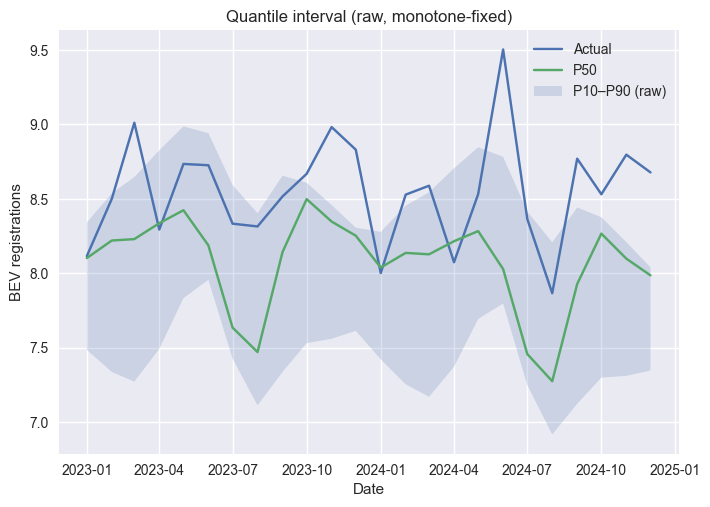

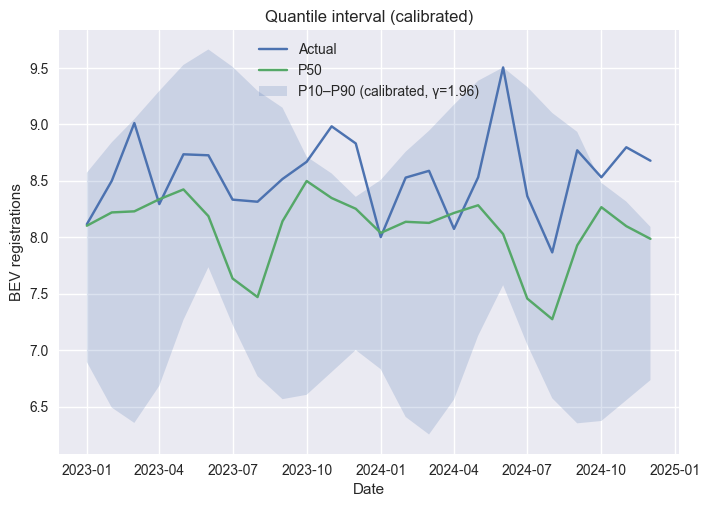

In [132]:
# BEFORE (monotone-fixed)
plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(p50_fix.index, p50_fix.values, label="P50")
plt.fill_between(idx, p10_fix.values, p90_fix.values, alpha=0.2, label="P10–P90 (raw)")
plt.title("Quantile interval (raw, monotone-fixed)")
plt.xlabel("Date"); plt.ylabel("BEV registrations")
plt.legend(); plt.show()

# AFTER calibration (scaled band)
plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(p50_fix.index, p50_fix.values, label="P50")
plt.fill_between(idx, p10_cal.values, p90_cal.values, alpha=0.2, label=f"P10–P90 (calibrated, γ={gamma:.2f})")
plt.title("Quantile interval (calibrated)")
plt.xlabel("Date"); plt.ylabel("BEV registrations")
plt.legend(); plt.show()


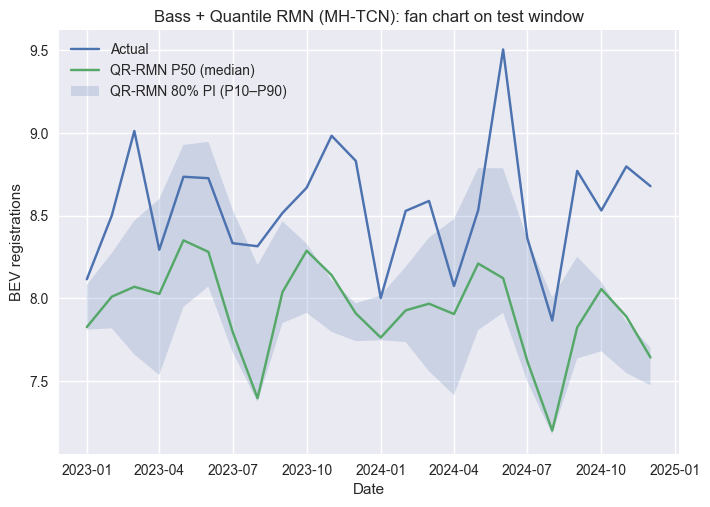

In [133]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Align series
idx = y_true_s.index
p10 = y_q_fore[0.1].reindex(idx)
p50 = y_q_fore[0.5].reindex(idx)
p90 = y_q_fore[0.9].reindex(idx)
y   = y_true_s.reindex(idx)

plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(p50.index, p50.values, label="QR-RMN P50 (median)")
plt.fill_between(idx, p10.values, p90.values, alpha=0.2, label="QR-RMN 80% PI (P10–P90)")
plt.title("Bass + Quantile RMN (MH-TCN): fan chart on test window")
plt.xlabel("Date")
plt.ylabel("BEV registrations")
plt.legend()
plt.show()


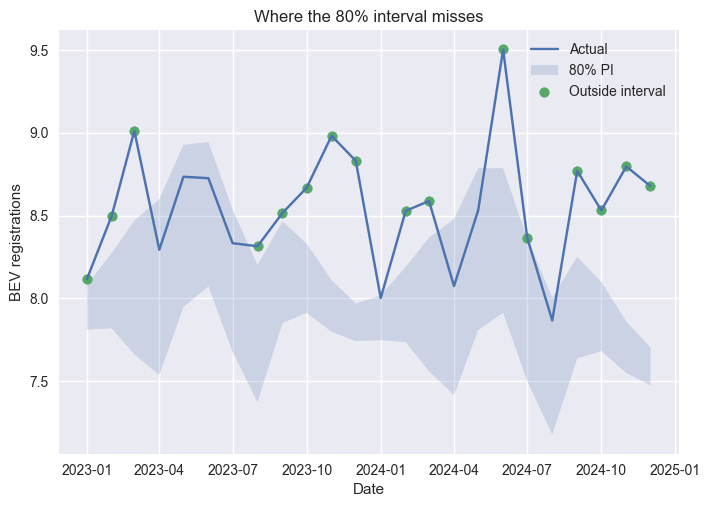

Outside count: 16 out of 24
Coverage: 0.3333333333333333


In [134]:
outside = (y < p10) | (y > p90)

plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.fill_between(idx, p10.values, p90.values, alpha=0.2, label="80% PI")
plt.scatter(y.index[outside], y.values[outside], marker="o", label="Outside interval")
plt.title("Where the 80% interval misses")
plt.xlabel("Date")
plt.ylabel("BEV registrations")
plt.legend()
plt.show()

print("Outside count:", int(outside.sum()), "out of", len(outside))
print("Coverage:", float((~outside).mean()))


In [135]:
quantiles = (0.05, 0.5, 0.95)

q_model_90 = train_quantile_tcn(
    resid_train,
    lookback=36,
    horizon=24,
    quantiles=quantiles,
    epochs=800,
    batch_size=16,
    lr=1e-3
)


Epoch 200/800 loss=0.251054
Epoch 400/800 loss=0.223451
Epoch 600/800 loss=0.208860
Epoch 800/800 loss=0.203205


In [136]:
resid_q_fore_90 = forecast_quantile_tcn(
    q_model_90,
    resid_train,
    start_date=start_fore_date,
    horizon=24,
    lookback=36
)

# Combine with Bass forecast to get BEV quantiles
y_q_fore_90 = {
    q: yhat_fore.loc[resid_q_fore_90[q].index] + resid_q_fore_90[q]
    for q in quantiles
}


In [137]:
idx = y_true_s.index

p05 = y_q_fore_90[0.05].reindex(idx)
p50 = y_q_fore_90[0.5].reindex(idx)
p95 = y_q_fore_90[0.95].reindex(idx)

q_stack = np.vstack([p05.values, p50.values, p95.values]).T  # (H,3)
q_sorted = np.sort(q_stack, axis=1)

p05_fix = pd.Series(q_sorted[:,0], index=idx)
p50_fix = pd.Series(q_sorted[:,1], index=idx)
p95_fix = pd.Series(q_sorted[:,2], index=idx)


In [138]:
y = y_true_s.reindex(idx)

coverage_90 = float(((y >= p05_fix) & (y <= p95_fix)).mean())
avg_width_90 = float((p95_fix - p05_fix).mean())

print("90% interval coverage (P05–P95):", coverage_90)
print("Average interval width:", avg_width_90)
print("Covered points:", int(((y >= p05_fix) & (y <= p95_fix)).sum()), "/", len(y))


90% interval coverage (P05–P95): 0.625
Average interval width: 0.860012563255926
Covered points: 15 / 24


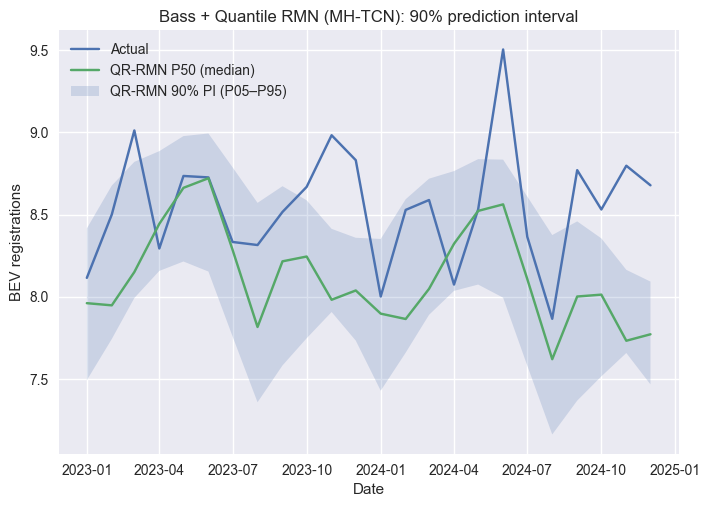

In [139]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(p50_fix.index, p50_fix.values, label="QR-RMN P50 (median)")
plt.fill_between(idx, p05_fix.values, p95_fix.values, alpha=0.2, label="QR-RMN 90% PI (P05–P95)")
plt.title("Bass + Quantile RMN (MH-TCN): 90% prediction interval")
plt.xlabel("Date")
plt.ylabel("BEV registrations")
plt.legend()
plt.show()


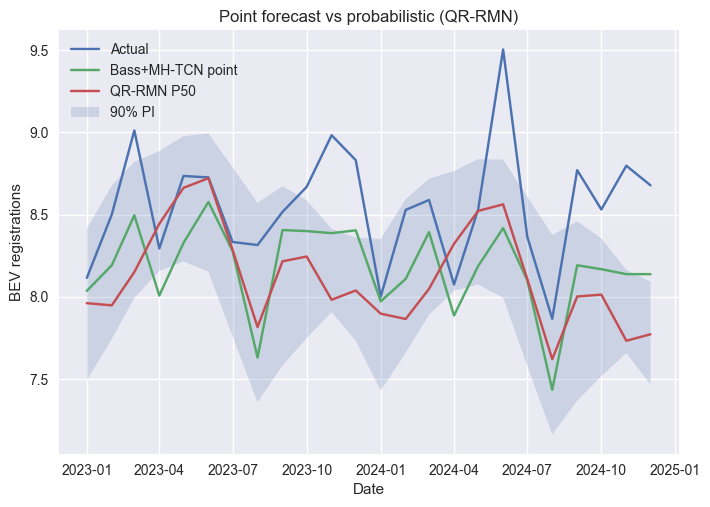

In [140]:
plt.figure()
plt.plot(y.index, y.values, label="Actual")
plt.plot(y_tcn_mh_s.reindex(idx).index, y_tcn_mh_s.reindex(idx).values, label="Bass+MH-TCN point")
plt.plot(p50_fix.index, p50_fix.values, label="QR-RMN P50")
plt.fill_between(idx, p05_fix.values, p95_fix.values, alpha=0.2, label="90% PI")
plt.title("Point forecast vs probabilistic (QR-RMN)")
plt.xlabel("Date")
plt.ylabel("BEV registrations")
plt.legend()
plt.show()


In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_p50 = mean_absolute_error(y_true_s, p50_fix)
rmse_p50 = np.sqrt(mean_squared_error(y_true_s, p50_fix))

print("P50 MAE:", mae_p50)
print("P50 RMSE:", rmse_p50)

P50 MAE: 0.4637406415300584
P50 RMSE: 0.5732081078749958


In [142]:
coverage_90 = float(((y_true_s >= p50_fix) & (y_true_s <= p95_fix)).mean())
print("90% interval coverage:", coverage_90)


90% interval coverage: 0.5416666666666666


In [143]:
avg_width = float((p95_fix - p05_fix).mean())
print("Average interval width:", avg_width)


Average interval width: 0.860012563255926


In [144]:
def pinball_loss(y, yhat, q):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    e = y - yhat
    return np.mean(np.maximum(q*e, (q-1)*e))

pinball_05 = pinball_loss(y_true_s, p05_fix, 0.05)
pinball_50 = pinball_loss(y_true_s, p50_fix, 0.50)
pinball_95 = pinball_loss(y_true_s, p95_fix, 0.95)

pinball_avg = np.mean([pinball_05, pinball_50, pinball_95])

print("Pinball loss (avg):", pinball_avg)


Pinball loss (avg): 0.14289952010090726


### FINAL RESULTS

In [145]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mae_rmse(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


In [146]:
# Bass
mae_bass, rmse_bass = mae_rmse(y_true_s, y_bass_s)

# Bass + SARIMAX
mae_sar, rmse_sar = mae_rmse(y_true_s, y_sar_s)

# Bass + MH-TCN (point)
mae_tcn, rmse_tcn = mae_rmse(y_true_s, y_tcn_mh_s)


In [147]:
#MAE / RMSE on the median (P50)
mae_q50, rmse_q50 = mae_rmse(y_true_s, p50_fix)
# 90% coverage
coverage_90 = float(((y_true_s >= p05_fix) & (y_true_s <= p95_fix)).mean())

# avg internal width
avg_width_90 = float((p95_fix - p05_fix).mean())

#pinball loss avg
def pinball_loss(y, yhat, q):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    e = y - yhat
    return np.mean(np.maximum(q * e, (q - 1) * e))

pinball_05 = pinball_loss(y_true_s, p05_fix, 0.05)
pinball_50 = pinball_loss(y_true_s, p50_fix, 0.50)
pinball_95 = pinball_loss(y_true_s, p95_fix, 0.95)

pinball_avg = np.mean([pinball_05, pinball_50, pinball_95])



In [148]:
import pandas as pd

results_final = pd.DataFrame([
    {
        "Model": "Bass (mean only)",
        "MAE": mae_bass,
        "RMSE": rmse_bass,
        "90% Coverage": "—",
        "Avg Width": "—",
        "Pinball Loss": "—",
    },
    {
        "Model": "Bass + SARIMAX residual",
        "MAE": mae_sar,
        "RMSE": rmse_sar,
        "90% Coverage": "—",
        "Avg Width": "—",
        "Pinball Loss": "—",
    },
    {
        "Model": "Bass + MH-TCN residual (point)",
        "MAE": mae_tcn,
        "RMSE": rmse_tcn,
        "90% Coverage": "—",
        "Avg Width": "—",
        "Pinball Loss": "—",
    },
    {
        "Model": "Bass + Quantile RMN (P05–P50–P95)",
        "MAE": mae_q50,
        "RMSE": rmse_q50,
        "90% Coverage": coverage_90,
        "Avg Width": avg_width_90,
        "Pinball Loss": pinball_avg,
    }
])

results_final


,Model,MAE,RMSE,90% Coverage,Avg Width,Pinball Loss
0,Bass (mean only),0.476213,0.582629,—,—,—
1,Bass + SARIMAX residual,0.444475,0.541680,—,—,—
2,Bass + MH-TCN residual (point),0.374711,0.444122,—,—,—
3,Bass + Quantile RMN (P05–P50–P95),0.463741,0.573208,0.625,0.860013,0.1429


### DYNAMIC MARKET POTENTIAL

In [149]:
import numpy as np
import pandas as pd

def to_monthly_series(df, date_col="date", value_col="BEV"):
    s = df.copy()
    s[date_col] = pd.to_datetime(s[date_col])
    s = s.set_index(date_col)[value_col].asfreq("MS")
    return s

def make_transforms(y_raw: pd.Series):
    y_log = np.log1p(y_raw)
    return y_raw, y_log


In [150]:
from scipy.optimize import least_squares

def bass_sales(t, p, q, M):
    """
    Bass model expected sales/adoptions at time index t (0..T-1),
    assuming fixed market potential M and initial cumulative adopters N(0)=0.
    """
    # cumulative fraction adopted F(t) under Bass
    # f(t) = (p+q)^2/p * exp(-(p+q)t) / (1 + (q/p)exp(-(p+q)t))^2
    # sales = M * f(t)
    exp_term = np.exp(-(p + q) * t)
    denom = (1 + (q / p) * exp_term) ** 2
    f = ((p + q) ** 2 / p) * exp_term / denom
    return M * f

def dyn_market_bass_sales(t, p, q, M0, gamma):
    """
    Dynamic market potential: M(t) = M0 * exp(gamma * t)
    Sales(t) = M(t) * f_bass(t; p,q)
    """
    Mt = M0 * np.exp(gamma * t)
    exp_term = np.exp(-(p + q) * t)
    denom = (1 + (q / p) * exp_term) ** 2
    f = ((p + q) ** 2 / p) * exp_term / denom
    return Mt * f


In [151]:
def fit_bass_nls(y: pd.Series):
    y = y.dropna()
    t = np.arange(len(y), dtype=np.float64)
    yv = y.values.astype(np.float64)

    # initial guesses
    M0 = max(yv.sum()*1.2, yv.max()*12)  # rough
    x0 = np.array([0.01, 0.10, M0], dtype=np.float64)  # p,q,M

    # bounds: p,q positive; M positive
    lb = np.array([1e-6, 1e-6, 1e-6])
    ub = np.array([1.0, 3.0, 1e12])

    def resid(theta):
        p,q,M = theta
        pred = bass_sales(t, p,q,M)
        return pred - yv

    res = least_squares(resid, x0=x0, bounds=(lb, ub), method="trf")
    p,q,M = res.x
    yhat = pd.Series(bass_sales(t, p,q,M), index=y.index)
    return {"p":p, "q":q, "M":M, "yhat":yhat, "resid":(y - yhat), "opt":res}

def fit_dyn_market_bass_nls(y: pd.Series):
    y = y.dropna()
    t = np.arange(len(y), dtype=np.float64)
    yv = y.values.astype(np.float64)

    # initial guesses
    M0_guess = max(yv.sum()*1.1, yv.max()*12)
    x0 = np.array([0.01, 0.10, M0_guess, 0.001], dtype=np.float64)  # p,q,M0,gamma

    # bounds: p,q positive; M0 positive; gamma can be small positive (market expands)
    lb = np.array([1e-6, 1e-6, 1e-6, 0.0])
    ub = np.array([1.0, 3.0, 1e12, 0.05])  # gamma upper bound ~5% per month (very generous)

    def resid(theta):
        p,q,M0,gamma = theta
        pred = dyn_market_bass_sales(t, p,q,M0,gamma)
        return pred - yv

    res = least_squares(resid, x0=x0, bounds=(lb, ub), method="trf")
    p,q,M0,gamma = res.x
    yhat = pd.Series(dyn_market_bass_sales(t, p,q,M0,gamma), index=y.index)
    return {"p":p, "q":q, "M0":M0, "gamma":gamma, "yhat":yhat, "resid":(y - yhat), "opt":res}


In [152]:
# y_raw is your monthly BEV series (pd.Series with MS index)
y_raw, y_log = make_transforms(ts)

# ---- RAW ----
bass_raw = fit_bass_nls(y_raw)
dyn_raw  = fit_dyn_market_bass_nls(y_raw)

# ---- LOG ----
bass_log = fit_bass_nls(y_log)
dyn_log  = fit_dyn_market_bass_nls(y_log)

print("RAW Bass:", {k:bass_raw[k] for k in ["p","q","M"]})
print("RAW Dyn:",  {k:dyn_raw[k]  for k in ["p","q","M0","gamma"]})

print("LOG Bass:", {k:bass_log[k] for k in ["p","q","M"]})
print("LOG Dyn:",  {k:dyn_log[k]  for k in ["p","q","M0","gamma"]})


RAW Bass: {'p': np.float64(0.00022236829394976473), 'q': np.float64(0.034350259957899795), 'M': np.float64(871000.8972031769)}
RAW Dyn: {'p': np.float64(0.002418836857174489), 'q': np.float64(0.043294877096298715), 'M0': np.float64(4965.478965845102), 'gamma': np.float64(0.04999999999998112)}
LOG Bass: {'p': np.float64(0.0017403205629453143), 'q': np.float64(0.01328399542139879), 'M': np.float64(2089.11739218212)}
LOG Dyn: {'p': np.float64(0.0017403187871616796), 'q': np.float64(0.013283961775084072), 'M0': np.float64(2089.122404878718), 'gamma': np.float64(1.0515410808627888e-12)}


In [153]:
def forecast_bass(params, start_index: pd.DatetimeIndex, H: int, freq="MS"):
    # params is output dict from fit_bass_nls
    p,q,M = params["p"], params["q"], params["M"]
    T = len(params["yhat"])
    t_future = np.arange(T, T+H, dtype=np.float64)
    idx_future = pd.date_range(start=start_index, periods=H, freq=freq)
    y_fore = pd.Series(bass_sales(t_future, p,q,M), index=idx_future)
    return y_fore

def forecast_dyn_bass(params, start_index: pd.DatetimeIndex, H: int, freq="MS"):
    p,q,M0,gamma = params["p"], params["q"], params["M0"], params["gamma"]
    T = len(params["yhat"])
    t_future = np.arange(T, T+H, dtype=np.float64)
    idx_future = pd.date_range(start=start_index, periods=H, freq=freq)
    y_fore = pd.Series(dyn_market_bass_sales(t_future, p,q,M0,gamma), index=idx_future)
    return y_fore


# EXPERIMENTAL DESIGN

In [244]:
COUNTRIES = ["Italy", "Norway"]
SCALES = ["raw", "log"]
DIFFUSION_MODELS = ["Bass", "DynamicBass"]
RESIDUAL_MODELS = ["None", "SARIMAX", "MH-TCN"]

TRAIN_END = "2022-12-01"
H = 24


In [245]:
def load_country_series(country):
    if country == "Italy":
        path = "BEV Registrations.xlsx"
    elif country == "Norway":
        path = "BEV Registrations Norway.xlsx"
    else:
        raise ValueError("Unknown country")

    df = pd.read_excel(path)

    # Rename columns to standard names
    df = df.rename(columns={
        "Año": "year",
        "Mes": "month",
        "BEV registrations": "bev"
    })

    # Build date column (monthly start)
    df["date"] = pd.to_datetime(
        df["year"].astype(str) + "-" +
        df["month"].astype(str).str.zfill(2) + "-01"
    )

    # Sort chronologically
    df = df.sort_values("date")

    # Create monthly series
    ts = (
        df
        .set_index("date")["bev"]
        .asfreq("MS")
        .astype(float)
    )

    return ts


In [246]:
ts_italy = load_country_series("Italy")
ts_norway = load_country_series("Norway")

print(ts_italy.head())
print(ts_italy.tail())

print(ts_norway.head())
print(ts_norway.tail())

print(ts_italy.index.freq)
print(ts_norway.index.freq)


date
2014-01-01     34.0
2014-02-01     63.0
2014-03-01    132.0
2014-04-01     47.0
2014-05-01    130.0
Freq: MS, Name: bev, dtype: float64
date
2025-08-01     3306.0
2025-09-01     7190.0
2025-10-01     6331.0
2025-11-01    15304.0
2025-12-01    12078.0
Freq: MS, Name: bev, dtype: float64
date
2014-01-01    1078.0
2014-02-01    1333.0
2014-03-01    2696.0
2014-04-01    1218.0
2014-05-01    1290.0
Freq: MS, Name: bev, dtype: float64
date
2025-08-01    13482.0
2025-09-01    14084.0
2025-10-01    10852.0
2025-11-01    19427.0
2025-12-01    34346.0
Freq: MS, Name: bev, dtype: float64
<MonthBegin>
<MonthBegin>


In [247]:
def prepare_series(ts):
    #ts = ts.asfreq("MS")
    ts_raw = ts.copy()
    ts_log = np.log1p(ts_raw)
    return {
        "raw": ts_raw,
        "log": ts_log
    }


In [248]:
def fit_diffusion_bass(y, train_end, H):
    train = y.loc[:train_end]
    params = fit_bass_nls(train)
    yhat_train = params["yhat"]
    yhat_fore = forecast_bass(params, start_index=train.index[-1] + pd.offsets.MonthBegin(1), H=H)
    return yhat_train, yhat_fore


In [249]:
def fit_diffusion_dynbass(y, train_end, H):
    train = y.loc[:train_end]
    params = fit_dyn_market_bass_nls(train)
    yhat_train = params["yhat"]
    yhat_fore = forecast_dyn_bass(params, start_index=train.index[-1] + pd.offsets.MonthBegin(1), H=H)
    return yhat_train, yhat_fore


In [250]:

def sarimax_residual_forecast(resid_train, H):
    model = SARIMAX(resid_train, order=(1,0,1), seasonal_order=(1,0,1,12))
    res = model.fit(disp=False)
    return res.forecast(H)


In [259]:
def mhtcn_residual_forecast(resid_train, H):
    model = train_multi_tcn(resid_train, lookback=36, horizon=H)
    return forecast_multi_tcn(model, resid_train, start_date=(pd.to_datetime(TRAIN_END) + pd.DateOffset(months=1)).to_period("M").to_timestamp(),horizon=H, lookback=LOOKBACK)


In [260]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

def run_experiment(ts, scale, diffusion, residual):
    y = ts[scale]

    # True test
    test = y.loc[pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1):].iloc[:H]

    # --- Diffusion ---
    if diffusion == "Bass":
        yhat_train, yhat_fore = fit_diffusion_bass(y, TRAIN_END, H)
    else:
        yhat_train, yhat_fore = fit_diffusion_dynbass(y, TRAIN_END, H)

    # --- Residuals ---
    if residual == "None":
        y_pred = yhat_fore

    else:
        resid_train = (y.loc[yhat_train.index] - yhat_train).dropna()

        if residual == "SARIMAX":
            resid_fore = sarimax_residual_forecast(resid_train, H)

        else:
            resid_fore = mhtcn_residual_forecast(resid_train, H)

        y_pred = yhat_fore + resid_fore

    
    y_true = test
    y_pred = y_pred  # already on raw scale

    # --- Metrics ---
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse


In [261]:
results = []

for country in COUNTRIES:
    ts = load_country_series(country)  # <- your loader
    #ts = df.set_index("date")["bev"].asfreq("MS")

    series = prepare_series(ts)

    for scale in SCALES:
        for diff in DIFFUSION_MODELS:
            for res in RESIDUAL_MODELS:

                
                mae, rmse = run_experiment(series, scale, diff, res)

                results.append({
                    "Country": country,
                    "Scale": scale,
                    "Diffusion": diff,
                    "Residual": res,
                    "MAE": mae,
                    "RMSE": rmse
                })

df_results = pd.DataFrame(results)
df_results


Epoch 200/800 loss=1070727.250000
Epoch 400/800 loss=1060710.791667
Epoch 600/800 loss=1043193.270833
Epoch 800/800 loss=1027736.562500
Epoch 200/800 loss=1057087.437500
Epoch 400/800 loss=1053173.687500
Epoch 600/800 loss=1046495.250000
Epoch 800/800 loss=1034731.666667
Epoch 200/800 loss=0.161606
Epoch 400/800 loss=0.147063
Epoch 600/800 loss=0.141945
Epoch 800/800 loss=0.140607
Epoch 200/800 loss=0.158261
Epoch 400/800 loss=0.146873
Epoch 600/800 loss=0.142981
Epoch 800/800 loss=0.141287
Epoch 200/800 loss=4942746.583333
Epoch 400/800 loss=4935857.000000
Epoch 600/800 loss=4926777.000000
Epoch 800/800 loss=4909459.833333
Epoch 200/800 loss=4939695.500000
Epoch 400/800 loss=4938129.333333
Epoch 600/800 loss=4928856.500000
Epoch 800/800 loss=4915510.666667
Epoch 200/800 loss=0.041250
Epoch 400/800 loss=0.039288
Epoch 600/800 loss=0.038583
Epoch 800/800 loss=0.038521
Epoch 200/800 loss=0.041593
Epoch 400/800 loss=0.039065
Epoch 600/800 loss=0.038567
Epoch 800/800 loss=0.038439


,Country,Scale,Diffusion,Residual,MAE,RMSE
0,Italy,raw,Bass,None,4403.397922,5014.240868
1,Italy,raw,Bass,SARIMAX,4464.505257,4886.125621
2,Italy,raw,Bass,MH-TCN,4258.564211,4884.699708
3,Italy,raw,DynamicBass,None,3882.356394,4560.693445
4,Italy,raw,DynamicBass,SARIMAX,3960.193488,4432.426927
5,Italy,raw,DynamicBass,MH-TCN,3009.568106,3793.622061
6,Italy,log,Bass,None,1.366981,1.475512
7,Italy,log,Bass,SARIMAX,1.198393,1.342000
8,Italy,log,Bass,MH-TCN,1.090854,1.206286
9,Italy,log,DynamicBass,None,1.368890,1.477487


In [262]:
df_results.sort_values(["Country", "Scale", "MAE"])


,Country,Scale,Diffusion,Residual,MAE,RMSE
11,Italy,log,DynamicBass,MH-TCN,1.077276,1.191131
8,Italy,log,Bass,MH-TCN,1.090854,1.206286
7,Italy,log,Bass,SARIMAX,1.198393,1.342000
10,Italy,log,DynamicBass,SARIMAX,1.200112,1.343872
6,Italy,log,Bass,None,1.366981,1.475512
9,Italy,log,DynamicBass,None,1.368890,1.477487
5,Italy,raw,DynamicBass,MH-TCN,3009.568106,3793.622061
3,Italy,raw,DynamicBass,None,3882.356394,4560.693445
4,Italy,raw,DynamicBass,SARIMAX,3960.193488,4432.426927
2,Italy,raw,Bass,MH-TCN,4258.564211,4884.699708


In [172]:
print("resid_fore min/max:", float(resid_fore.min()), float(resid_fore.max()))




resid_fore min/max: -0.1499966074710925 0.19695824323022434


In [263]:
table_raw_main = (
    df_results
    .query("Scale == 'raw'")
    .sort_values(["Country", "MAE"])
    .reset_index(drop=True)
)

table_raw_main


,Country,Scale,Diffusion,Residual,MAE,RMSE
0,Italy,raw,DynamicBass,MH-TCN,3009.568106,3793.622061
1,Italy,raw,DynamicBass,None,3882.356394,4560.693445
2,Italy,raw,DynamicBass,SARIMAX,3960.193488,4432.426927
3,Italy,raw,Bass,MH-TCN,4258.564211,4884.699708
4,Italy,raw,Bass,None,4403.397922,5014.240868
5,Italy,raw,Bass,SARIMAX,4464.505257,4886.125621
6,Norway,raw,Bass,MH-TCN,9809.937416,10400.597507
7,Norway,raw,DynamicBass,MH-TCN,10185.087736,10779.519787
8,Norway,raw,Bass,None,10734.406909,11334.550954
9,Norway,raw,Bass,SARIMAX,10738.891866,11839.783279


In [256]:
table_log_robust = (
    df_results
    .query("Scale == 'log'")
    .sort_values(["Country", "MAE"])
    .reset_index(drop=True)
)

table_log_robust


,Country,Scale,Diffusion,Residual,MAE,RMSE
0,Italy,log,DynamicBass,MH-TCN,1.047080,1.169707
1,Italy,log,Bass,MH-TCN,1.062816,1.180075
2,Italy,log,Bass,SARIMAX,1.198393,1.342000
3,Italy,log,DynamicBass,SARIMAX,1.200112,1.343872
4,Italy,log,Bass,None,1.366981,1.475512
5,Italy,log,DynamicBass,None,1.368890,1.477487
6,Norway,log,Bass,None,0.702112,0.821442
7,Norway,log,Bass,MH-TCN,0.706405,0.802410
8,Norway,log,DynamicBass,None,0.707861,0.826463
9,Norway,log,DynamicBass,MH-TCN,0.714148,0.813959


In [257]:
def rel_improvement(df, country, scale):
    base = df.query(
        "Country == @country and Scale == @scale and Diffusion == 'Bass' and Residual == 'None'"
    )["MAE"].values[0]

    out = (
        df.query("Country == @country and Scale == @scale")
        .assign(Improvement=lambda x: 100*(base - x["MAE"])/base)
        .sort_values("Improvement", ascending=False)
    )
    return out[["Diffusion", "Residual", "MAE", "Improvement"]]

rel_it_raw = rel_improvement(df_results, "Italy", "raw")
rel_no_raw = rel_improvement(df_results, "Norway", "raw")

rel_it_raw, rel_no_raw


(     Diffusion Residual          MAE  Improvement
 5  DynamicBass   MH-TCN  1662.932945    62.235233
 3  DynamicBass     None  3882.356394    11.832715
 4  DynamicBass  SARIMAX  3960.193488    10.065055
 0         Bass     None  4403.397922     0.000000
 2         Bass   MH-TCN  4416.005229    -0.286309
 1         Bass  SARIMAX  4464.505257    -1.387731,
       Diffusion Residual           MAE  Improvement
 14         Bass   MH-TCN   9863.588067     8.112408
 17  DynamicBass   MH-TCN  10157.652362     5.372952
 12         Bass     None  10734.406909     0.000000
 13         Bass  SARIMAX  10738.891866    -0.041781
 15  DynamicBass     None  10744.099053    -0.090290
 16  DynamicBass  SARIMAX  10748.453703    -0.130858)

## GRAPHS REPLICATION

In [188]:
ts_italy = load_country_series("Italy")
ts_norway = load_country_series("Norway")
TRAIN_END = "2022-12-01"
H = 24


In [ ]:
import pandas as pd
import numpy as np

def make_train_test(ts, train_end, H):
    train = ts.loc[:train_end]
    test = ts.loc[pd.to_datetime(train_end) + pd.offsets.MonthBegin(1):].iloc[:H]
    return train, test

train_raw, test_raw = make_train_test(ts_norway, TRAIN_END, H)
y_true_raw = test_raw.copy()


In [229]:
# Fit diffusion models on training set
bass_fit = fit_bass_nls(train_raw)
dyn_fit  = fit_dyn_market_bass_nls(train_raw)

yhat_train_bass = bass_fit["yhat"]
yhat_train_dyn  = dyn_fit["yhat"]

# Forecast start date = month after TRAIN_END
start_fore = train_raw.index[-1] + pd.offsets.MonthBegin(1)

y_bass_fore = forecast_bass(bass_fit, start_index=start_fore, H=H)
y_dyn_fore  = forecast_dyn_bass(dyn_fit,  start_index=start_fore, H=H)


In [230]:
# Residuals on training window (raw)
resid_train_raw_bass = (train_raw - yhat_train_bass.reindex(train_raw.index)).dropna()
resid_train_raw_dyn  = (train_raw - yhat_train_dyn.reindex(train_raw.index)).dropna()
resid_train_raw = resid_train_raw_bass


In [231]:
LOOKBACK = 36

# Train MH-TCN on Bass residuals and forecast residuals
tcn_bass = train_multi_tcn(resid_train_raw_bass, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
resid_fore_bass = forecast_multi_tcn(tcn_bass, resid_train_raw_bass, start_date=start_fore, horizon=H, lookback=LOOKBACK)

# Train MH-TCN on DynamicBass residuals and forecast residuals
tcn_dyn = train_multi_tcn(resid_train_raw_dyn, lookback=LOOKBACK, horizon=H, epochs=800, batch_size=16, lr=1e-3)
resid_fore_dyn = forecast_multi_tcn(tcn_dyn, resid_train_raw_dyn, start_date=start_fore, horizon=H, lookback=LOOKBACK)



Epoch 200/800 loss=4942034.250000
Epoch 400/800 loss=4937083.416667
Epoch 600/800 loss=4931701.250000
Epoch 800/800 loss=4913989.333333
Epoch 200/800 loss=4940494.500000
Epoch 400/800 loss=4936684.833333
Epoch 600/800 loss=4928883.000000
Epoch 800/800 loss=4918485.166667


In [232]:
y_bass_mh_fore = y_bass_fore + resid_fore_bass
y_dyn_mh_fore  = y_dyn_fore  + resid_fore_dyn


In [233]:
sarimax_bass = fit_residual_sarimax(resid_train_raw_bass)
sarimax_dyn  = fit_residual_sarimax(resid_train_raw_dyn)

resid_fore_sarimax_bass = sarimax_residual_forecast(resid_train_raw_bass, H)
resid_fore_sarimax_dyn  = sarimax_residual_forecast(resid_train_raw_dyn, H)

y_bass_sarimax_fore = y_bass_fore + resid_fore_sarimax_bass
y_dyn_sarimax_fore  = y_dyn_fore  + resid_fore_sarimax_dyn

In [234]:
def abs_error_by_horizon(y_true, y_pred):
    y_true = y_true.reindex(y_pred.index)
    return np.abs(y_true.values - y_pred.values)  # length H

mae_by_horizon_bass = abs_error_by_horizon(y_true_raw, y_bass_fore)
mae_by_horizon_mh_tcn = abs_error_by_horizon(y_true_raw, y_bass_mh_fore)
mae_by_horizon_dyn_mh = abs_error_by_horizon(y_true_raw, y_dyn_mh_fore)


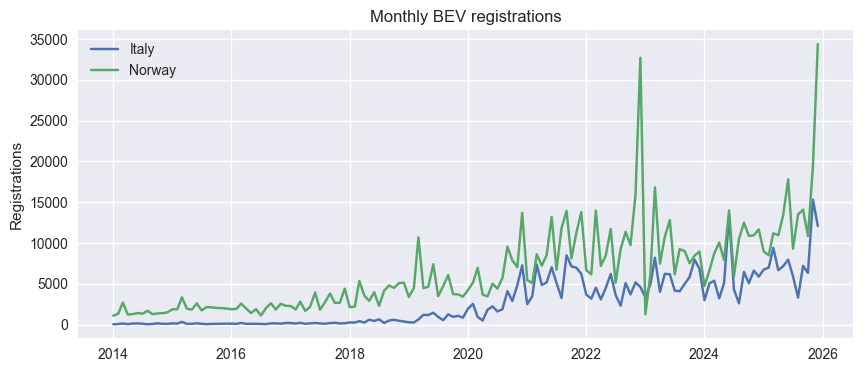

In [182]:
plt.figure(figsize=(10,4))
plt.plot(ts_italy, label="Italy")
plt.plot(ts_norway, label="Norway")
plt.title("Monthly BEV registrations")
plt.ylabel("Registrations")
plt.legend()
plt.show()


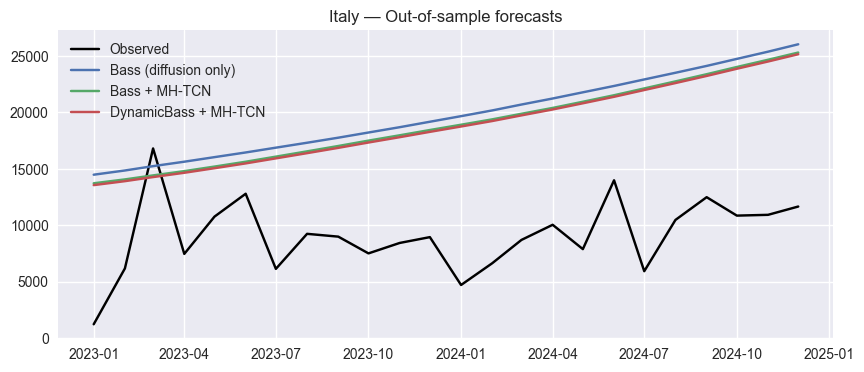

In [237]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_true_raw.index, y_true_raw.values, label="Observed", color="black")
plt.plot(y_bass_fore.index, y_bass_fore.values, label="Bass (diffusion only)")
plt.plot(y_bass_mh_fore.index, y_bass_mh_fore.values, label="Bass + MH-TCN")
plt.plot(y_dyn_mh_fore.index, y_dyn_mh_fore.values, label="DynamicBass + MH-TCN")
plt.title("Italy — Out-of-sample forecasts")
plt.legend()
plt.show()



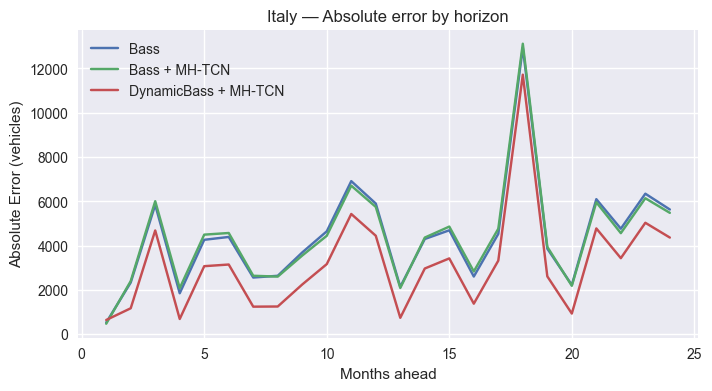

In [197]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, H+1), mae_by_horizon_bass, label="Bass")
plt.plot(np.arange(1, H+1), mae_by_horizon_mh_tcn, label="Bass + MH-TCN")
plt.plot(np.arange(1, H+1), mae_by_horizon_dyn_mh, label="DynamicBass + MH-TCN")
plt.title("Italy — Absolute error by horizon")
plt.xlabel("Months ahead")
plt.ylabel("Absolute Error (vehicles)")
plt.legend()
plt.show()



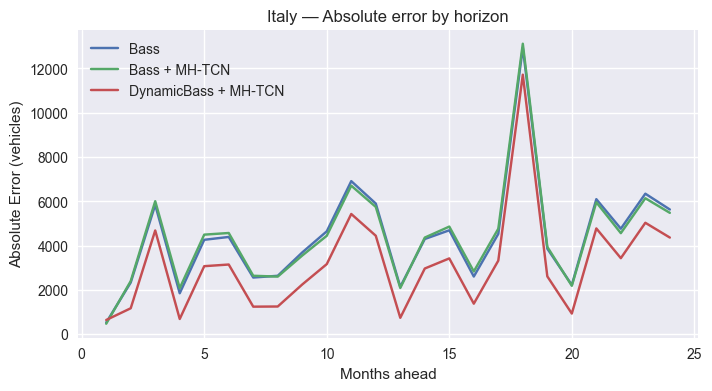

In [198]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, H+1), mae_by_horizon_bass, label="Bass")
plt.plot(np.arange(1, H+1), mae_by_horizon_mh_tcn, label="Bass + MH-TCN")
plt.plot(np.arange(1, H+1), mae_by_horizon_dyn_mh, label="DynamicBass + MH-TCN")
plt.title("Italy — Absolute error by horizon")
plt.xlabel("Months ahead")
plt.ylabel("Absolute Error (vehicles)")
plt.legend()
plt.show()



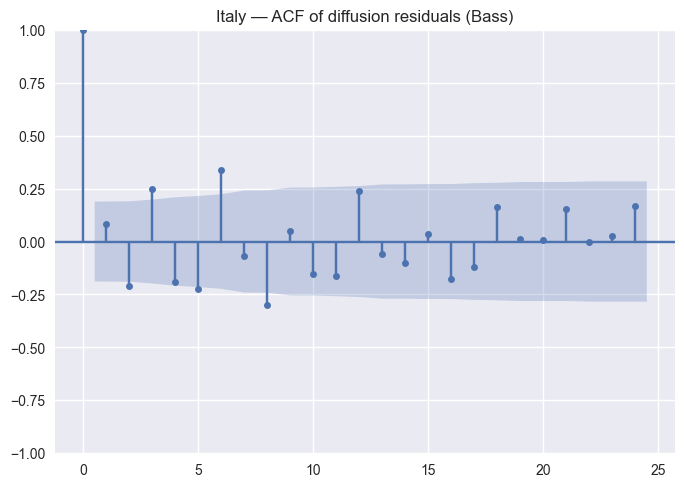

In [199]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(resid_train_raw_bass, lags=24)
plt.title("Italy — ACF of diffusion residuals (Bass)")
plt.show()


In [200]:
train_raw, test_raw = make_train_test(ts_norway, TRAIN_END, H)
y_true_raw = test_raw.copy()
# ... then rerun the same steps


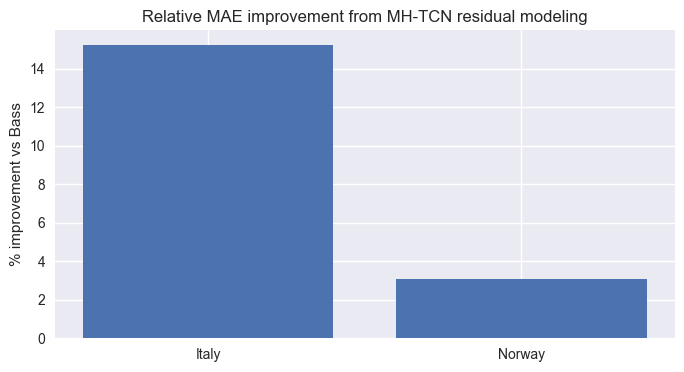

In [187]:
plt.figure(figsize=(8,4))
plt.bar(["Italy", "Norway"],
        [rel_it_raw.query("Residual == 'MH-TCN'")["Improvement"].max(),
         rel_no_raw.query("Residual == 'MH-TCN'")["Improvement"].max()])
plt.title("Relative MAE improvement from MH-TCN residual modeling")
plt.ylabel("% improvement vs Bass")
plt.show()


# PLOTTING

In [201]:
def prepare_scales(ts: pd.Series):
    ts = ts.asfreq("MS")
    return {
        "raw": ts.astype(float),
        "log": np.log1p(ts.astype(float))
    }

def add_month_col(series: pd.Series):
    df = series.rename("value").to_frame()
    df["month"] = df.index.month
    return df


In [202]:
def plot_series_raw_and_log(ts_raw: pd.Series, title_prefix=""):
    ts_raw = ts_raw.asfreq("MS")
    ts_log = np.log1p(ts_raw)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].plot(ts_raw.index, ts_raw.values)
    ax[0].set_title(f"{title_prefix} BEV registrations (monthly)")
    ax[0].set_xlabel("Date")
    ax[0].set_ylabel("Registrations")

    ax[1].plot(ts_log.index, ts_log.values)
    ax[1].set_title("log(1 + BEV registrations)")
    ax[1].set_xlabel("Date")
    ax[1].set_ylabel("log(1 + registrations)")

    plt.tight_layout()
    plt.show()


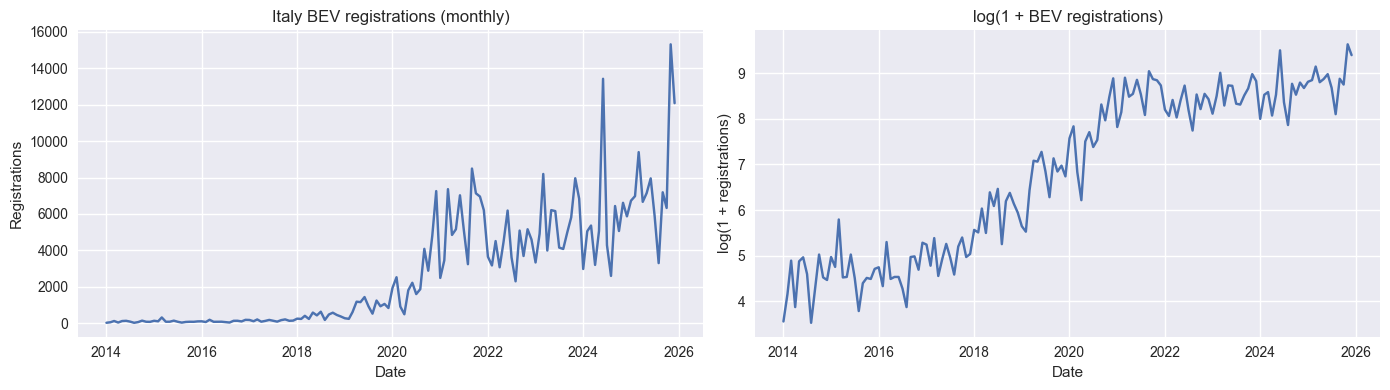

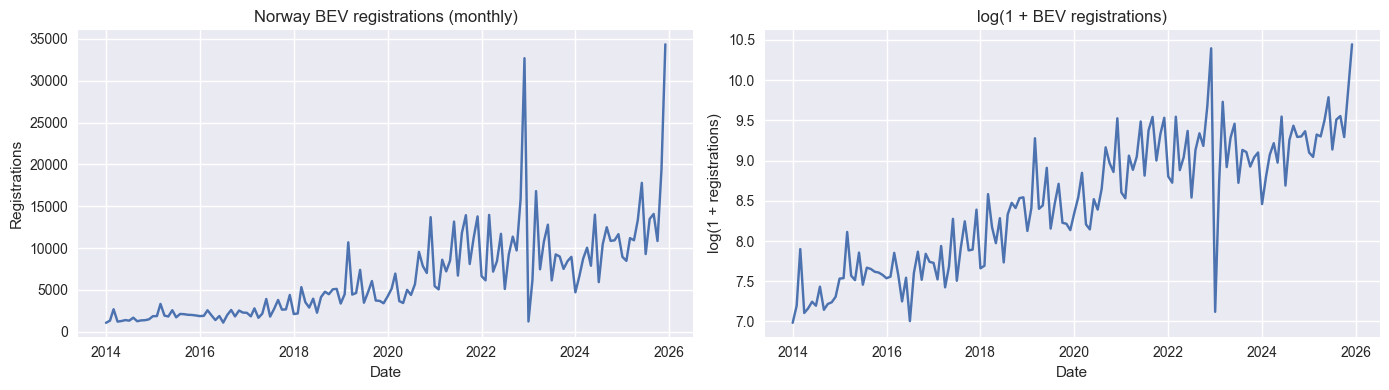

In [203]:
ts_italy = load_country_series("Italy")
ts_norway = load_country_series("Norway")

plot_series_raw_and_log(ts_italy, title_prefix="Italy")
plot_series_raw_and_log(ts_norway, title_prefix="Norway")


In [204]:
def plot_seasonality_and_stl(ts: pd.Series, title_prefix="", stl_on="log", stl_period=12):
    ts = ts.asfreq("MS").astype(float)
    s = np.log1p(ts) if stl_on == "log" else ts

    # Month boxplot uses RAW (more interpretable)
    dfm = add_month_col(ts)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # --- month boxplot (manual, no seaborn dependency) ---
    data_by_month = [dfm[dfm["month"] == m]["value"].values for m in range(1, 13)]
    ax[0].boxplot(data_by_month, labels=list(range(1, 13)))
    ax[0].set_title("BEV registrations by month (seasonality check)")
    ax[0].set_xlabel("Month")
    ax[0].set_ylabel("Registrations")

    # --- STL ---
    stl = STL(s, period=stl_period, robust=True).fit()
    # plot on the right as 4 stacked small plots inside same axes area (simple)
    ax[1].plot(s.index, s.values, label="series")
    ax[1].plot(stl.trend.index, stl.trend.values, label="trend")
    ax[1].plot(stl.seasonal.index, stl.seasonal.values, label="seasonal")
    ax[1].plot(stl.resid.index, stl.resid.values, label="resid")
    ax[1].set_title(f"STL (on {stl_on}) — overlay view")
    ax[1].legend(loc="best", fontsize=8)

    plt.suptitle(f"{title_prefix} — STL Decomposition & Seasonality Check", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # If you want the traditional 4-panel STL plot:
    fig = stl.plot()
    fig.set_size_inches(10, 6)
    plt.suptitle(f"{title_prefix} — STL Decomposition (on {stl_on})", y=1.02)
    plt.tight_layout()
    plt.show()

    return stl


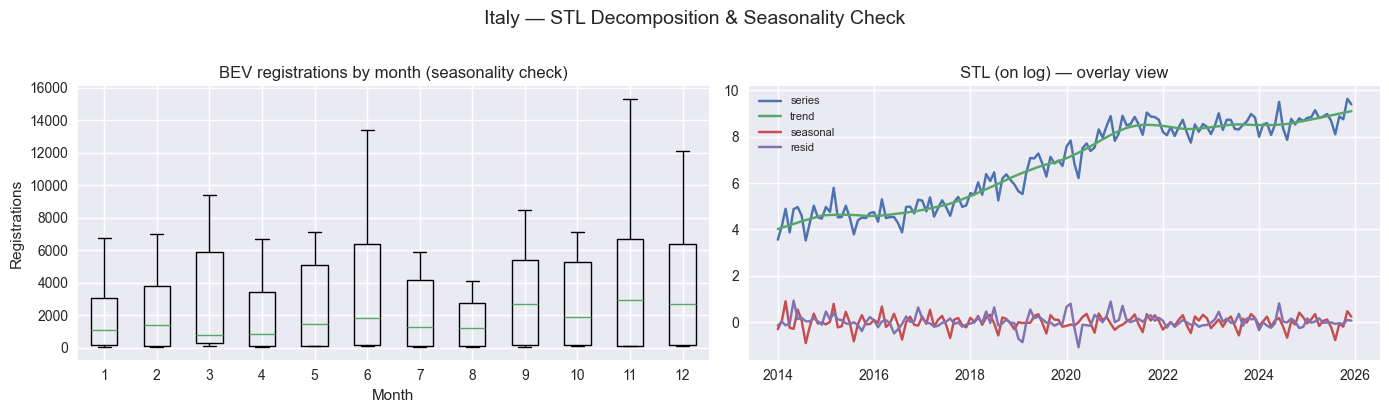

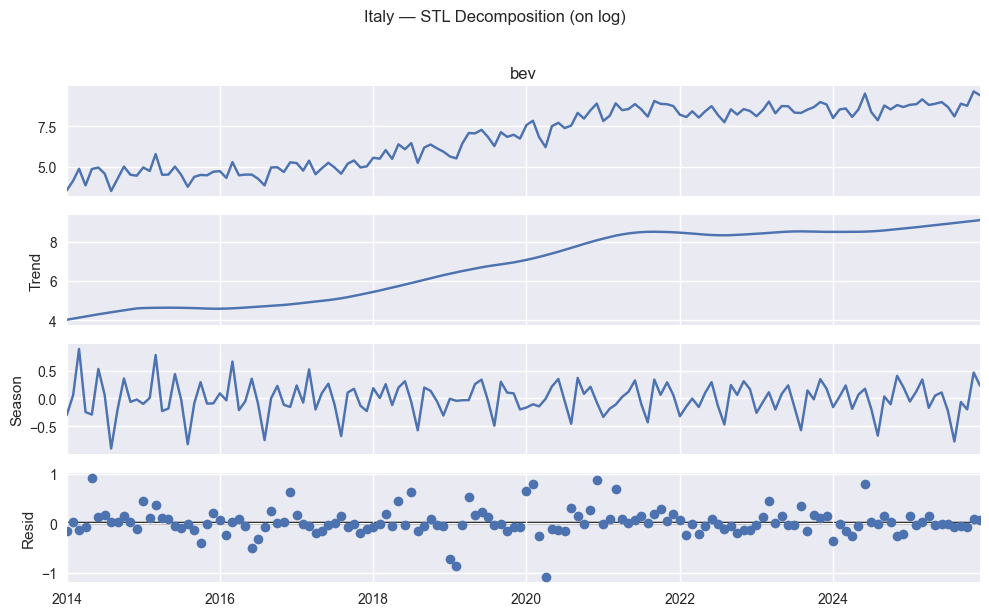

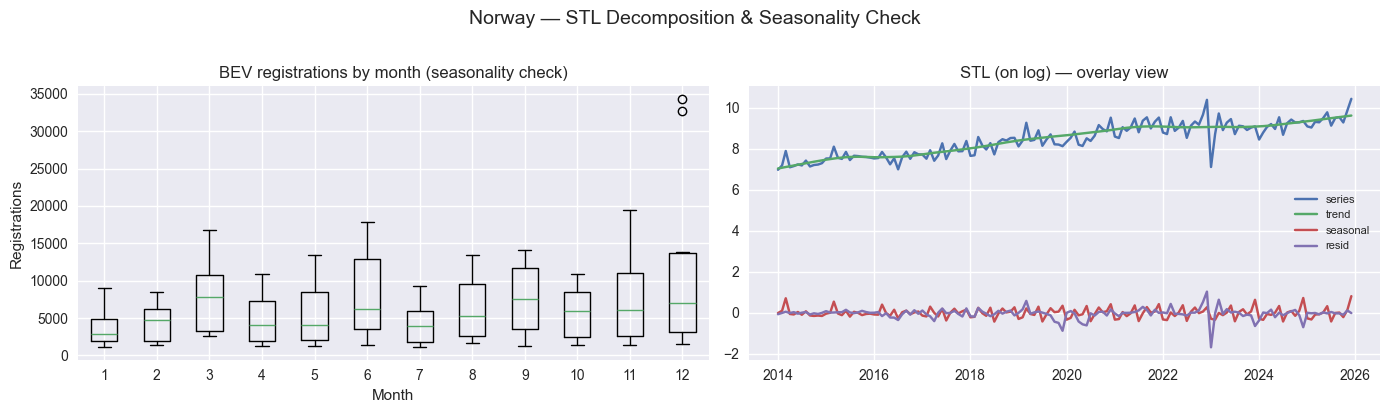

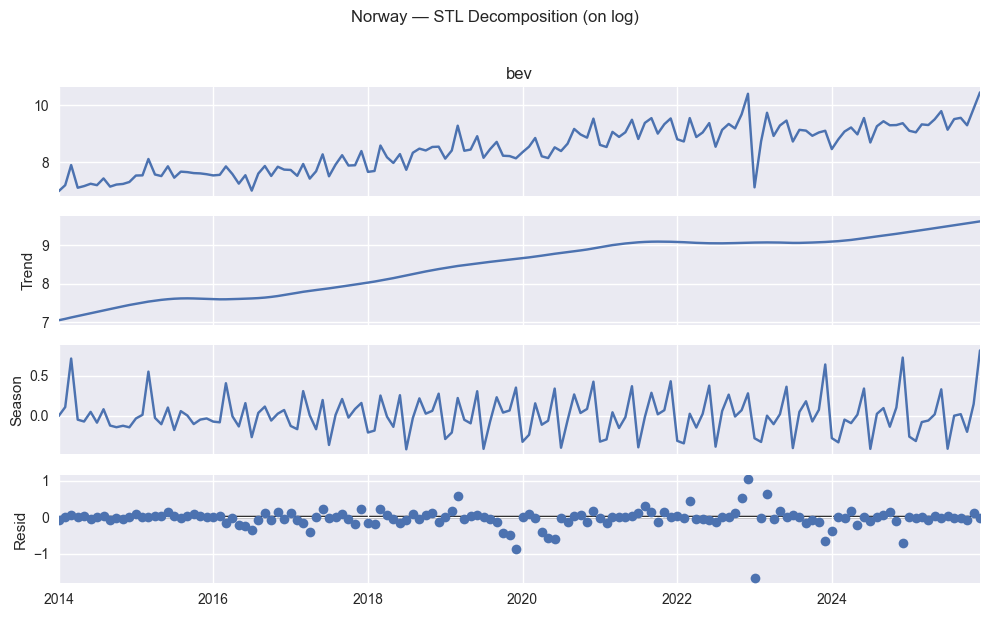

In [205]:
stl_it = plot_seasonality_and_stl(ts_italy, title_prefix="Italy", stl_on="log")
stl_no = plot_seasonality_and_stl(ts_norway, title_prefix="Norway", stl_on="log")


In [206]:
def plot_acf_pacf(ts: pd.Series, title_prefix="", on="log", lags=48):
    ts = ts.asfreq("MS").astype(float)
    s = np.log1p(ts) if on == "log" else ts
    s = s.dropna()

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(s, lags=lags, ax=ax[0])
    ax[0].set_title(f"ACF: {'log1p(BEV)' if on=='log' else 'BEV'}")

    plot_pacf(s, lags=lags, ax=ax[1], method="ywm")
    ax[1].set_title(f"PACF: {'log1p(BEV)' if on=='log' else 'BEV'}")

    plt.suptitle(f"{title_prefix} — Autocorrelation diagnostics (ACF/PACF)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


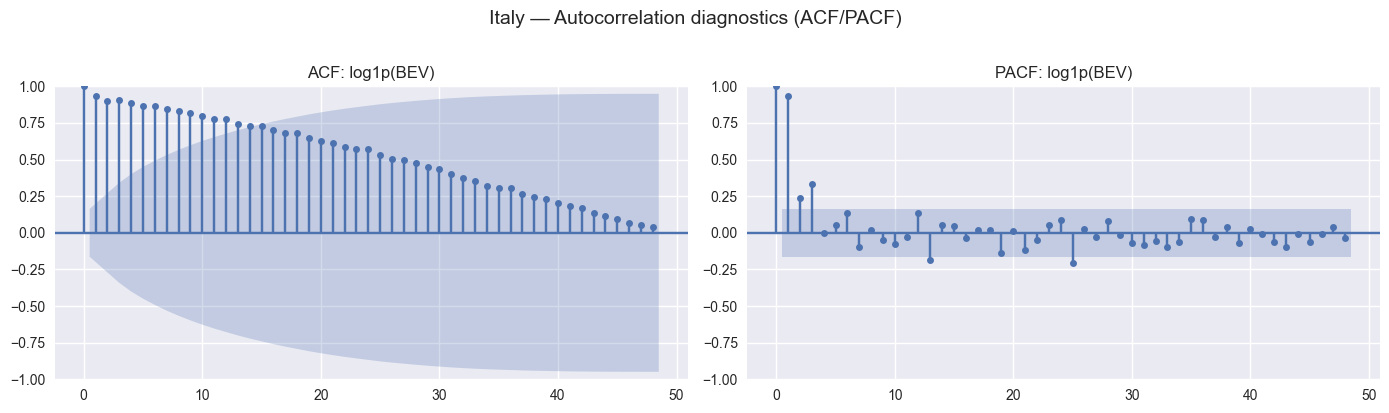

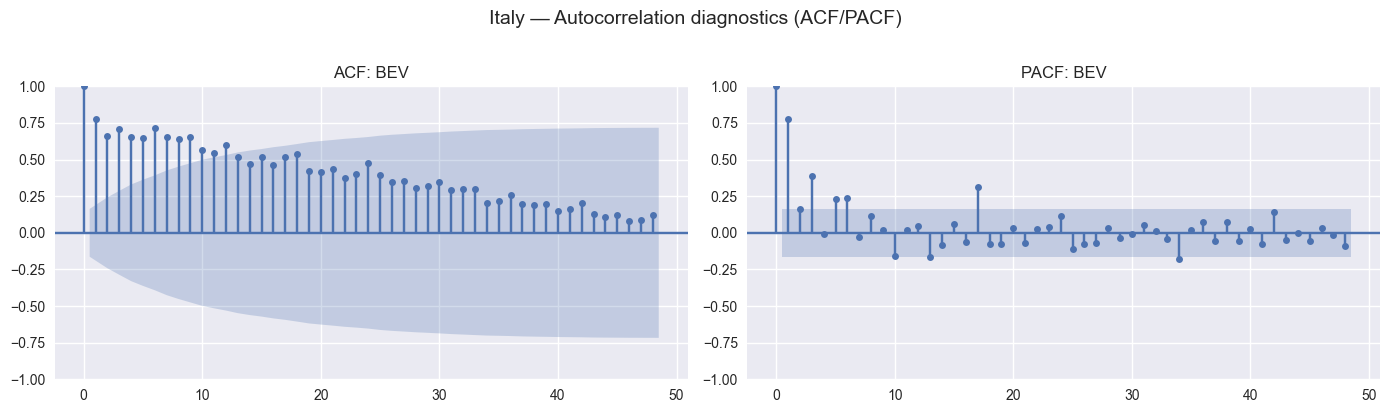

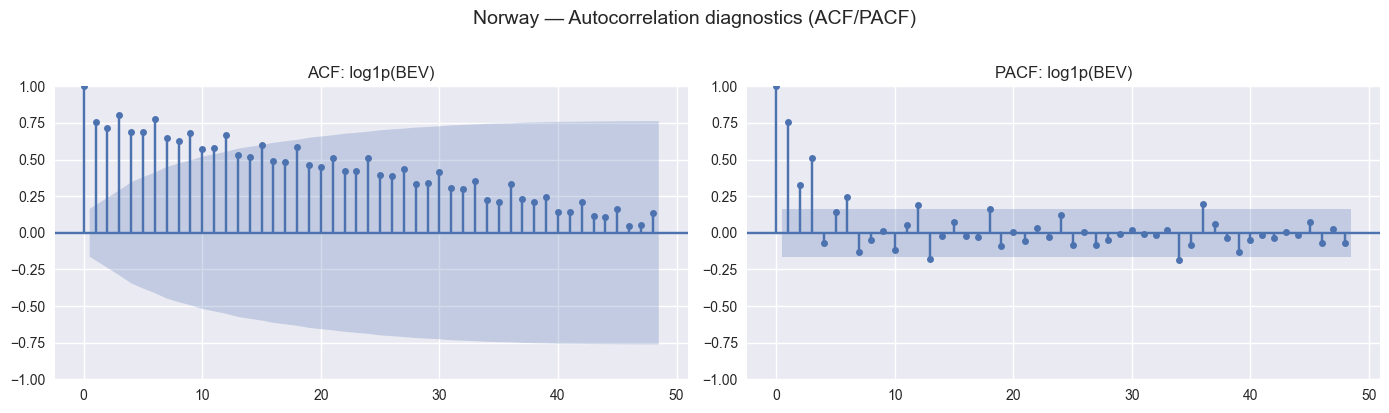

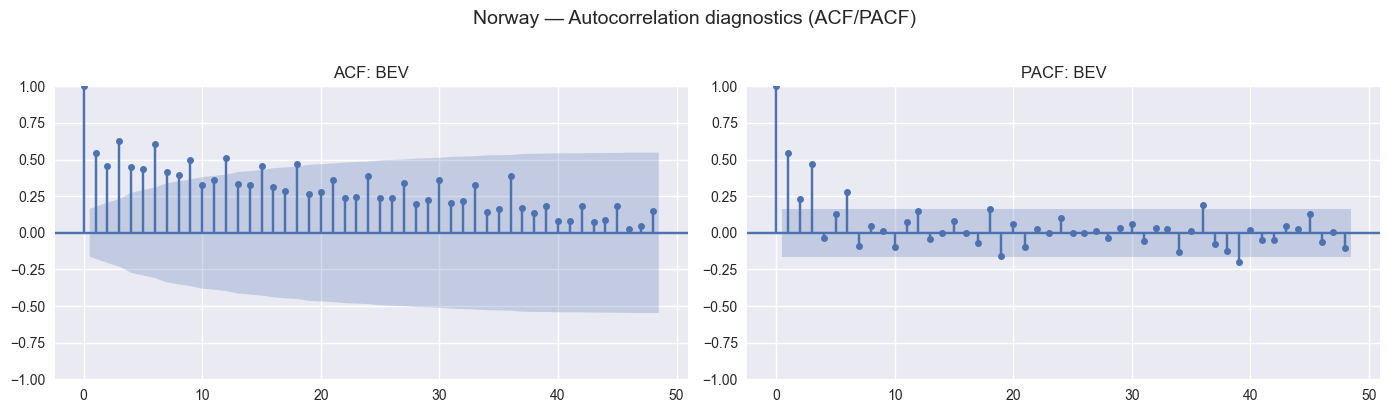

In [207]:
plot_acf_pacf(ts_italy, title_prefix="Italy", on="log")
plot_acf_pacf(ts_italy, title_prefix="Italy", on="raw")

plot_acf_pacf(ts_norway, title_prefix="Norway", on="log")
plot_acf_pacf(ts_norway, title_prefix="Norway", on="raw")


In [208]:
def plot_residual_refinement(resid_diff, resid_sar, resid_nn, title_prefix="", lags=24):
    # Align index intersection
    idx = resid_diff.dropna().index
    resid_sar = resid_sar.reindex(idx)
    resid_nn  = resid_nn.reindex(idx)

    fig, ax = plt.subplots(3, 2, figsize=(14, 8))

    # Time plots
    ax[0,0].plot(resid_diff.index, resid_diff.values)
    ax[0,0].set_title("Residuals after diffusion only")

    ax[1,0].plot(resid_sar.index, resid_sar.values)
    ax[1,0].set_title("Residuals after + SARIMAX")

    ax[2,0].plot(resid_nn.index, resid_nn.values)
    ax[2,0].set_title("Residuals after + MH-TCN")

    # ACFs
    plot_acf(resid_diff.dropna(), lags=lags, ax=ax[0,1])
    ax[0,1].set_title("ACF (diffusion residuals)")

    plot_acf(resid_sar.dropna(), lags=lags, ax=ax[1,1])
    ax[1,1].set_title("ACF (after SARIMAX)")

    plot_acf(resid_nn.dropna(), lags=lags, ax=ax[2,1])
    ax[2,1].set_title("ACF (after MH-TCN)")

    plt.suptitle(f"{title_prefix} — Residual refinement (time + ACF)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Small numeric summary (useful in thesis)
    print(f"{title_prefix} residual std:")
    print(" diffusion only:", float(resid_diff.std()))
    print(" + SARIMAX     :", float(resid_sar.std()))
    print(" + MH-TCN      :", float(resid_nn.std()))


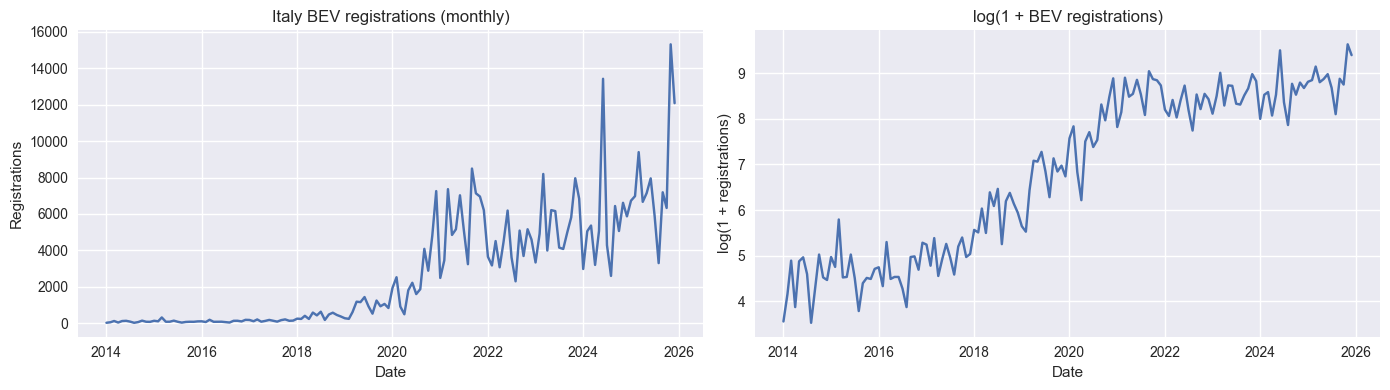

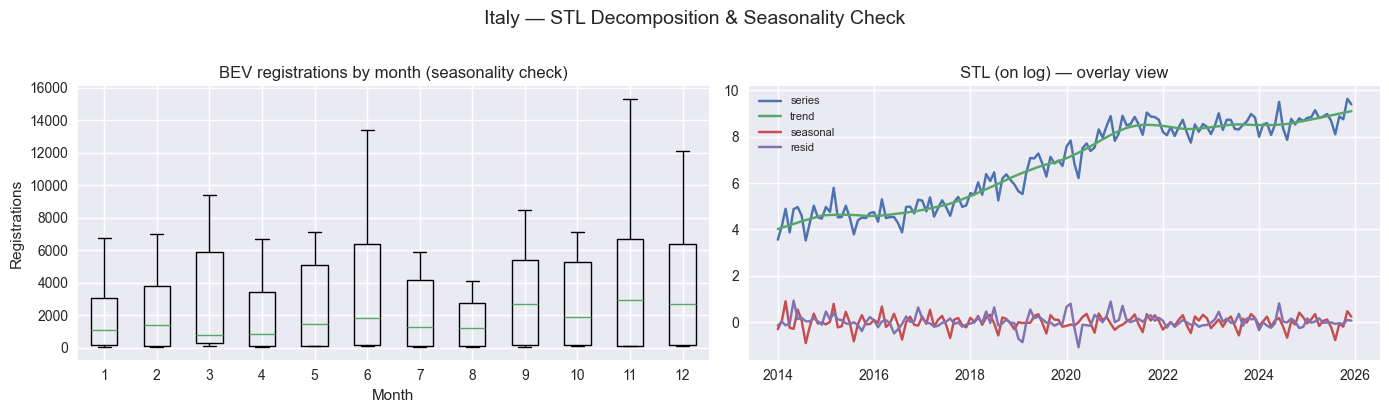

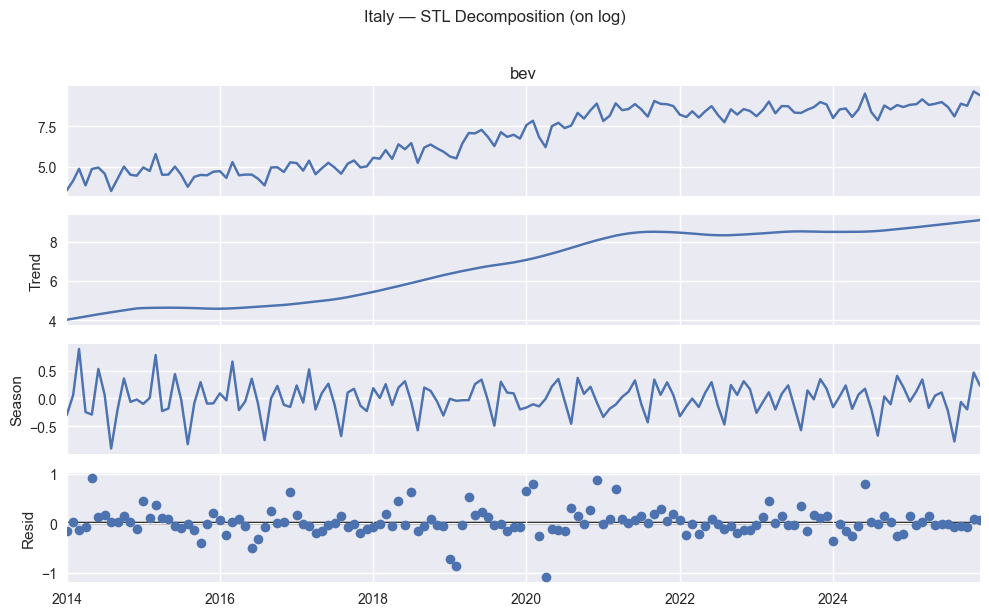

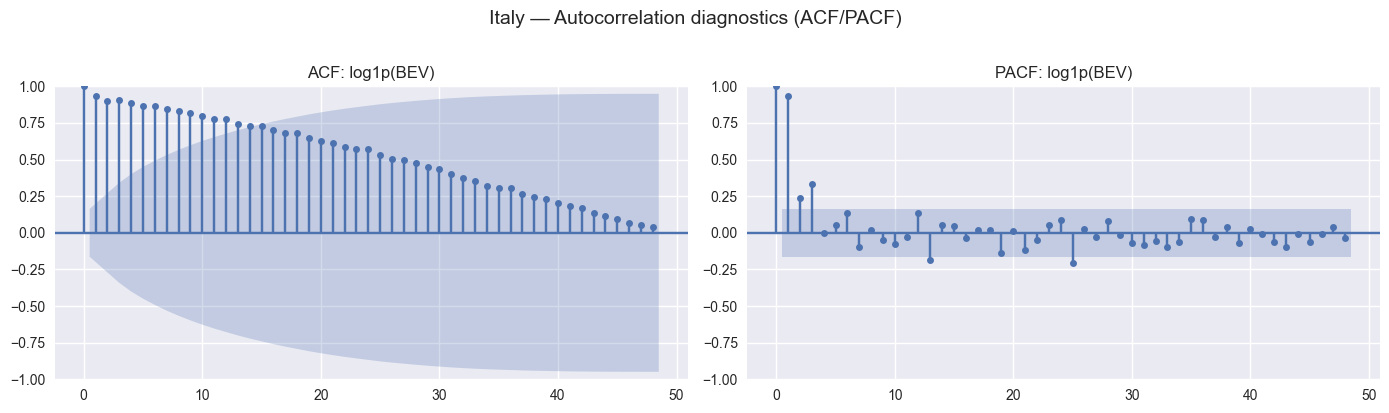

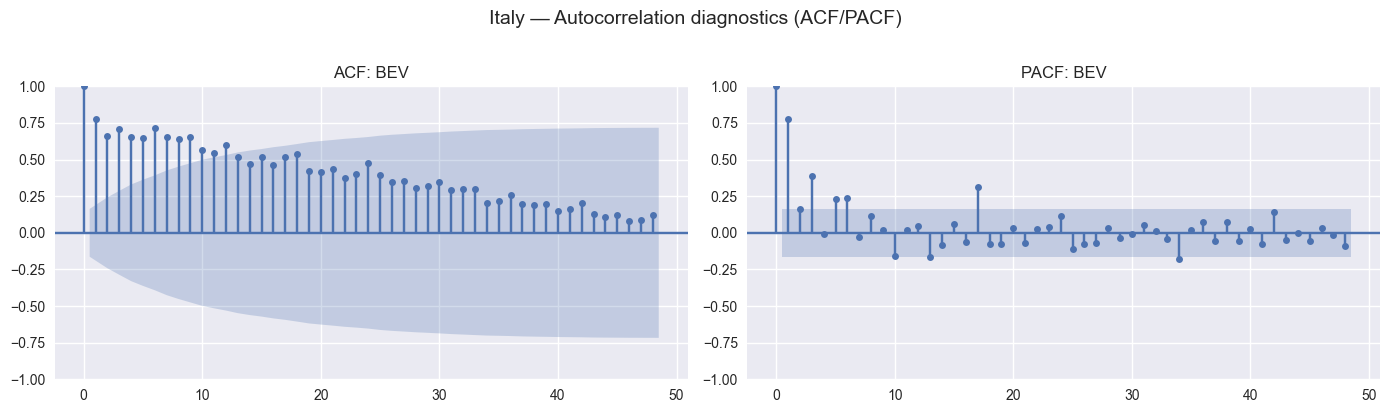

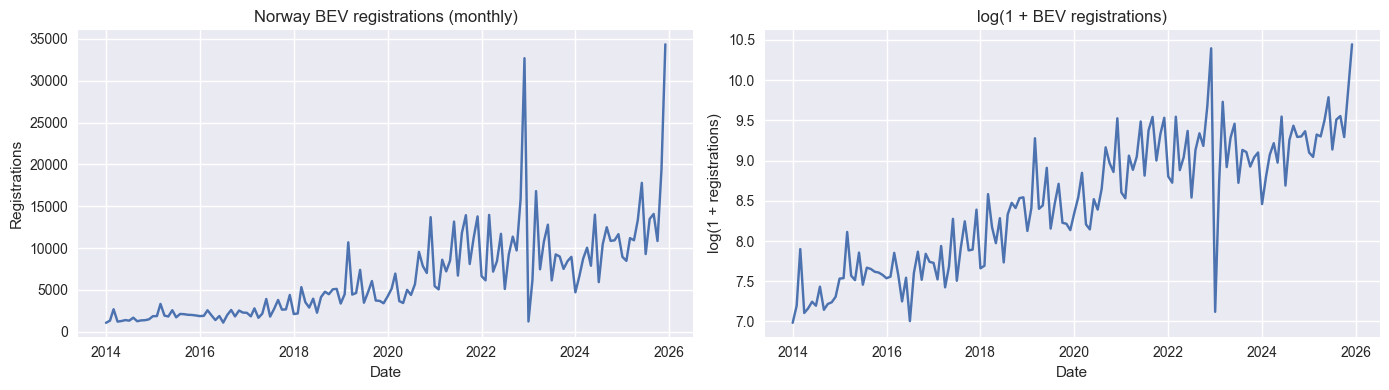

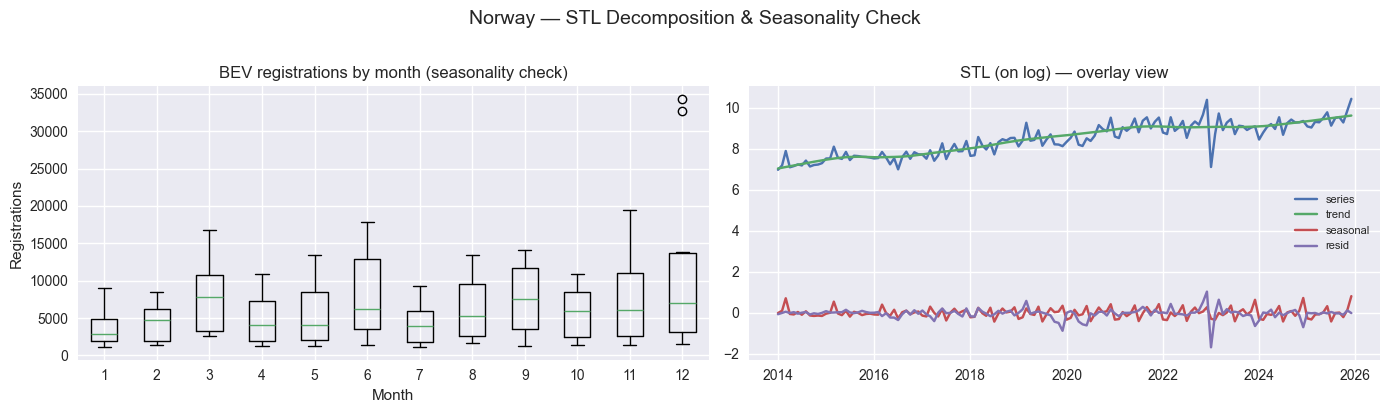

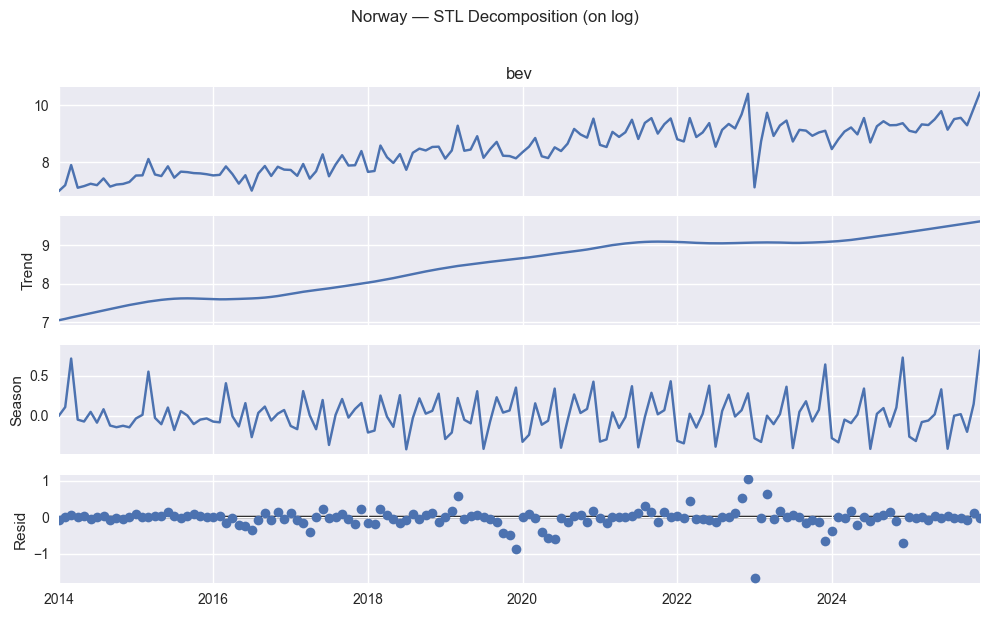

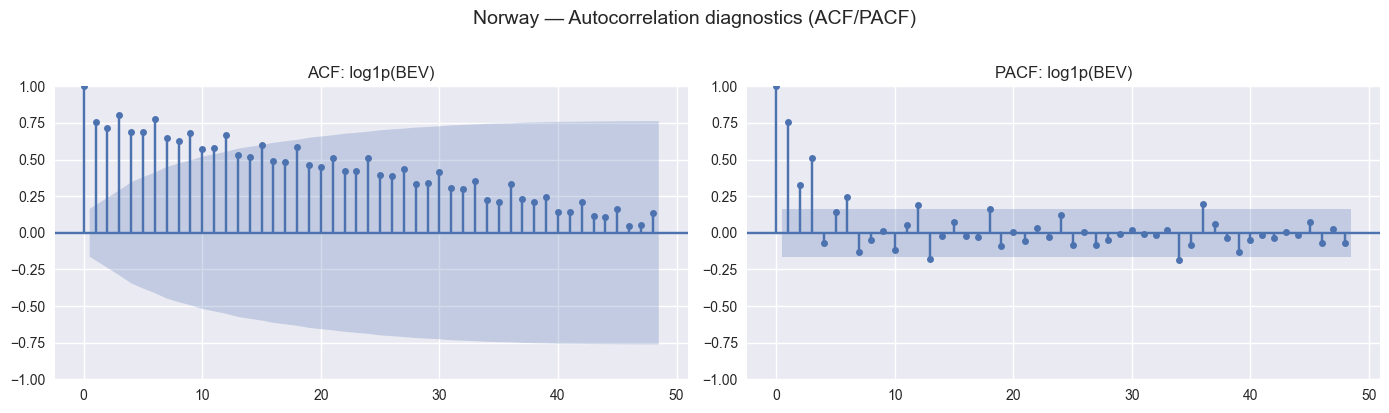

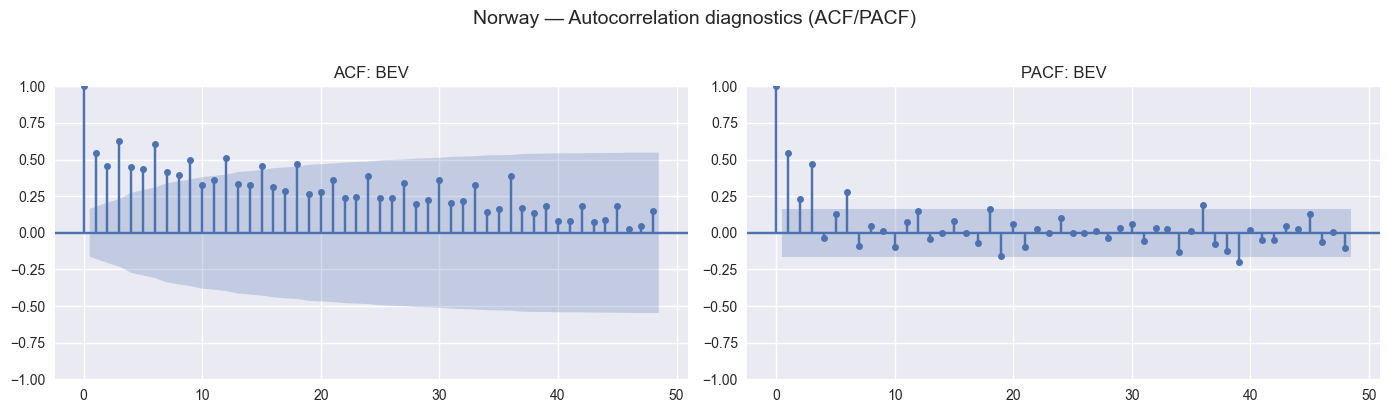

In [209]:
def make_all_plots_for_country(ts_country, country_name):
    plot_series_raw_and_log(ts_country, title_prefix=country_name)
    plot_seasonality_and_stl(ts_country, title_prefix=country_name, stl_on="log")
    plot_acf_pacf(ts_country, title_prefix=country_name, on="log")
    plot_acf_pacf(ts_country, title_prefix=country_name, on="raw")

make_all_plots_for_country(ts_italy, "Italy")
make_all_plots_for_country(ts_norway, "Norway")


In [218]:
def plot_forecast_comparison(
    y_true,
    y_bass_fore,
    y_bass_mh_fore,
    y_dyn_mh_fore,
    title="Forecast comparison (raw scale)"
):
    plt.figure(figsize=(10, 4))

    plt.plot(y_true.index, y_true.values, label="Observed", color="black", linewidth=2)
    plt.plot(y_bass_fore.index, y_bass_fore.values, label="Bass", linestyle="--")
    plt.plot(y_bass_mh_fore.index, y_bass_mh_fore.values, label="Bass + MH-TCN")
    plt.plot(y_dyn_mh_fore.index, y_dyn_mh_fore.values, label="DynamicBass + MH-TCN")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("BEV registrations")
    plt.legend()
    plt.tight_layout()
    plt.show()


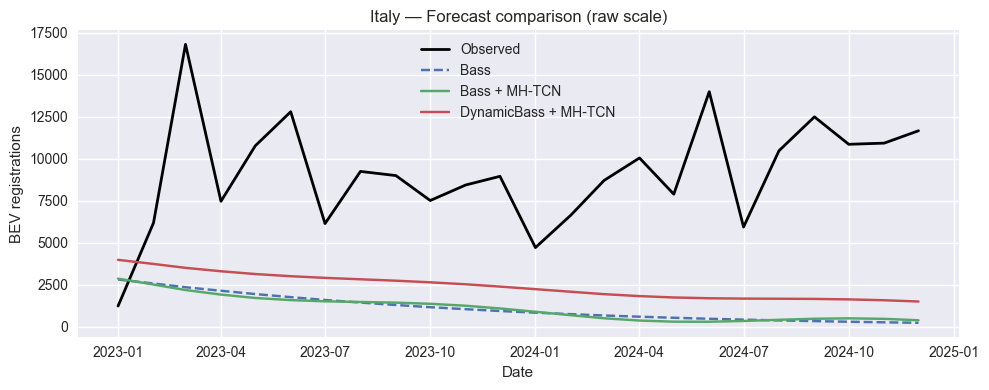

In [219]:
plot_forecast_comparison(
    y_true_raw,
    y_bass_fore,
    y_bass_mh_fore,
    y_dyn_mh_fore,
    title="Italy — Forecast comparison (raw scale)"
)



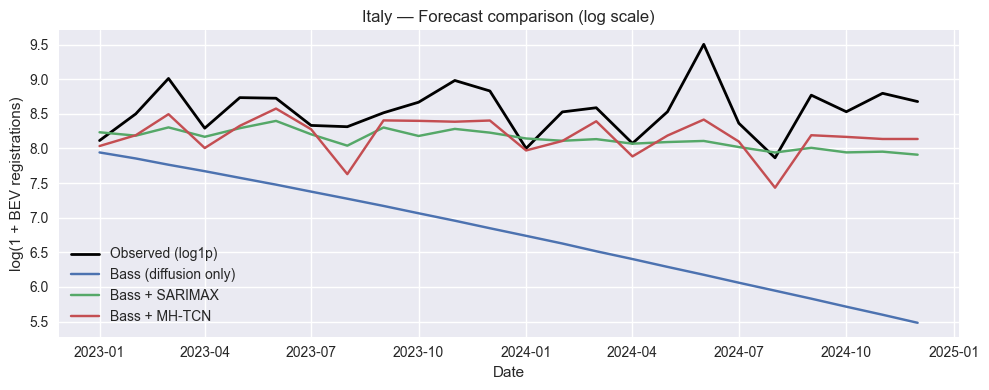

In [221]:
def ensure_log1p_series(s: pd.Series, name="series"):
    """
    Returns s in log1p units.
    If s looks like raw units (max > 50), convert using log1p.
    If s already looks like log1p (max < 20), keep as is.
    """
    s = pd.Series(s).astype(float)
    if np.isinf(s).any():
        raise ValueError(f"{name} contains inf values. Fix model output before plotting.")
    if s.max() > 50:
        return np.log1p(s)
    return s

def plot_forecast_comparison_log(
    ts_raw: pd.Series,
    train_end: str,
    H: int,
    forecasts: dict,
    title: str
):
    """
    ts_raw: full raw series (vehicles)
    forecasts: dict of {label: forecast_series} for the TEST window.
              Each forecast can be in raw or log scale; we will convert to log safely.
    """
    ts_raw = ts_raw.asfreq("MS").astype(float)

    # define test window
    start_test = pd.to_datetime(train_end) + pd.offsets.MonthBegin(1)
    test_raw = ts_raw.loc[start_test:].iloc[:H]
    y_true_log = ensure_log1p_series(test_raw, name="y_true_log")

    plt.figure(figsize=(10,4))
    plt.plot(y_true_log.index, y_true_log.values, label="Observed (log1p)", color="black", linewidth=2)

    for label, yhat in forecasts.items():
        yhat = pd.Series(yhat).reindex(y_true_log.index)
        yhat_log = ensure_log1p_series(yhat, name=label)
        plt.plot(yhat_log.index, yhat_log.values, label=label)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("log(1 + BEV registrations)")
    plt.legend()
    plt.tight_layout()
    plt.show()

TRAIN_END = "2022-12-01"
H = 24

ts_italy = load_country_series("Italy")

# Build index for the test window
start_test = pd.to_datetime(TRAIN_END) + pd.offsets.MonthBegin(1)
test_idx = pd.date_range(start=start_test, periods=H, freq="MS")

# Ensure your forecasts are pd.Series on test_idx
# Replace these with your actual forecast variables
forecasts_italy = {
    "Bass (diffusion only)": pd.Series(y_bass_fore, index=test_idx),
    "Bass + SARIMAX":        pd.Series(y_sar,      index=test_idx),
    "Bass + MH-TCN":         pd.Series(y_tcn_mh,   index=test_idx),
    # Optional:
    # "DynamicBass + MH-TCN":  pd.Series(y_dyn_mh,  index=test_idx),
}

plot_forecast_comparison_log(
    ts_raw=ts_italy,
    train_end=TRAIN_END,
    H=H,
    forecasts=forecasts_italy,
    title="Italy — Forecast comparison (log scale)"
)


In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _to_log1p_if_raw(s: pd.Series) -> pd.Series:
    """If s looks like raw (hundreds/thousands), convert to log1p; else assume already log."""
    s = pd.Series(s).astype(float)
    if np.isinf(s.values).any():
        raise ValueError("Series contains inf values.")
    return np.log1p(s) if s.max() > 50 else s

def _to_raw_if_log(s: pd.Series) -> pd.Series:
    """If s looks like log (<= ~20), convert to raw via expm1; else assume already raw."""
    s = pd.Series(s).astype(float)
    if np.isinf(s.values).any():
        raise ValueError("Series contains inf values.")
    return np.expm1(s) if s.max() < 20 else s

def plot_full_comparison(ts_raw: pd.Series, train_end: str, H: int,
                         series_dict: dict, title: str, scale: str = "raw",
                         smooth_obs: int | None = 3):
    """
    ts_raw: full raw series (vehicles), monthly MS index
    series_dict: label -> forecast series for the test window (raw or log; we handle conversion)
    scale: 'raw' or 'log'
    smooth_obs: rolling window for observed (None to disable)
    """
    ts_raw = ts_raw.asfreq("MS").astype(float)

    start_test = pd.to_datetime(train_end) + pd.offsets.MonthBegin(1)
    test_raw = ts_raw.loc[start_test:].iloc[:H]
    idx = test_raw.index

    # observed series for plot
    if scale == "log":
        y_obs = np.log1p(test_raw)
        ylabel = "log(1 + BEV registrations)"
    else:
        y_obs = test_raw
        ylabel = "BEV registrations"

    plt.figure(figsize=(11,4))

    # observed (optionally smoothed + raw)
    if smooth_obs is not None and smooth_obs > 1 and scale == "raw":
        plt.plot(test_raw.index, test_raw.values, label="Observed", color="black", alpha=0.35, linewidth=1)
        obs_smooth = test_raw.rolling(smooth_obs, center=True).mean()
        plt.plot(obs_smooth.index, obs_smooth.values, label=f"Observed ({smooth_obs}-mo avg)", color="black", linewidth=2)
    else:
        plt.plot(y_obs.index, y_obs.values, label="Observed", color="black", linewidth=2)

    # forecasts
    for label, s in series_dict.items():
        s = pd.Series(s, index=idx).astype(float)

        if scale == "log":
            s_plot = _to_log1p_if_raw(s)
        else:
            s_plot = _to_raw_if_log(s)

        # sanity: skip invalid
        if np.isinf(s_plot.values).any() or np.isnan(s_plot.values).all():
            print(f"Skipping {label}: invalid values.")
            continue

        plt.plot(idx, s_plot.values, label=label)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


In [239]:
series_italy = {
    "Bass": y_bass_fore,
    "Bass + SARIMAX": y_bass_sarimax_fore,
    "Bass + MH-TCN": y_bass_mh_fore,
    "DynamicBass": y_dyn_fore,
    "DynamicBass + SARIMAX": y_dyn_sarimax_fore,
    "DynamicBass + MH-TCN": y_dyn_mh_fore,
}


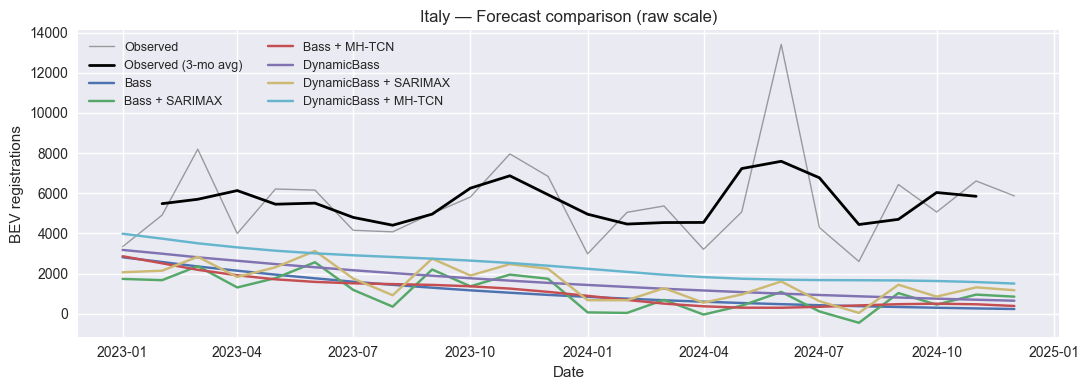

In [226]:
plot_full_comparison(
    ts_raw=ts_italy,
    train_end=TRAIN_END,
    H=H,
    series_dict=series_italy,
    title="Italy — Forecast comparison (raw scale)",
    scale="raw",
    smooth_obs=3  # makes the trend comparison fair
)


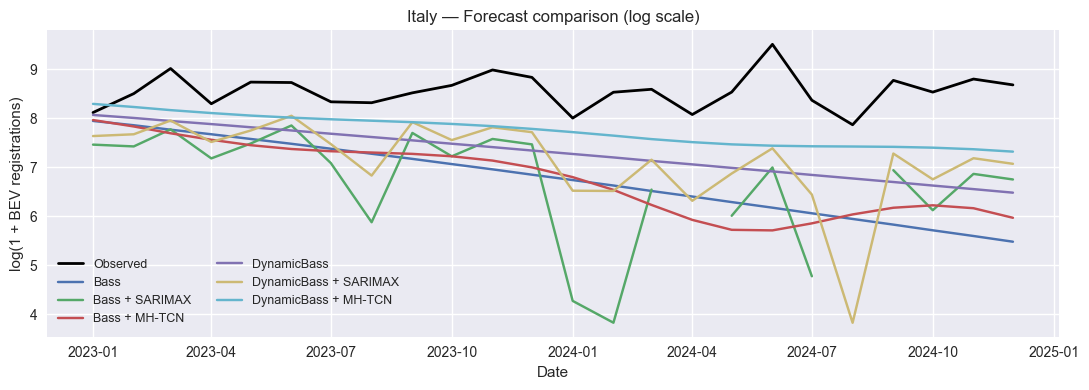

In [227]:
plot_full_comparison(
    ts_raw=ts_italy,
    train_end=TRAIN_END,
    H=H,
    series_dict=series_italy,
    title="Italy — Forecast comparison (log scale)",
    scale="log",
    smooth_obs=None
)


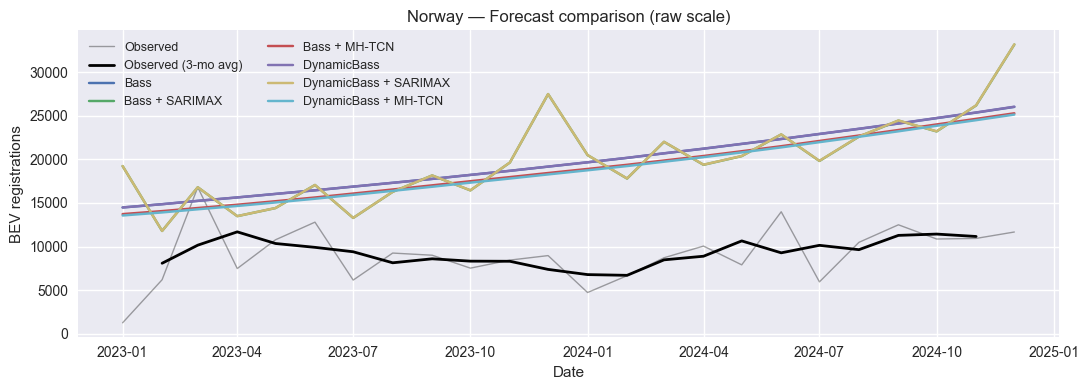

In [264]:
plot_full_comparison(
    ts_raw=ts_norway,
    train_end=TRAIN_END,
    H=H,
    series_dict=series_italy,
    title="Norway — Forecast comparison (raw scale)",
    scale="raw",
    smooth_obs=3  # makes the trend comparison fair
)


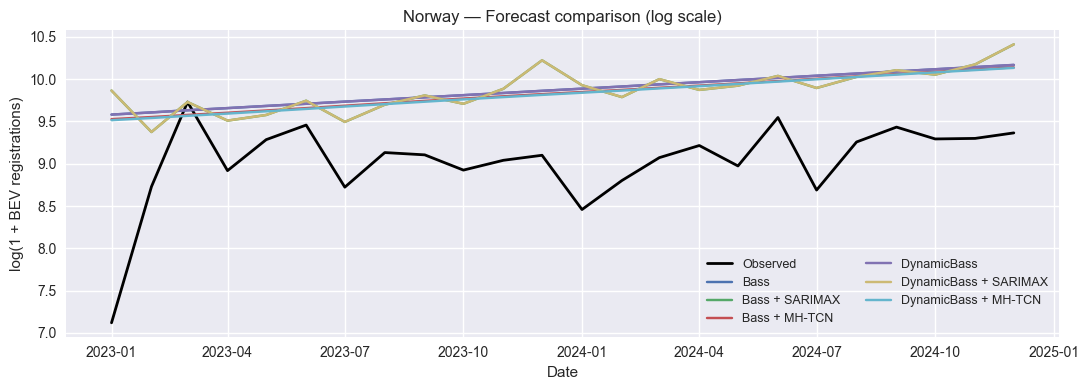

In [265]:
plot_full_comparison(
    ts_raw=ts_norway,
    train_end=TRAIN_END,
    H=H,
    series_dict=series_italy,
    title="Norway — Forecast comparison (log scale)",
    scale="log",
    smooth_obs=3  # makes the trend comparison fair
)

In [243]:
def sanity_check_forecasts(ts_raw, train_end, H, series_dict, name=""):
    ts_raw = ts_raw.asfreq("MS").astype(float)
    start_test = pd.to_datetime(train_end) + pd.offsets.MonthBegin(1)
    test = ts_raw.loc[start_test:].iloc[:H]

    print(f"\n--- {name} forecast check ---")
    print("Last train value:", float(ts_raw.loc[:train_end].iloc[-1]))
    print("Test mean:", float(test.mean()))

    for label, s in series_dict.items():
        s = pd.Series(s, index=test.index).astype(float)
        # If it looks raw, keep raw; if it looks log, convert to raw for interpretability
        s_raw = np.expm1(s) if s.max() < 20 else s
        print(label, "| mean:", float(np.mean(s_raw)), "min/max:", float(np.min(s_raw)), float(np.max(s_raw)))

series_norway = {
    "Bass": y_bass_fore,
    "Bass + SARIMAX": y_bass_sarimax_fore,
    "Bass + MH-TCN": y_bass_mh_fore,
    "DynamicBass": y_dyn_fore,
    "DynamicBass + SARIMAX": y_dyn_sarimax_fore,
    "DynamicBass + MH-TCN": y_dyn_mh_fore,
}
sanity_check_forecasts(ts_norway, TRAIN_END, H, series_norway, name="Norway")


--- Norway forecast check ---
Last train value: 32692.0
Test mean: 9123.25
Bass | mean: 19727.09306829498 min/max: 14486.00146845041 26040.515387175972
Bass + SARIMAX | mean: 19861.598291704373 min/max: 11789.618796171582 33207.31053945632
Bass + MH-TCN | mean: 18950.68361903554 min/max: 13727.372012884003 25308.665045379097
DynamicBass | mean: 19737.04142095431 min/max: 14488.343019959888 26063.023357494487
DynamicBass + SARIMAX | mean: 19871.436303044513 min/max: 11792.566640010527 33228.93245207172
DynamicBass + MH-TCN | mean: 18798.231428481977 min/max: 13563.5882592177 25159.17124567808
